## PHẦN I. MỞ ĐẦU
1. Giới thiệu bài toán
Phân tích cảm xúc văn bản là một bài toán quan trọng trong lĩnh vực xử lý ngôn ngữ tự nhiên, với mục tiêu xác định thái độ hoặc mức độ cảm xúc được thể hiện trong câu hoặc đoạn văn. Trong bài tiểu luận này, bài toán được xét dưới dạng phân loại cảm xúc đa lớp trên bộ dữ liệu SST-5, trong đó mỗi câu văn bản được gán vào một trong năm mức độ cảm xúc: very negative, negative, neutral, positive, very positive.
2. Bài làm hướng đến các mục tiêu sau:
- Khảo sát và tiền xử lý bộ dữ liệu SST-5.
- Thực nghiệm với hai mô hình hồi tiếp là LSTM và GRU.
- Fine-tune một số mô hình pretrained Transformer/BERT trên cùng tập dữ liệu.
- Cài đặt và thử nghiệm một Transformer custom để chủ động thay đổi kiến trúc.
- Đánh giá mô hình bằng accuracy, precision, recall, F1-score và macro-F1.
- Phân tích ảnh hưởng của các hyperparameter và các phương pháp biểu diễn đầu ra.
3. Bộ dữ liệu: https://huggingface.co/datasets/SetFit/sst5

## PHẦN II. DỮ LIỆU VÀ TIỀN XỬ LÝ DỮ LIỆU

### 1. Import thư viện

In [2]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

D:\Code\Python\Sentiment_Analyst\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. Set seed và device

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


### 3. Load dataset và chuyển sang data frame để xử lý

In [4]:
#Load dataset
dataset = load_dataset("SetFit/sst5")
dataset

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 8544
    })
    validation: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 1101
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 2210
    })
})

In [5]:
#Chuyển sang data frame
train_df = pd.DataFrame(dataset["train"])
val_df = pd.DataFrame(dataset["validation"])
test_df = pd.DataFrame(dataset["test"])

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (8544, 3)
Validation shape: (1101, 3)
Test shape: (2210, 3)


,text,label,label_text
0,"a stirring , funny and finally transporting re...",4,very positive
1,apparently reassembled from the cutting-room f...,1,negative
2,they presume their audience wo n't sit still f...,1,negative
3,the entire movie is filled with deja vu moments .,2,neutral
4,this is a visually stunning rumination on love...,3,positive


### 4. Khảo sát và thống kê số liệu

In [6]:
#Gán nhãn
label_map = {
    0: "very negative",
    1: "negative",
    2: "neutral",
    3: "positive",
    4: "very positive"
}

for df in [train_df, val_df, test_df]:
    df["label_name"] = df["label"].map(label_map)

In [7]:
#Thống kê phân bố nhãn
def show_class_distribution(df, name="Dataset"):
    counts = df["label_name"].value_counts().sort_index()
    print(f"\n{name} distribution:")
    print(counts)
    return counts

train_counts = show_class_distribution(train_df, "Train")
val_counts = show_class_distribution(val_df, "Validation")
test_counts = show_class_distribution(test_df, "Test")


Train distribution:
label_name
negative         2218
neutral          1624
positive         2322
very negative    1092
very positive    1288
Name: count, dtype: int64

Validation distribution:
label_name
negative         289
neutral          229
positive         279
very negative    139
very positive    165
Name: count, dtype: int64

Test distribution:
label_name
negative         633
neutral          389
positive         510
very negative    279
very positive    399
Name: count, dtype: int64


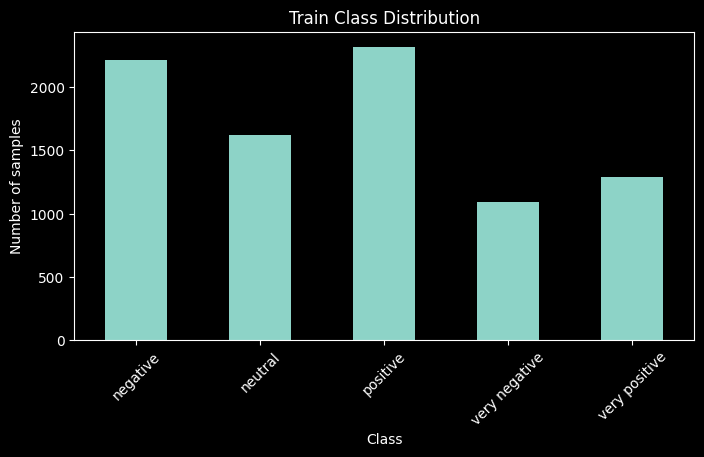

In [8]:
#Vẽ biểu đồ phân bố lớp
train_counts.plot(kind="bar", figsize=(8, 4))
plt.title("Train Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.xticks(rotation=45)
plt.show()

In [9]:
#In ví dụ dữ liệu
for i in range(5):
    print(f"Text: {train_df.iloc[i]['text']}")
    print(f"Label: {train_df.iloc[i]['label']} - {train_df.iloc[i]['label_name']}")
    print("-" * 100)

Text: a stirring , funny and finally transporting re-imagining of beauty and the beast and 1930s horror films
Label: 4 - very positive
----------------------------------------------------------------------------------------------------
Text: apparently reassembled from the cutting-room floor of any given daytime soap .
Label: 1 - negative
----------------------------------------------------------------------------------------------------
Text: they presume their audience wo n't sit still for a sociology lesson , however entertainingly presented , so they trot out the conventional science-fiction elements of bug-eyed monsters and futuristic women in skimpy clothes .
Label: 1 - negative
----------------------------------------------------------------------------------------------------
Text: the entire movie is filled with deja vu moments .
Label: 2 - neutral
----------------------------------------------------------------------------------------------------
Text: this is a visually stun

In [10]:
#Phân tích độ dài câu
train_df["text_len"] = train_df["text"].apply(lambda x: len(x.split()))
val_df["text_len"] = val_df["text"].apply(lambda x: len(x.split()))
test_df["text_len"] = test_df["text"].apply(lambda x: len(x.split()))

print(train_df["text_len"].describe())

count    8544.000000
mean       19.143961
std         9.306133
min         2.000000
25%        12.000000
50%        18.000000
75%        25.000000
max        52.000000
Name: text_len, dtype: float64


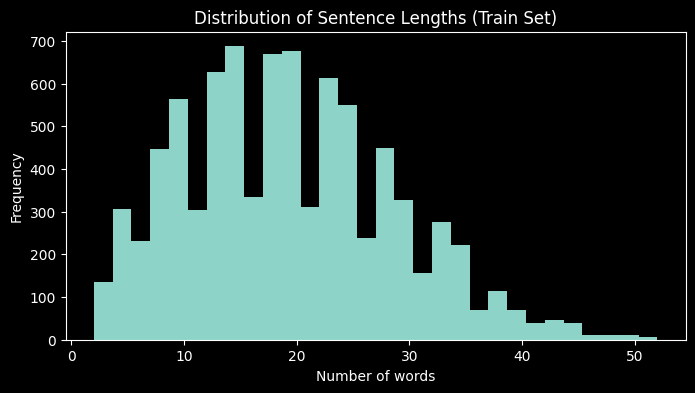

In [11]:
#Vẽ phân bố độ dài câu
plt.figure(figsize=(8, 4))
plt.hist(train_df["text_len"], bins=30)
plt.title("Distribution of Sentence Lengths (Train Set)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

### 5. Balanced sampling
- Để giảm thời gian huấn luyện nhưng vẫn đảm bảo sự công bằng giữa các lớp, bài làm sử dụng chiến lược lấy mẫu cân bằng trên tập train và validation. Cụ thể, từ mỗi lớp sẽ lấy ra cùng số lượng mẫu để tạo thành một tập con nhỏ hơn nhưng có phân bố nhãn đồng đều.

5.1. Hàm lấy mẫu cân bằng

In [12]:
def create_balanced_subset(df, samples_per_class=500, random_state=42):
    subset_list = []
    for label in sorted(df["label"].unique()):
        class_df = df[df["label"] == label]
        n = min(samples_per_class, len(class_df))
        sampled = class_df.sample(n=n, random_state=random_state)
        subset_list.append(sampled)
    subset_df = pd.concat(subset_list).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return subset_df

Tạo subset từ hàm trên

In [13]:
train_small_df = create_balanced_subset(train_df, samples_per_class=500)
val_small_df = create_balanced_subset(val_df, samples_per_class=150)

print("Balanced train subset:", train_small_df.shape)
print("Balanced validation subset:", val_small_df.shape)

show_class_distribution(train_small_df, "Balanced Train")
show_class_distribution(val_small_df, "Balanced Validation")

Balanced train subset: (2500, 5)
Balanced validation subset: (739, 5)

Balanced Train distribution:
label_name
negative         500
neutral          500
positive         500
very negative    500
very positive    500
Name: count, dtype: int64

Balanced Validation distribution:
label_name
negative         150
neutral          150
positive         150
very negative    139
very positive    150
Name: count, dtype: int64


label_name
negative         150
neutral          150
positive         150
very negative    139
very positive    150
Name: count, dtype: int64

### TIỀN XỬ LÝ DỮ LIỆU
- Với nhóm mô hình được huấn luyện từ đầu như LSTM, GRU và Transformer custom --> văn bản được đưa về chữ thường, loại bỏ khoảng trắng dư thừa, sau đó token hóa đơn giản theo khoảng trắng.

- Đối với nhóm pretrained Transformer/BERT, văn bản sẽ được xử lý bằng tokenizer chính thức của mô hình, do đó không cần can thiệp tiền xử lý quá mạnh.

In [14]:
#Clean text
def clean_text(text):
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

for df in [train_df, val_df, test_df, train_small_df, val_small_df]:
    df["clean_text"] = df["text"].apply(clean_text)


## PHẦN III. PIPELINE HUẤN LUYỆN
- Đối với LSTM, GRU và Transformer custom, văn bản sẽ được token hóa đơn giản, xây dựng vocabulary, ánh xạ thành các chỉ số và thực hiện padding hoặc truncation để các câu có cùng độ dài

Tokenize và build vocabulary

In [15]:
def tokenize(text):
    return text.split()

def build_vocab(texts, min_freq=2, specials=["<pad>", "<unk>"]):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))

    vocab = {}
    idx = 0

    for token in specials:
        vocab[token] = idx
        idx += 1

    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1

    return vocab

vocab = build_vocab(train_small_df["clean_text"].tolist(), min_freq=2)
print("Vocab size:", len(vocab))

Vocab size: 3349


In [16]:
#Endcode text
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

PAD_IDX = vocab[PAD_TOKEN]
UNK_IDX = vocab[UNK_TOKEN]

def encode_text(text, vocab, max_len=50):
    tokens = tokenize(text)
    ids = [vocab.get(token, UNK_IDX) for token in tokens]

    if len(ids) < max_len:
        ids = ids + [PAD_IDX] * (max_len - len(ids))
    else:
        ids = ids[:max_len]

    return ids

In [17]:
#Dataset cho LSTM/GRU/Transformer custom
class TextClassificationDataset(Dataset):
    def __init__(self, df, vocab, max_len=50):
        self.texts = df["clean_text"].tolist()
        self.labels = df["label"].tolist()
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        input_ids = encode_text(text, self.vocab, self.max_len)

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "label": torch.tensor(label, dtype=torch.long)
        }

In [18]:
MAX_LEN = 50
BATCH_SIZE = 32
train_dataset = TextClassificationDataset(train_small_df, vocab, max_len=MAX_LEN)
val_dataset = TextClassificationDataset(val_small_df, vocab, max_len=MAX_LEN)
test_dataset = TextClassificationDataset(test_df, vocab, max_len=MAX_LEN)

for idx in range(7):
    raw_text = train_small_df.iloc[idx]["text"]
    clean_text_sample = train_small_df.iloc[idx]["clean_text"]
    label_name = train_small_df.iloc[idx]["label_name"]

    sample = train_dataset[idx]

    print(f"Example {idx}")
    print("Raw text   :", raw_text)
    print("Clean text :", clean_text_sample)
    print("Input IDs  :", sample["input_ids"].tolist())
    print("Label      :", f"{sample['label'].item()} - {label_name}")
    print("-" * 100)

Example 0
Raw text   : a dark , dull thriller with a parting shot that misfires .
Clean text : a dark , dull thriller with a parting shot that misfires .
Input IDs  : [2, 3, 4, 5, 6, 7, 2, 1, 8, 9, 1, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Label      : 2 - neutral
----------------------------------------------------------------------------------------------------
Example 1
Raw text   : the movie is obviously a labour of love so howard appears to have had free rein to be as pretentious as he wanted .
Clean text : the movie is obviously a labour of love so howard appears to have had free rein to be as pretentious as he wanted .
Input IDs  : [11, 12, 13, 14, 2, 1, 15, 16, 17, 18, 19, 20, 21, 22, 23, 1, 20, 24, 25, 26, 25, 27, 28, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Label      : 2 - neutral
-----------------------------------------------------------------------------

In [19]:
#Tạo data loader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

#### Hàm đánh giá chung
Do dataset có multiclass 5 lớp, mà yêu cầu đánh giá mô hình qua F1 và macro-F1, nên ta thực hiện quy ước:
- precision, recall, F1 = weighted average
- macro-F1 = macro average

In [20]:
#ComputeMetrics
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)

    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    return {
        "accuracy": acc,
        "precision": precision_w,
        "recall": recall_w,
        "f1": f1_w,
        "macro_f1": macro_f1
    }

#### Hàm huấn luyện và evaluate chung
Trong quá trình huấn luyện, mô hình sẽ được đánh giá sau mỗi epoch trên tập validation. Các giá trị train loss, validation loss, train macro-F1 và validation macro-F1 sẽ được lưu lại

In [21]:
#Train one epoch
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="Training", leave=False):
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    metrics = compute_metrics(all_labels, all_preds)
    return avg_loss, metrics

In [22]:
#Evaluate
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    metrics = compute_metrics(all_labels, all_preds)
    return avg_loss, metrics, all_labels, all_preds

In [23]:
#Train full model
def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=5):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_precision": [],
        "val_precision": [],
        "train_recall": [],
        "val_recall": [],
        "train_f1": [],
        "val_f1": [],
        "train_macro_f1": [],
        "val_macro_f1": []
    }

    best_val_macro_f1 = -1
    best_state = None

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        train_loss, train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_metrics, _, _ = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        history["train_acc"].append(train_metrics["accuracy"])
        history["val_acc"].append(val_metrics["accuracy"])

        history["train_precision"].append(train_metrics["precision"])
        history["val_precision"].append(val_metrics["precision"])

        history["train_recall"].append(train_metrics["recall"])
        history["val_recall"].append(val_metrics["recall"])

        history["train_f1"].append(train_metrics["f1"])
        history["val_f1"].append(val_metrics["f1"])

        history["train_macro_f1"].append(train_metrics["macro_f1"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])

        print(
            f"Train Loss: {train_loss:.4f} | "
            f"Acc: {train_metrics['accuracy']:.4f} | "
            f"Prec: {train_metrics['precision']:.4f} | "
            f"Recall: {train_metrics['recall']:.4f} | "
            f"F1: {train_metrics['f1']:.4f} | "
            f"Macro-F1: {train_metrics['macro_f1']:.4f}"
        )
        print(
            f"Val   Loss: {val_loss:.4f} | "
            f"Acc: {val_metrics['accuracy']:.4f} | "
            f"Prec: {val_metrics['precision']:.4f} | "
            f"Recall: {val_metrics['recall']:.4f} | "
            f"F1: {val_metrics['f1']:.4f} | "
            f"Macro-F1: {val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_state = model.state_dict()

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

#### Hàm vẽ learning curve


In [24]:
def plot_learning_curves(history, title="Learning Curves", save_path=None):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(18, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_f1"], label="Train F1")
    plt.plot(epochs, history["val_f1"], label="Val F1")
    plt.title(f"{title} - F1")
    plt.xlabel("Epoch")
    plt.ylabel("F1")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["train_macro_f1"], label="Train Macro-F1")
    plt.plot(epochs, history["val_macro_f1"], label="Val Macro-F1")
    plt.title(f"{title} - Macro-F1")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.legend()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

## PHẦN IV. THỰC NGHIỆM VỚI LSTM VÀ GRU

Lớp RecurrentClassifier

In [25]:
class RecurrentClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        hidden_dim=128,
        num_layers=1,
        num_classes=5,
        dropout=0.3,
        bidirectional=False,
        rnn_type="lstm",
        pooling="mean",
        pad_idx=0
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn_type = rnn_type.lower()
        self.pooling = pooling
        self.bidirectional = bidirectional
        self.hidden_dim = hidden_dim

        if self.rnn_type == "lstm":
            self.rnn = nn.LSTM(
                input_size=embed_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=bidirectional
            )
        elif self.rnn_type == "gru":
            self.rnn = nn.GRU(
                input_size=embed_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=bidirectional
            )
        else:
            raise ValueError("rnn_type must be either 'lstm' or 'gru'")

        output_dim = hidden_dim * 2 if bidirectional else hidden_dim

        if pooling == "attention":
            self.attention = nn.Linear(output_dim, 1)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(output_dim, num_classes)

    def forward(self, input_ids):
        x = self.embedding(input_ids)          # (B, L, E)
        outputs, hidden = self.rnn(x)          # outputs: (B, L, H)

        if self.pooling == "last":
            rep = outputs[:, -1, :]

        elif self.pooling == "mean":
            rep = outputs.mean(dim=1)

        elif self.pooling == "max":
            rep, _ = outputs.max(dim=1)

        elif self.pooling == "attention":
            attn_scores = self.attention(outputs)             # (B, L, 1)
            attn_weights = torch.softmax(attn_scores, dim=1)
            rep = torch.sum(attn_weights * outputs, dim=1)   # (B, H)

        else:
            raise ValueError("pooling must be one of: last, mean, max, attention")

        rep = self.dropout(rep)
        logits = self.fc(rep)
        return logits

### 1. So sánh LSTM và GRU
So sánh trực tiếp giữa hai kiến trúc LSTM và GRU trong cùng một điều kiện huấn luyện và Cấu hình baseline được chọn như sau:
- embed_dim = 128
- hidden_dim = 128
- num_layers = 1
- bidirectional = True
- pooling = mean
- dropout = 0.3
- epochs = 5

Khai báo criterion

In [26]:
criterion = nn.CrossEntropyLoss()

#### Train baseline LSTM

In [31]:
lstm_model = RecurrentClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=128,
    num_layers=1,
    num_classes=5,
    dropout=0.3,
    bidirectional=True,
    rnn_type="lstm",
    pooling="mean",
    pad_idx=PAD_IDX
).to(device)

lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)

lstm_model, lstm_history = train_model(
    lstm_model,
    train_loader,
    val_loader,
    lstm_optimizer,
    criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.6057 | Acc: 0.2164 | Prec: 0.2409 | Recall: 0.2164 | F1: 0.1905 | Macro-F1: 0.1905
Val   Loss: 1.5991 | Acc: 0.2652 | Prec: 0.2549 | Recall: 0.2652 | F1: 0.2387 | Macro-F1: 0.2392

Epoch 2/5


Train Loss: 1.5567 | Acc: 0.3040 | Prec: 0.3003 | Recall: 0.3040 | F1: 0.2805 | Macro-F1: 0.2805
Val   Loss: 1.5700 | Acc: 0.2585 | Prec: 0.2474 | Recall: 0.2585 | F1: 0.2115 | Macro-F1: 0.2099

Epoch 3/5


Train Loss: 1.4755 | Acc: 0.3452 | Prec: 0.3351 | Recall: 0.3452 | F1: 0.3231 | Macro-F1: 0.3231
Val   Loss: 1.5943 | Acc: 0.2733 | Prec: 0.2999 | Recall: 0.2733 | F1: 0.2523 | Macro-F1: 0.2532

Epoch 4/5


Train Loss: 1.3329 | Acc: 0.4288 | Prec: 0.4167 | Recall: 0.4288 | F1: 0.4121 | Macro-F1: 0.4121
Val   Loss: 1.5435 | Acc: 0.3342 | Prec: 0.3063 | Recall: 0.3342 | F1: 0.3020 | Macro-F1: 0.3032

Epoch 5/5


Train Loss: 1.1935 | Acc: 0.4996 | Prec: 0.4916 | Recall: 0.4996 | F1: 0.4868 | Macro-F1: 0.4868
Val   Loss: 1.5679 | Acc: 0.3099 | Prec: 0.3172 | Recall: 0.3099 | F1: 0.3112 | Macro-F1: 0.3117


#### Learning curve cho LSTM

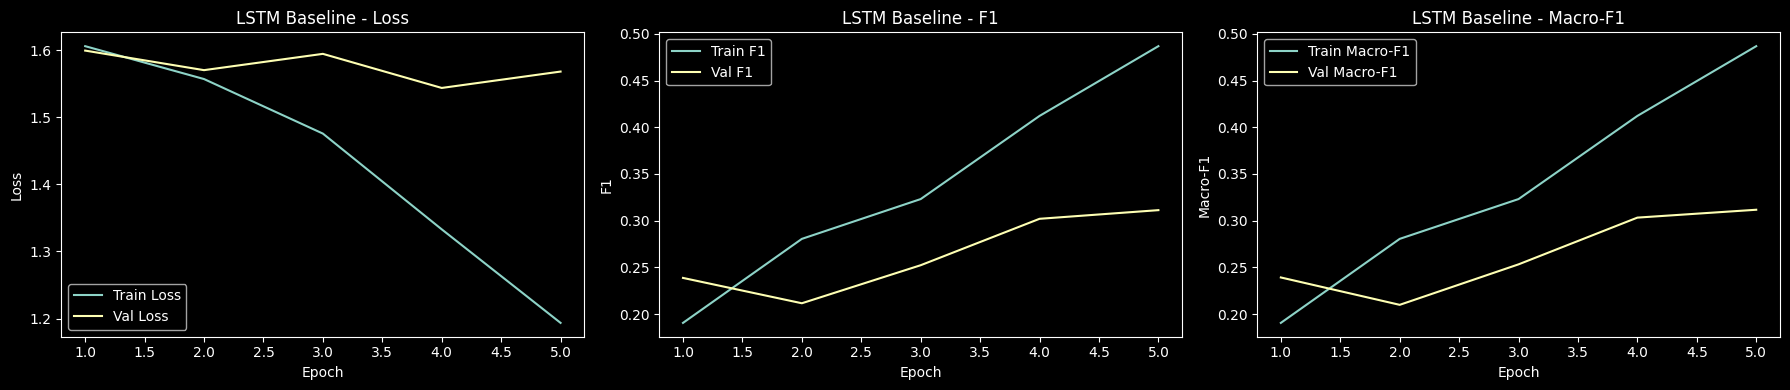

In [32]:
plot_learning_curves(lstm_history, title="LSTM Baseline")

#### Đánh giá LSTM trên tập test

In [33]:
lstm_test_loss, lstm_test_metrics, y_true_lstm, y_pred_lstm = evaluate(
    lstm_model, test_loader, criterion, device
)

print("LSTM Test Loss:", round(lstm_test_loss, 4))
print("LSTM Test Metrics:", lstm_test_metrics)

LSTM Test Loss: 1.554
LSTM Test Metrics: {'accuracy': 0.3199095022624434, 'precision': 0.3417302436947739, 'recall': 0.3199095022624434, 'f1': 0.32124220061545805, 'macro_f1': 0.32288003050550557}


#### Classification report cho LSTM

In [34]:
print("=== LSTM Classification Report ===")
print(
    classification_report(
        y_true_lstm,
        y_pred_lstm,
        target_names=[label_map[i] for i in range(5)],
        zero_division=0
    )
)

=== LSTM Classification Report ===
               precision    recall  f1-score   support

very negative       0.26      0.39      0.31       279
     negative       0.39      0.26      0.31       633
      neutral       0.23      0.36      0.29       389
     positive       0.34      0.26      0.30       510
very positive       0.42      0.40      0.41       399

     accuracy                           0.32      2210
    macro avg       0.33      0.33      0.32      2210
 weighted avg       0.34      0.32      0.32      2210



#### Train baseline GRU

In [36]:
gru_model = RecurrentClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=128,
    num_layers=1,
    num_classes=5,
    dropout=0.3,
    bidirectional=True,
    rnn_type="gru",
    pooling="mean",
    pad_idx=PAD_IDX
).to(device)

gru_optimizer = torch.optim.Adam(gru_model.parameters(), lr=1e-3)

gru_model, gru_history = train_model(
    gru_model,
    train_loader,
    val_loader,
    gru_optimizer,
    criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.6000 | Acc: 0.2288 | Prec: 0.2316 | Recall: 0.2288 | F1: 0.2269 | Macro-F1: 0.2269
Val   Loss: 1.5911 | Acc: 0.2341 | Prec: 0.2502 | Recall: 0.2341 | F1: 0.2050 | Macro-F1: 0.2040

Epoch 2/5


Train Loss: 1.5464 | Acc: 0.3148 | Prec: 0.3119 | Recall: 0.3148 | F1: 0.2910 | Macro-F1: 0.2910
Val   Loss: 1.5569 | Acc: 0.2950 | Prec: 0.2960 | Recall: 0.2950 | F1: 0.2876 | Macro-F1: 0.2868

Epoch 3/5


Train Loss: 1.4567 | Acc: 0.3712 | Prec: 0.3701 | Recall: 0.3712 | F1: 0.3551 | Macro-F1: 0.3551
Val   Loss: 1.5379 | Acc: 0.2869 | Prec: 0.2923 | Recall: 0.2869 | F1: 0.2605 | Macro-F1: 0.2624

Epoch 4/5


Train Loss: 1.2863 | Acc: 0.4588 | Prec: 0.4507 | Recall: 0.4588 | F1: 0.4485 | Macro-F1: 0.4485
Val   Loss: 1.5759 | Acc: 0.2896 | Prec: 0.3171 | Recall: 0.2896 | F1: 0.2784 | Macro-F1: 0.2783

Epoch 5/5


Train Loss: 1.0907 | Acc: 0.5540 | Prec: 0.5514 | Recall: 0.5540 | F1: 0.5495 | Macro-F1: 0.5495
Val   Loss: 1.6932 | Acc: 0.3058 | Prec: 0.3004 | Recall: 0.3058 | F1: 0.2889 | Macro-F1: 0.2902


#### Vẽ learning curve cho GRU

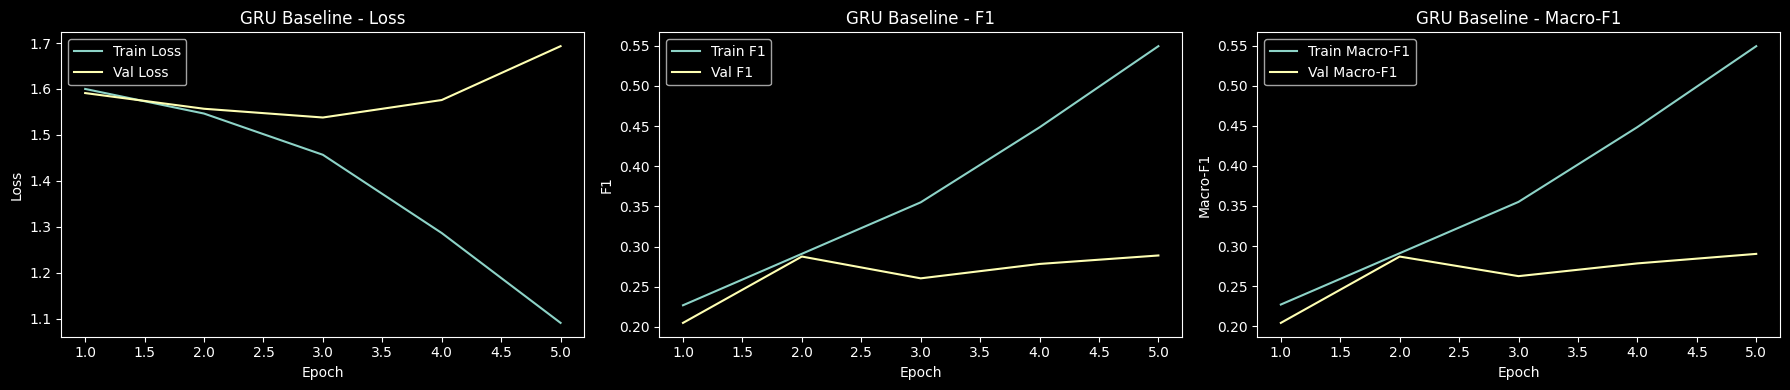

In [37]:
plot_learning_curves(gru_history, title="GRU Baseline")

#### Đánh giá GRU trên tập test

In [38]:
gru_test_loss, gru_test_metrics, y_true_gru, y_pred_gru = evaluate(
    gru_model, test_loader, criterion, device
)

print("GRU Test Loss:", round(gru_test_loss, 4))
print("GRU Test Metrics:", gru_test_metrics)

GRU Test Loss: 1.7196
GRU Test Metrics: {'accuracy': 0.27828054298642535, 'precision': 0.3160502102492074, 'recall': 0.27828054298642535, 'f1': 0.2598529709459394, 'macro_f1': 0.273285547574455}


#### Classification report cho GRU

In [39]:
print("=== GRU Classification Report ===")
print(
    classification_report(
        y_true_gru,
        y_pred_gru,
        target_names=[label_map[i] for i in range(5)],
        zero_division=0
    )
)

=== GRU Classification Report ===
               precision    recall  f1-score   support

very negative       0.19      0.63      0.30       279
     negative       0.35      0.10      0.16       633
      neutral       0.24      0.19      0.21       389
     positive       0.32      0.22      0.26       510
very positive       0.41      0.47      0.43       399

     accuracy                           0.28      2210
    macro avg       0.30      0.32      0.27      2210
 weighted avg       0.32      0.28      0.26      2210



#### So sánh baseline LSTM và GRU

In [40]:
baseline_results_df = pd.DataFrame([
    {
        "model": "LSTM",
        "accuracy": lstm_test_metrics["accuracy"],
        "precision": lstm_test_metrics["precision"],
        "recall": lstm_test_metrics["recall"],
        "macro_f1": lstm_test_metrics["macro_f1"]
    },
    {
        "model": "GRU",
        "accuracy": gru_test_metrics["accuracy"],
        "precision": gru_test_metrics["precision"],
        "recall": gru_test_metrics["recall"],
        "macro_f1": gru_test_metrics["macro_f1"]
    }
])

baseline_results_df.sort_values(by="macro_f1", ascending=False).reset_index(drop=True)

,model,accuracy,precision,recall,macro_f1
0,LSTM,0.319910,0.34173,0.319910,0.322880
1,GRU,0.278281,0.31605,0.278281,0.273286


### 2. Ảnh hưởng của số lớp recurrent
Để đảm bảo phép so sánh công bằng, các hyperparameter khác được giữ cố định. Thí nghiệm được thực hiện riêng cho cả LSTM và GRU, sau đó so sánh kết quả giữa hai mô hình.

#### Train LSTM 2 layer

In [41]:
lstm_2layer_model = RecurrentClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=128,
    num_layers=2,
    num_classes=5,
    dropout=0.3,
    bidirectional=True,
    rnn_type="lstm",
    pooling="mean",
    pad_idx=PAD_IDX
).to(device)

lstm_2layer_optimizer = torch.optim.Adam(lstm_2layer_model.parameters(), lr=1e-3)

lstm_2layer_model, lstm_2layer_history = train_model(
    lstm_2layer_model,
    train_loader,
    val_loader,
    lstm_2layer_optimizer,
    criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.6069 | Acc: 0.2144 | Prec: 0.1988 | Recall: 0.2144 | F1: 0.1845 | Macro-F1: 0.1845
Val   Loss: 1.6022 | Acc: 0.2219 | Prec: 0.2703 | Recall: 0.2219 | F1: 0.1705 | Macro-F1: 0.1688

Epoch 2/5


Train Loss: 1.5698 | Acc: 0.2692 | Prec: 0.2568 | Recall: 0.2692 | F1: 0.2417 | Macro-F1: 0.2417
Val   Loss: 1.5743 | Acc: 0.2571 | Prec: 0.2735 | Recall: 0.2571 | F1: 0.2074 | Macro-F1: 0.2047

Epoch 3/5


Train Loss: 1.4602 | Acc: 0.3476 | Prec: 0.3394 | Recall: 0.3476 | F1: 0.3269 | Macro-F1: 0.3269
Val   Loss: 1.5327 | Acc: 0.3085 | Prec: 0.2705 | Recall: 0.3085 | F1: 0.2514 | Macro-F1: 0.2535

Epoch 4/5


Train Loss: 1.3026 | Acc: 0.4400 | Prec: 0.4334 | Recall: 0.4400 | F1: 0.4251 | Macro-F1: 0.4251
Val   Loss: 1.5246 | Acc: 0.3194 | Prec: 0.3232 | Recall: 0.3194 | F1: 0.3110 | Macro-F1: 0.3121

Epoch 5/5


Train Loss: 1.0885 | Acc: 0.5380 | Prec: 0.5385 | Recall: 0.5380 | F1: 0.5301 | Macro-F1: 0.5301
Val   Loss: 1.6427 | Acc: 0.3261 | Prec: 0.3363 | Recall: 0.3261 | F1: 0.3245 | Macro-F1: 0.3254


#### Learning curve LSTM

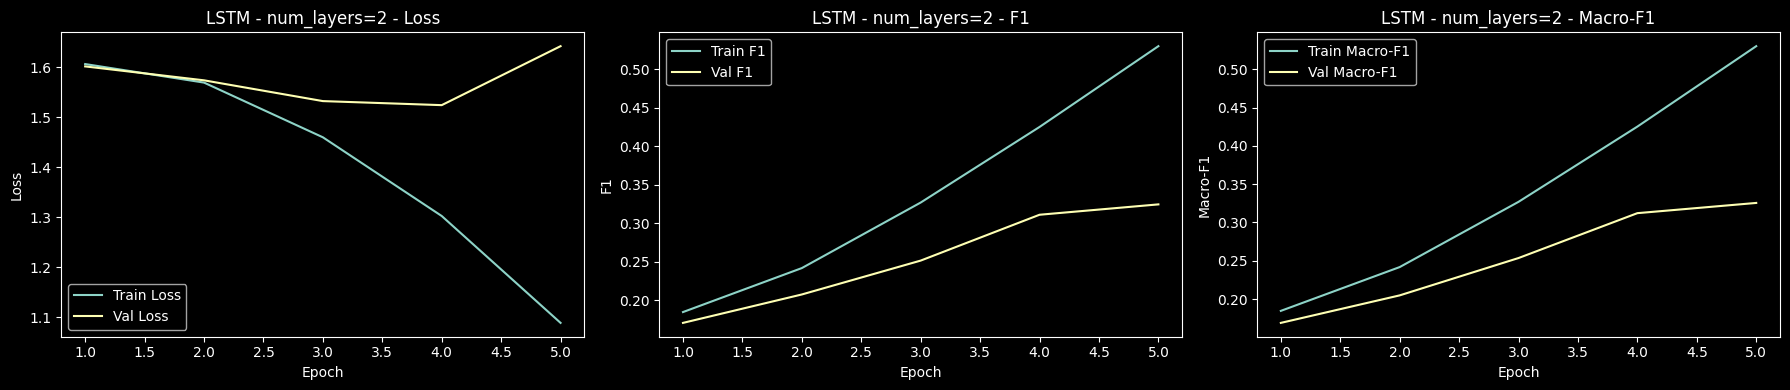

In [42]:
plot_learning_curves(lstm_2layer_history, title="LSTM - num_layers=2")

#### Đánh giá trên tập test

In [43]:
lstm_2layer_test_loss, lstm_2layer_test_metrics, y_true_lstm_2layer, y_pred_lstm_2layer = evaluate(
    lstm_2layer_model, test_loader, criterion, device
)

print("LSTM (2 layers) Test Loss:", round(lstm_2layer_test_loss, 4))
print("LSTM (2 layers) Test Metrics:", lstm_2layer_test_metrics)

LSTM (2 layers) Test Loss: 1.6541
LSTM (2 layers) Test Metrics: {'accuracy': 0.3049773755656109, 'precision': 0.3316437852887675, 'recall': 0.3049773755656109, 'f1': 0.30284506101707, 'macro_f1': 0.30648361851219225}


#### Classification report

In [44]:
print("=== LSTM (num_layers=2) Classification Report ===")
print(
    classification_report(
        y_true_lstm_2layer,
        y_pred_lstm_2layer,
        target_names=[label_map[i] for i in range(5)],
        zero_division=0
    )
)

=== LSTM (num_layers=2) Classification Report ===
               precision    recall  f1-score   support

very negative       0.21      0.42      0.29       279
     negative       0.38      0.18      0.24       633
      neutral       0.25      0.28      0.26       389
     positive       0.32      0.36      0.34       510
very positive       0.44      0.38      0.41       399

     accuracy                           0.30      2210
    macro avg       0.32      0.32      0.31      2210
 weighted avg       0.33      0.30      0.30      2210



#### Train GRU 2 layers

In [45]:
gru_2layer_model = RecurrentClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=128,
    num_layers=2,
    num_classes=5,
    dropout=0.3,
    bidirectional=True,
    rnn_type="gru",
    pooling="mean",
    pad_idx=PAD_IDX
).to(device)

gru_2layer_optimizer = torch.optim.Adam(gru_2layer_model.parameters(), lr=1e-3)

gru_2layer_model, gru_2layer_history = train_model(
    gru_2layer_model,
    train_loader,
    val_loader,
    gru_2layer_optimizer,
    criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.5977 | Acc: 0.2436 | Prec: 0.2415 | Recall: 0.2436 | F1: 0.2379 | Macro-F1: 0.2379
Val   Loss: 1.5798 | Acc: 0.2706 | Prec: 0.2651 | Recall: 0.2706 | F1: 0.2440 | Macro-F1: 0.2432

Epoch 2/5


Train Loss: 1.5358 | Acc: 0.3044 | Prec: 0.2971 | Recall: 0.3044 | F1: 0.2897 | Macro-F1: 0.2897
Val   Loss: 1.5469 | Acc: 0.3126 | Prec: 0.2921 | Recall: 0.3126 | F1: 0.2759 | Macro-F1: 0.2765

Epoch 3/5


Train Loss: 1.3957 | Acc: 0.3976 | Prec: 0.3923 | Recall: 0.3976 | F1: 0.3897 | Macro-F1: 0.3897
Val   Loss: 1.5954 | Acc: 0.3139 | Prec: 0.2765 | Recall: 0.3139 | F1: 0.2547 | Macro-F1: 0.2569

Epoch 4/5


Train Loss: 1.2229 | Acc: 0.4768 | Prec: 0.4686 | Recall: 0.4768 | F1: 0.4632 | Macro-F1: 0.4632
Val   Loss: 1.7149 | Acc: 0.2842 | Prec: 0.3058 | Recall: 0.2842 | F1: 0.2758 | Macro-F1: 0.2767

Epoch 5/5


Train Loss: 0.9981 | Acc: 0.5900 | Prec: 0.5859 | Recall: 0.5900 | F1: 0.5867 | Macro-F1: 0.5867
Val   Loss: 1.8209 | Acc: 0.2869 | Prec: 0.2927 | Recall: 0.2869 | F1: 0.2717 | Macro-F1: 0.2721


#### Learning curve

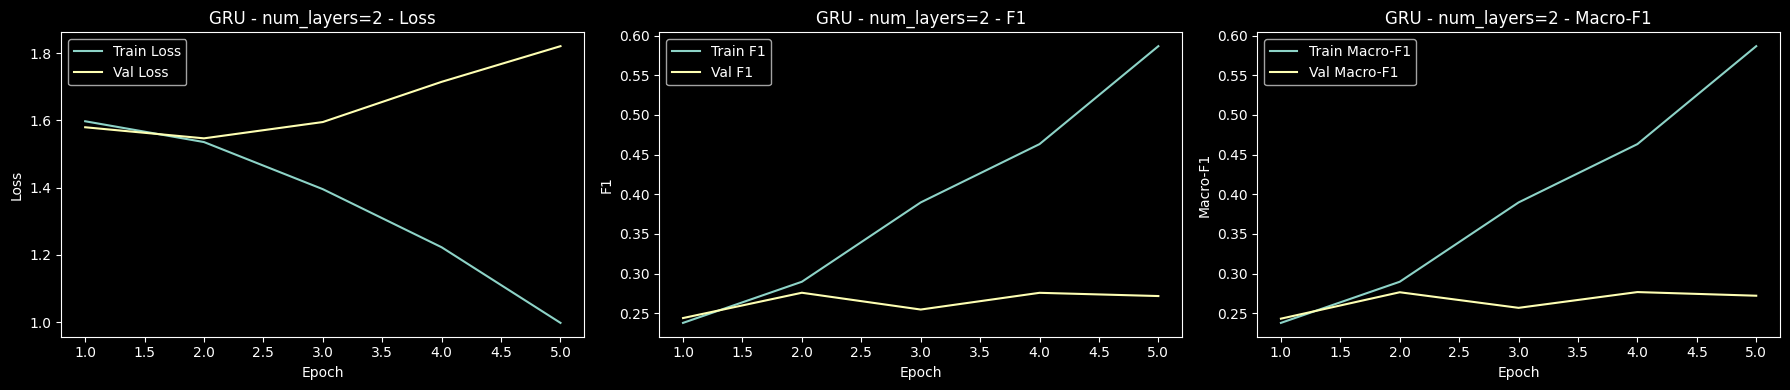

In [46]:
plot_learning_curves(gru_2layer_history, title="GRU - num_layers=2")

#### Đánh giá trên tập test

In [47]:
gru_2layer_test_loss, gru_2layer_test_metrics, y_true_gru_2layer, y_pred_gru_2layer = evaluate(
    gru_2layer_model, test_loader, criterion, device
)

print("GRU (2 layers) Test Loss:", round(gru_2layer_test_loss, 4))
print("GRU (2 layers) Test Metrics:", gru_2layer_test_metrics)

GRU (2 layers) Test Loss: 1.7898
GRU (2 layers) Test Metrics: {'accuracy': 0.3009049773755656, 'precision': 0.3366386503655198, 'recall': 0.3009049773755656, 'f1': 0.2784969909449354, 'macro_f1': 0.2862266580138591}


#### Classification Report

In [48]:
print("=== GRU (num_layers=2) Classification Report ===")
print(
    classification_report(
        y_true_gru_2layer,
        y_pred_gru_2layer,
        target_names=[label_map[i] for i in range(5)],
        zero_division=0
    )
)

=== GRU (num_layers=2) Classification Report ===
               precision    recall  f1-score   support

very negative       0.24      0.42      0.31       279
     negative       0.44      0.12      0.18       633
      neutral       0.26      0.15      0.19       389
     positive       0.28      0.51      0.36       510
very positive       0.39      0.38      0.38       399

     accuracy                           0.30      2210
    macro avg       0.32      0.32      0.29      2210
 weighted avg       0.34      0.30      0.28      2210



#### So sánh giữa LSTM và GRU

In [49]:
recurrent_layer_compare_df = pd.DataFrame([
    # {
    #     "model": "LSTM",
    #     "num_layers": 1,
    #     "accuracy": lstm_test_metrics["accuracy"],
    #     "precision": lstm_test_metrics["precision"],
    #     "recall": lstm_test_metrics["recall"],
    #     "f1": lstm_test_metrics["f1"],
    #     "macro_f1": lstm_test_metrics["macro_f1"]
    # },
    # {
    #     "model": "GRU",
    #     "num_layers": 1,
    #     "accuracy": gru_test_metrics["accuracy"],
    #     "precision": gru_test_metrics["precision"],
    #     "recall": gru_test_metrics["recall"],
    #     "f1": gru_test_metrics["f1"],
    #     "macro_f1": gru_test_metrics["macro_f1"]
    # },
    {
        "model": "LSTM",
        "num_layers": 2,
        "accuracy": lstm_2layer_test_metrics["accuracy"],
        "precision": lstm_2layer_test_metrics["precision"],
        "recall": lstm_2layer_test_metrics["recall"],
        "f1": lstm_2layer_test_metrics["f1"],
        "macro_f1": lstm_2layer_test_metrics["macro_f1"]
    },
    {
        "model": "GRU",
        "num_layers": 2,
        "accuracy": gru_2layer_test_metrics["accuracy"],
        "precision": gru_2layer_test_metrics["precision"],
        "recall": gru_2layer_test_metrics["recall"],
        "f1": gru_2layer_test_metrics["f1"],
        "macro_f1": gru_2layer_test_metrics["macro_f1"]
    }
])

recurrent_layer_compare_df.sort_values(by=["model", "num_layers"]).reset_index(drop=True)

,model,num_layers,accuracy,precision,recall,f1,macro_f1
0,GRU,2,0.300905,0.336639,0.300905,0.278497,0.286227
1,LSTM,2,0.304977,0.331644,0.304977,0.302845,0.306484


### 3. Ảnh hưởng của bidirectional

#### Train LSTM với bidirectional = False

In [50]:
lstm_uni_model = RecurrentClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=128,
    num_layers=1,
    num_classes=5,
    dropout=0.3,
    bidirectional=False,
    rnn_type="lstm",
    pooling="mean",
    pad_idx=PAD_IDX
).to(device)

lstm_uni_optimizer = torch.optim.Adam(lstm_uni_model.parameters(), lr=1e-3)

lstm_uni_model, lstm_uni_history = train_model(
    lstm_uni_model,
    train_loader,
    val_loader,
    lstm_uni_optimizer,
    criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.6046 | Acc: 0.2272 | Prec: 0.2351 | Recall: 0.2272 | F1: 0.1962 | Macro-F1: 0.1962
Val   Loss: 1.5954 | Acc: 0.2314 | Prec: 0.2747 | Recall: 0.2314 | F1: 0.1993 | Macro-F1: 0.1967

Epoch 2/5


Train Loss: 1.5545 | Acc: 0.2936 | Prec: 0.3101 | Recall: 0.2936 | F1: 0.2437 | Macro-F1: 0.2437
Val   Loss: 1.5810 | Acc: 0.2490 | Prec: 0.2990 | Recall: 0.2490 | F1: 0.2261 | Macro-F1: 0.2241

Epoch 3/5


Train Loss: 1.4714 | Acc: 0.3532 | Prec: 0.3495 | Recall: 0.3532 | F1: 0.3425 | Macro-F1: 0.3425
Val   Loss: 1.5534 | Acc: 0.2842 | Prec: 0.2715 | Recall: 0.2842 | F1: 0.2441 | Macro-F1: 0.2417

Epoch 4/5


Train Loss: 1.3960 | Acc: 0.3948 | Prec: 0.3946 | Recall: 0.3948 | F1: 0.3743 | Macro-F1: 0.3743
Val   Loss: 1.5205 | Acc: 0.3058 | Prec: 0.3101 | Recall: 0.3058 | F1: 0.2824 | Macro-F1: 0.2830

Epoch 5/5


Train Loss: 1.2440 | Acc: 0.4604 | Prec: 0.4567 | Recall: 0.4604 | F1: 0.4449 | Macro-F1: 0.4449
Val   Loss: 1.6138 | Acc: 0.3112 | Prec: 0.3063 | Recall: 0.3112 | F1: 0.2879 | Macro-F1: 0.2892


#### LSTM learning curve

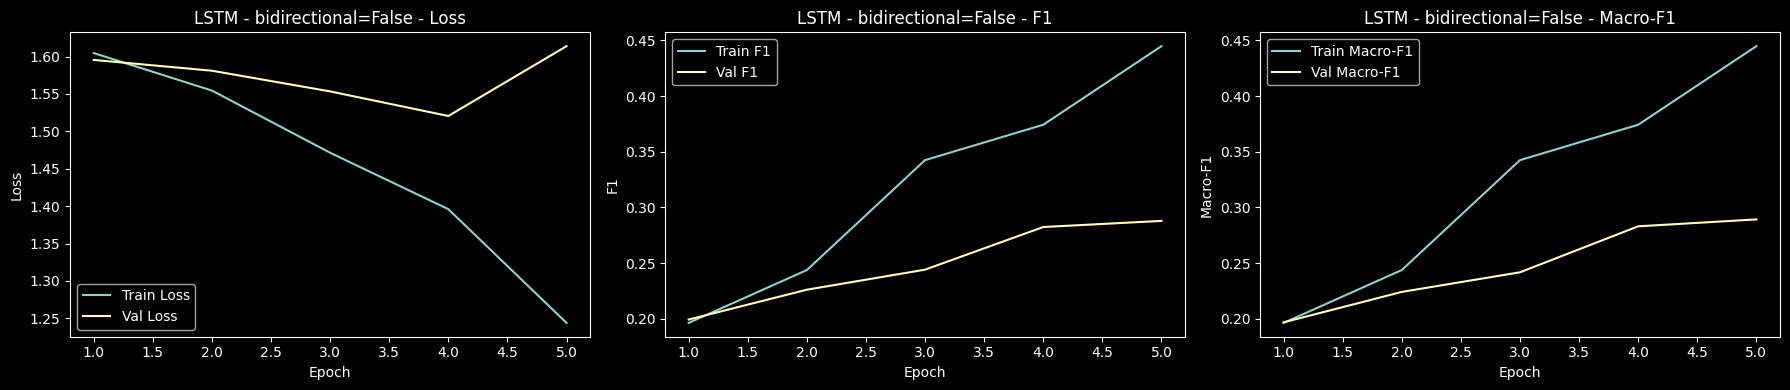

In [51]:
plot_learning_curves(lstm_uni_history, title="LSTM - bidirectional=False")

#### Đánh giá trên tập test

In [52]:
lstm_uni_test_loss, lstm_uni_test_metrics, y_true_lstm_uni, y_pred_lstm_uni = evaluate(
    lstm_uni_model, test_loader, criterion, device
)

print("LSTM (bidirectional=False) Test Loss:", round(lstm_uni_test_loss, 4))
print("LSTM (bidirectional=False) Test Metrics:", lstm_uni_test_metrics)

LSTM (bidirectional=False) Test Loss: 1.6218
LSTM (bidirectional=False) Test Metrics: {'accuracy': 0.2819004524886878, 'precision': 0.3128076469409635, 'recall': 0.2819004524886878, 'f1': 0.25040449988384605, 'macro_f1': 0.2746670912403194}


#### Train GRU với bidirectional = False

In [53]:
gru_uni_model = RecurrentClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=128,
    num_layers=1,
    num_classes=5,
    dropout=0.3,
    bidirectional=False,
    rnn_type="gru",
    pooling="mean",
    pad_idx=PAD_IDX
).to(device)

gru_uni_optimizer = torch.optim.Adam(gru_uni_model.parameters(), lr=1e-3)

gru_uni_model, gru_uni_history = train_model(
    gru_uni_model,
    train_loader,
    val_loader,
    gru_uni_optimizer,
    criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.6022 | Acc: 0.2212 | Prec: 0.2209 | Recall: 0.2212 | F1: 0.2157 | Macro-F1: 0.2157
Val   Loss: 1.5939 | Acc: 0.2801 | Prec: 0.2833 | Recall: 0.2801 | F1: 0.2567 | Macro-F1: 0.2577

Epoch 2/5


Train Loss: 1.5625 | Acc: 0.3108 | Prec: 0.3079 | Recall: 0.3108 | F1: 0.2969 | Macro-F1: 0.2969
Val   Loss: 1.5679 | Acc: 0.2963 | Prec: 0.2898 | Recall: 0.2963 | F1: 0.2593 | Macro-F1: 0.2581

Epoch 3/5


Train Loss: 1.4759 | Acc: 0.3484 | Prec: 0.3430 | Recall: 0.3484 | F1: 0.3282 | Macro-F1: 0.3282
Val   Loss: 1.5480 | Acc: 0.2828 | Prec: 0.3112 | Recall: 0.2828 | F1: 0.2682 | Macro-F1: 0.2672

Epoch 4/5


Train Loss: 1.3221 | Acc: 0.4392 | Prec: 0.4366 | Recall: 0.4392 | F1: 0.4325 | Macro-F1: 0.4325
Val   Loss: 1.5509 | Acc: 0.2923 | Prec: 0.3097 | Recall: 0.2923 | F1: 0.2825 | Macro-F1: 0.2834

Epoch 5/5


Train Loss: 1.1767 | Acc: 0.5216 | Prec: 0.5169 | Recall: 0.5216 | F1: 0.5095 | Macro-F1: 0.5095
Val   Loss: 1.6504 | Acc: 0.2991 | Prec: 0.2948 | Recall: 0.2991 | F1: 0.2942 | Macro-F1: 0.2946


#### GRU learning curve

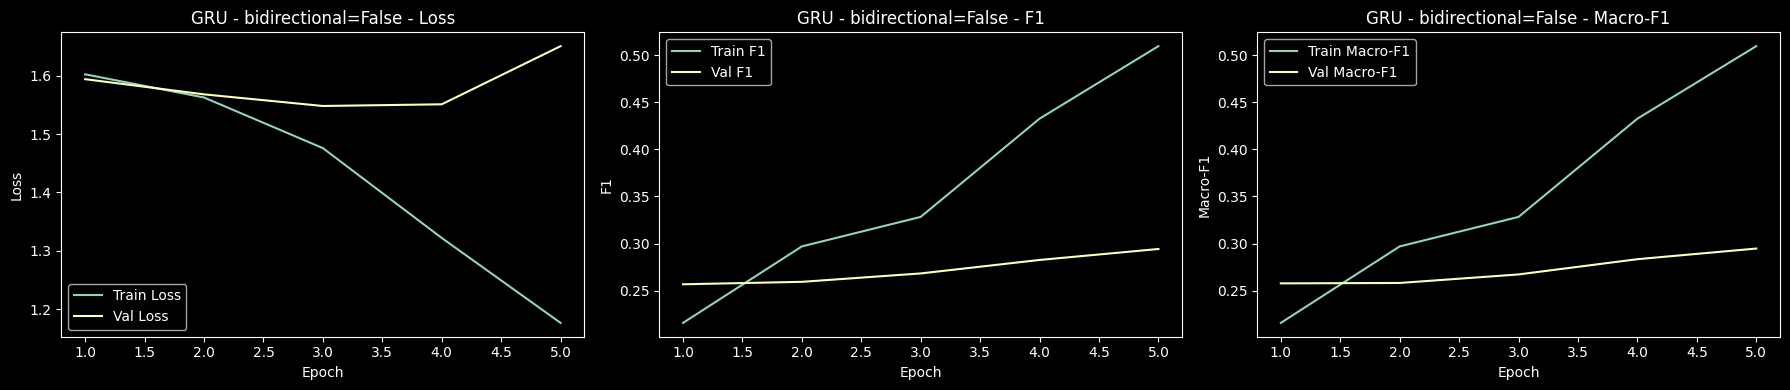

In [54]:
plot_learning_curves(gru_uni_history, title="GRU - bidirectional=False")

#### Đánh giá trên tập test

In [55]:
gru_uni_test_loss, gru_uni_test_metrics, y_true_gru_uni, y_pred_gru_uni = evaluate(
    gru_uni_model, test_loader, criterion, device
)

print("GRU (bidirectional=False) Test Loss:", round(gru_uni_test_loss, 4))
print("GRU (bidirectional=False) Test Metrics:", gru_uni_test_metrics)

GRU (bidirectional=False) Test Loss: 1.6552
GRU (bidirectional=False) Test Metrics: {'accuracy': 0.31447963800904977, 'precision': 0.3292973812608423, 'recall': 0.31447963800904977, 'f1': 0.3128663473710246, 'macro_f1': 0.3098408748812605}


#### So sánh giữa LSTM và GRU

In [56]:
bidirectional_compare_df = pd.DataFrame([
    {
        "model": "LSTM",
        "bidirectional": True,
        "accuracy": lstm_test_metrics["accuracy"],
        "precision": lstm_test_metrics["precision"],
        "recall": lstm_test_metrics["recall"],
        "f1": lstm_test_metrics["f1"],
        "macro_f1": lstm_test_metrics["macro_f1"]
    },
    {
        "model": "LSTM",
        "bidirectional": False,
        "accuracy": lstm_uni_test_metrics["accuracy"],
        "precision": lstm_uni_test_metrics["precision"],
        "recall": lstm_uni_test_metrics["recall"],
        "f1": lstm_uni_test_metrics["f1"],
        "macro_f1": lstm_uni_test_metrics["macro_f1"]
    },
    {
        "model": "GRU",
        "bidirectional": True,
        "accuracy": gru_test_metrics["accuracy"],
        "precision": gru_test_metrics["precision"],
        "recall": gru_test_metrics["recall"],
        "f1": gru_test_metrics["f1"],
        "macro_f1": gru_test_metrics["macro_f1"]
    },
    {
        "model": "GRU",
        "bidirectional": False,
        "accuracy": gru_uni_test_metrics["accuracy"],
        "precision": gru_uni_test_metrics["precision"],
        "recall": gru_uni_test_metrics["recall"],
        "f1": gru_uni_test_metrics["f1"],
        "macro_f1": gru_uni_test_metrics["macro_f1"]
    }
])

bidirectional_compare_df.sort_values(by=["model", "bidirectional"]).reset_index(drop=True)

,model,bidirectional,accuracy,precision,recall,f1,macro_f1
0,GRU,False,0.314480,0.329297,0.314480,0.312866,0.309841
1,GRU,True,0.278281,0.316050,0.278281,0.259853,0.273286
2,LSTM,False,0.281900,0.312808,0.281900,0.250404,0.274667
3,LSTM,True,0.319910,0.341730,0.319910,0.321242,0.322880


### 4. Ảnh hưởng của hidden
Trong bài làm, ba giá trị được sử dụng là 64, 128 và 256. Trong đó, hidden size bằng 128 được xem là cấu hình baseline, còn 64 và 256 được dùng để đánh giá xu hướng thay đổi hiệu năng khi giảm hoặc tăng năng lực biểu diễn của mô hình.

#### Train LSTM hidden = 64

In [57]:
lstm_hidden64_model = RecurrentClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=64,
    num_layers=1,
    num_classes=5,
    dropout=0.3,
    bidirectional=True,
    rnn_type="lstm",
    pooling="mean",
    pad_idx=PAD_IDX
).to(device)

lstm_hidden64_optimizer = torch.optim.Adam(lstm_hidden64_model.parameters(), lr=1e-3)

lstm_hidden64_model, lstm_hidden64_history = train_model(
    lstm_hidden64_model,
    train_loader,
    val_loader,
    lstm_hidden64_optimizer,
    criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.6083 | Acc: 0.2152 | Prec: 0.2163 | Recall: 0.2152 | F1: 0.1959 | Macro-F1: 0.1959
Val   Loss: 1.6034 | Acc: 0.2382 | Prec: 0.2074 | Recall: 0.2382 | F1: 0.1760 | Macro-F1: 0.1771

Epoch 2/5


Train Loss: 1.5865 | Acc: 0.2864 | Prec: 0.2904 | Recall: 0.2864 | F1: 0.2602 | Macro-F1: 0.2602
Val   Loss: 1.5838 | Acc: 0.2747 | Prec: 0.2876 | Recall: 0.2747 | F1: 0.2531 | Macro-F1: 0.2537

Epoch 3/5


Train Loss: 1.5299 | Acc: 0.3324 | Prec: 0.3303 | Recall: 0.3324 | F1: 0.3117 | Macro-F1: 0.3117
Val   Loss: 1.5786 | Acc: 0.2733 | Prec: 0.2763 | Recall: 0.2733 | F1: 0.2330 | Macro-F1: 0.2307

Epoch 4/5


Train Loss: 1.4478 | Acc: 0.3644 | Prec: 0.3604 | Recall: 0.3644 | F1: 0.3453 | Macro-F1: 0.3453
Val   Loss: 1.5483 | Acc: 0.2747 | Prec: 0.2759 | Recall: 0.2747 | F1: 0.2474 | Macro-F1: 0.2454

Epoch 5/5


Train Loss: 1.3205 | Acc: 0.4384 | Prec: 0.4411 | Recall: 0.4384 | F1: 0.4208 | Macro-F1: 0.4208
Val   Loss: 1.5728 | Acc: 0.2909 | Prec: 0.3233 | Recall: 0.2909 | F1: 0.2846 | Macro-F1: 0.2849


#### Learning curve

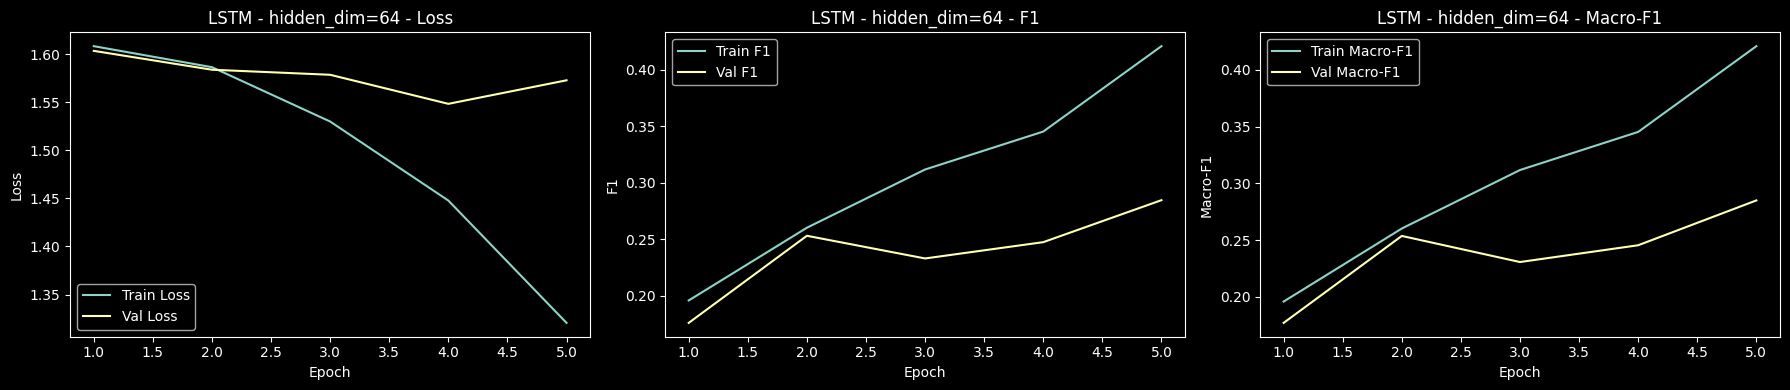

In [58]:
plot_learning_curves(lstm_hidden64_history, title="LSTM - hidden_dim=64")

#### Đánh giá tập test

In [59]:
lstm_hidden64_test_loss, lstm_hidden64_test_metrics, y_true_lstm_hidden64, y_pred_lstm_hidden64 = evaluate(
    lstm_hidden64_model, test_loader, criterion, device
)

print("LSTM (hidden_dim=64) Test Loss:", round(lstm_hidden64_test_loss, 4))
print("LSTM (hidden_dim=64) Test Metrics:", lstm_hidden64_test_metrics)

LSTM (hidden_dim=64) Test Loss: 1.5621
LSTM (hidden_dim=64) Test Metrics: {'accuracy': 0.2678733031674208, 'precision': 0.3168549385379205, 'recall': 0.2678733031674208, 'f1': 0.2570961806130839, 'macro_f1': 0.26526094818097545}


#### Train GRU hidden = 64

In [60]:
gru_hidden64_model = RecurrentClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=64,
    num_layers=1,
    num_classes=5,
    dropout=0.3,
    bidirectional=True,
    rnn_type="gru",
    pooling="mean",
    pad_idx=PAD_IDX
).to(device)

gru_hidden64_optimizer = torch.optim.Adam(gru_hidden64_model.parameters(), lr=1e-3)

gru_hidden64_model, gru_hidden64_history = train_model(
    gru_hidden64_model,
    train_loader,
    val_loader,
    gru_hidden64_optimizer,
    criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.6066 | Acc: 0.2124 | Prec: 0.2136 | Recall: 0.2124 | F1: 0.2111 | Macro-F1: 0.2111
Val   Loss: 1.5990 | Acc: 0.2490 | Prec: 0.2628 | Recall: 0.2490 | F1: 0.2160 | Macro-F1: 0.2173

Epoch 2/5


Train Loss: 1.5764 | Acc: 0.2992 | Prec: 0.3025 | Recall: 0.2992 | F1: 0.2848 | Macro-F1: 0.2848
Val   Loss: 1.5748 | Acc: 0.2693 | Prec: 0.2872 | Recall: 0.2693 | F1: 0.2302 | Macro-F1: 0.2289

Epoch 3/5


Train Loss: 1.5074 | Acc: 0.3360 | Prec: 0.3311 | Recall: 0.3360 | F1: 0.3123 | Macro-F1: 0.3123
Val   Loss: 1.5335 | Acc: 0.2747 | Prec: 0.2725 | Recall: 0.2747 | F1: 0.2611 | Macro-F1: 0.2621

Epoch 4/5


Train Loss: 1.3715 | Acc: 0.4316 | Prec: 0.4330 | Recall: 0.4316 | F1: 0.4161 | Macro-F1: 0.4161
Val   Loss: 1.5447 | Acc: 0.2828 | Prec: 0.2826 | Recall: 0.2828 | F1: 0.2454 | Macro-F1: 0.2474

Epoch 5/5


Train Loss: 1.2268 | Acc: 0.4804 | Prec: 0.4734 | Recall: 0.4804 | F1: 0.4666 | Macro-F1: 0.4666
Val   Loss: 1.5689 | Acc: 0.2963 | Prec: 0.2721 | Recall: 0.2963 | F1: 0.2682 | Macro-F1: 0.2681


#### Learning curve

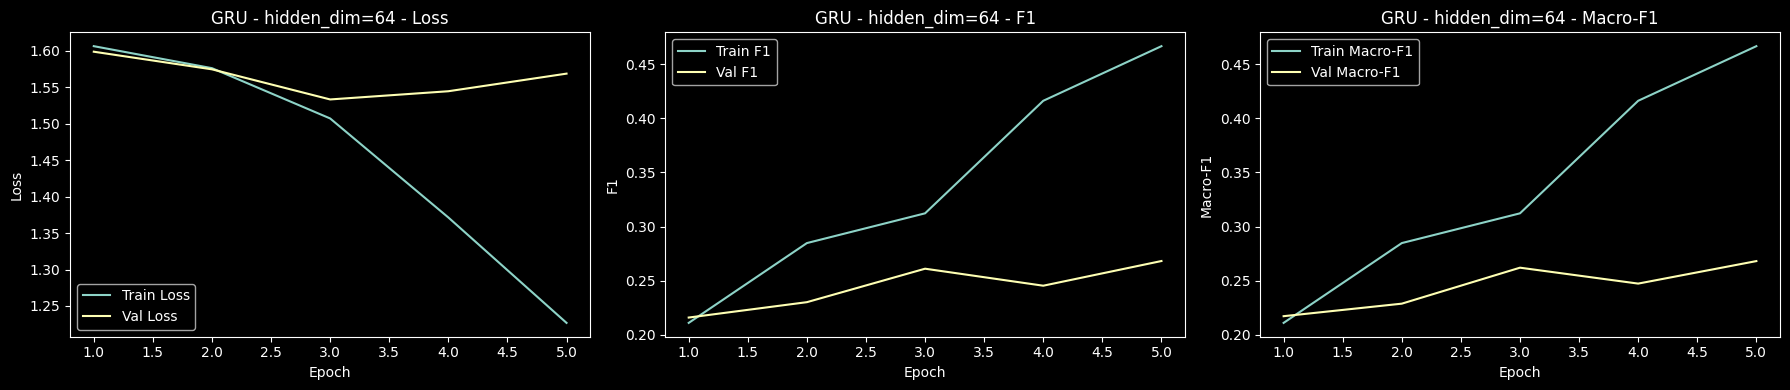

In [61]:
plot_learning_curves(gru_hidden64_history, title="GRU - hidden_dim=64")

#### Đánh giá tập test

In [62]:
gru_hidden64_test_loss, gru_hidden64_test_metrics, y_true_gru_hidden64, y_pred_gru_hidden64 = evaluate(
    gru_hidden64_model, test_loader, criterion, device
)

print("GRU (hidden_dim=64) Test Loss:", round(gru_hidden64_test_loss, 4))
print("GRU (hidden_dim=64) Test Metrics:", gru_hidden64_test_metrics)

GRU (hidden_dim=64) Test Loss: 1.5303
GRU (hidden_dim=64) Test Metrics: {'accuracy': 0.28868778280542984, 'precision': 0.31555744557488874, 'recall': 0.28868778280542984, 'f1': 0.2646156512841819, 'macro_f1': 0.2796853508121292}


#### Train LSTM hidden = 256

In [63]:
lstm_hidden256_model = RecurrentClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=256,
    num_layers=1,
    num_classes=5,
    dropout=0.3,
    bidirectional=True,
    rnn_type="lstm",
    pooling="mean",
    pad_idx=PAD_IDX
).to(device)

lstm_hidden256_optimizer = torch.optim.Adam(lstm_hidden256_model.parameters(), lr=1e-3)

lstm_hidden256_model, lstm_hidden256_history = train_model(
    lstm_hidden256_model,
    train_loader,
    val_loader,
    lstm_hidden256_optimizer,
    criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.6037 | Acc: 0.2352 | Prec: 0.2227 | Recall: 0.2352 | F1: 0.2215 | Macro-F1: 0.2215
Val   Loss: 1.5921 | Acc: 0.2788 | Prec: 0.2885 | Recall: 0.2788 | F1: 0.2497 | Macro-F1: 0.2504

Epoch 2/5


Train Loss: 1.5577 | Acc: 0.3192 | Prec: 0.3312 | Recall: 0.3192 | F1: 0.2922 | Macro-F1: 0.2922
Val   Loss: 1.5828 | Acc: 0.2585 | Prec: 0.2716 | Recall: 0.2585 | F1: 0.2373 | Macro-F1: 0.2350

Epoch 3/5


Train Loss: 1.4637 | Acc: 0.3592 | Prec: 0.3520 | Recall: 0.3592 | F1: 0.3398 | Macro-F1: 0.3398
Val   Loss: 1.5552 | Acc: 0.3031 | Prec: 0.3378 | Recall: 0.3031 | F1: 0.2961 | Macro-F1: 0.2962

Epoch 4/5


Train Loss: 1.3331 | Acc: 0.4336 | Prec: 0.4353 | Recall: 0.4336 | F1: 0.4270 | Macro-F1: 0.4270
Val   Loss: 1.6030 | Acc: 0.3085 | Prec: 0.3148 | Recall: 0.3085 | F1: 0.2980 | Macro-F1: 0.2987

Epoch 5/5


Train Loss: 1.1853 | Acc: 0.5108 | Prec: 0.5124 | Recall: 0.5108 | F1: 0.5046 | Macro-F1: 0.5046
Val   Loss: 1.5797 | Acc: 0.2991 | Prec: 0.3302 | Recall: 0.2991 | F1: 0.2813 | Macro-F1: 0.2814


#### Learning curve

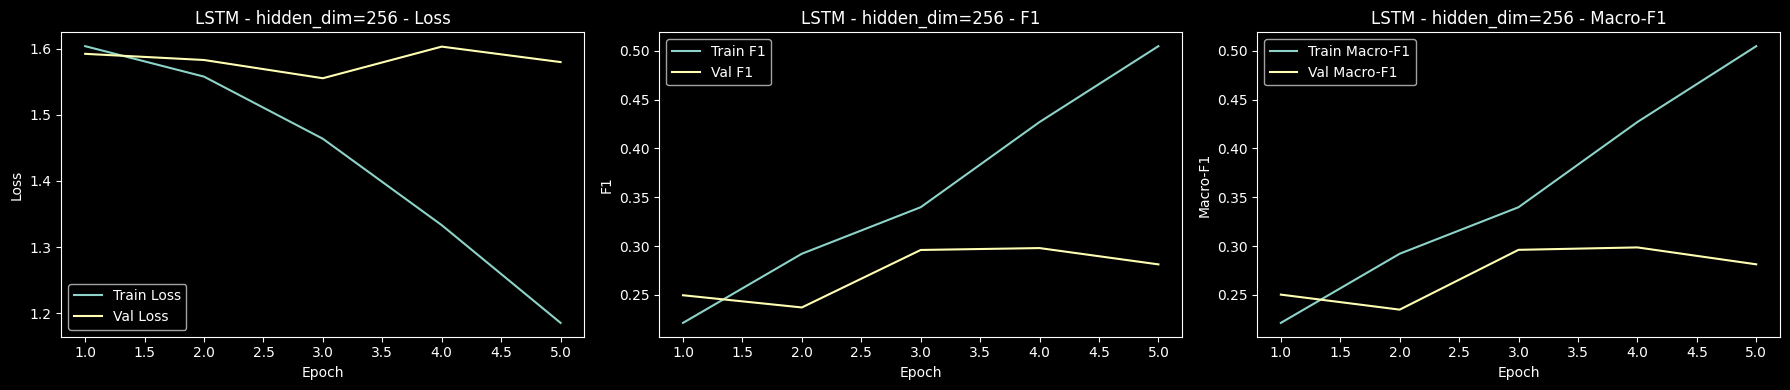

In [64]:
plot_learning_curves(lstm_hidden256_history, title="LSTM - hidden_dim=256")

#### Đánh giá tập test

In [65]:
lstm_hidden256_test_loss, lstm_hidden256_test_metrics, y_true_lstm_hidden256, y_pred_lstm_hidden256 = evaluate(
    lstm_hidden256_model, test_loader, criterion, device
)

print("LSTM (hidden_dim=256) Test Loss:", round(lstm_hidden256_test_loss, 4))
print("LSTM (hidden_dim=256) Test Metrics:", lstm_hidden256_test_metrics)

LSTM (hidden_dim=256) Test Loss: 1.5718
LSTM (hidden_dim=256) Test Metrics: {'accuracy': 0.285972850678733, 'precision': 0.3262512428952233, 'recall': 0.285972850678733, 'f1': 0.2704607826225502, 'macro_f1': 0.27690392833863153}


#### Train GRU hidden = 256

In [66]:
gru_hidden256_model = RecurrentClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=256,
    num_layers=1,
    num_classes=5,
    dropout=0.3,
    bidirectional=True,
    rnn_type="gru",
    pooling="mean",
    pad_idx=PAD_IDX
).to(device)

gru_hidden256_optimizer = torch.optim.Adam(gru_hidden256_model.parameters(), lr=1e-3)

gru_hidden256_model, gru_hidden256_history = train_model(
    gru_hidden256_model,
    train_loader,
    val_loader,
    gru_hidden256_optimizer,
    criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.5961 | Acc: 0.2328 | Prec: 0.2311 | Recall: 0.2328 | F1: 0.2257 | Macro-F1: 0.2257
Val   Loss: 1.5857 | Acc: 0.2612 | Prec: 0.2015 | Recall: 0.2612 | F1: 0.1994 | Macro-F1: 0.1995

Epoch 2/5


Train Loss: 1.5268 | Acc: 0.3360 | Prec: 0.3318 | Recall: 0.3360 | F1: 0.3110 | Macro-F1: 0.3110
Val   Loss: 1.5493 | Acc: 0.3045 | Prec: 0.3077 | Recall: 0.3045 | F1: 0.2966 | Macro-F1: 0.2969

Epoch 3/5


Train Loss: 1.3994 | Acc: 0.4068 | Prec: 0.4027 | Recall: 0.4068 | F1: 0.3987 | Macro-F1: 0.3987
Val   Loss: 1.5205 | Acc: 0.3248 | Prec: 0.3342 | Recall: 0.3248 | F1: 0.2990 | Macro-F1: 0.2990

Epoch 4/5


Train Loss: 1.2469 | Acc: 0.4700 | Prec: 0.4724 | Recall: 0.4700 | F1: 0.4664 | Macro-F1: 0.4664
Val   Loss: 1.5779 | Acc: 0.3139 | Prec: 0.3033 | Recall: 0.3139 | F1: 0.2960 | Macro-F1: 0.2974

Epoch 5/5


Train Loss: 1.0393 | Acc: 0.5776 | Prec: 0.5796 | Recall: 0.5776 | F1: 0.5742 | Macro-F1: 0.5742
Val   Loss: 1.6220 | Acc: 0.3221 | Prec: 0.3335 | Recall: 0.3221 | F1: 0.3205 | Macro-F1: 0.3209


#### Learning curve

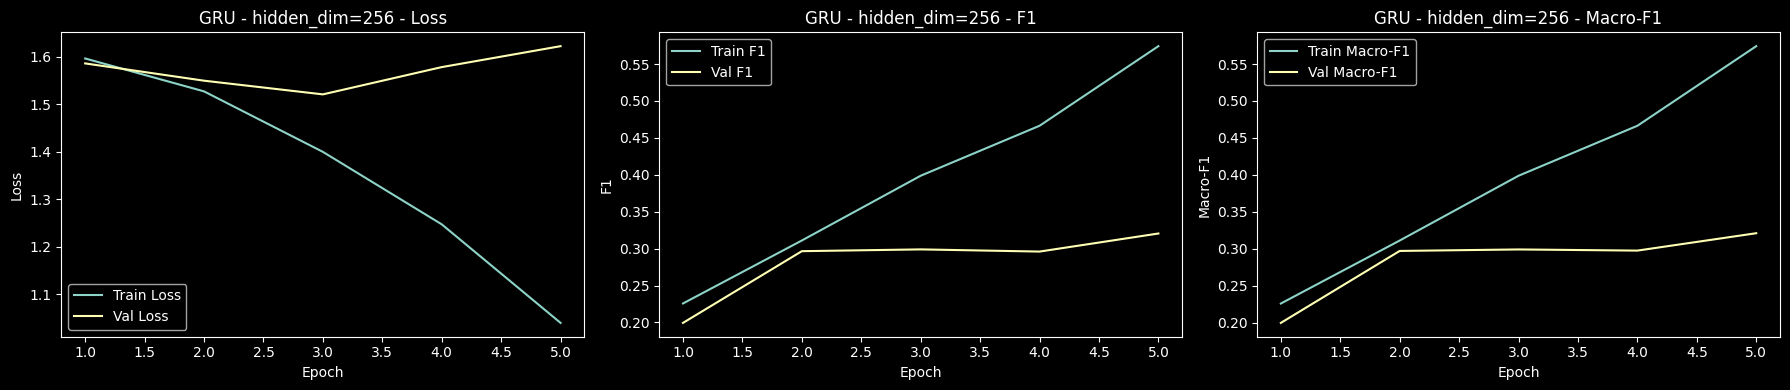

In [67]:
plot_learning_curves(gru_hidden256_history, title="GRU - hidden_dim=256")

#### Đánh giá tập test

In [68]:
gru_hidden256_test_loss, gru_hidden256_test_metrics, y_true_gru_hidden256, y_pred_gru_hidden256 = evaluate(
    gru_hidden256_model, test_loader, criterion, device
)

print("GRU (hidden_dim=256) Test Loss:", round(gru_hidden256_test_loss, 4))
print("GRU (hidden_dim=256) Test Metrics:", gru_hidden256_test_metrics)

GRU (hidden_dim=256) Test Loss: 1.6732
GRU (hidden_dim=256) Test Metrics: {'accuracy': 0.2904977375565611, 'precision': 0.310743127959937, 'recall': 0.2904977375565611, 'f1': 0.28756330185208234, 'macro_f1': 0.28978866296313366}


#### So sánh giữa LSTM và GRU

In [69]:
hidden_compare_df = pd.DataFrame([
    {
        "model": "LSTM",
        "hidden_dim": 64,
        "accuracy": lstm_hidden64_test_metrics["accuracy"],
        "precision": lstm_hidden64_test_metrics["precision"],
        "recall": lstm_hidden64_test_metrics["recall"],
        "f1": lstm_hidden64_test_metrics["f1"],
        "macro_f1": lstm_hidden64_test_metrics["macro_f1"]
    },
    {
        "model": "LSTM",
        "hidden_dim": 128,
        "accuracy": lstm_test_metrics["accuracy"],
        "precision": lstm_test_metrics["precision"],
        "recall": lstm_test_metrics["recall"],
        "f1": lstm_test_metrics["f1"],
        "macro_f1": lstm_test_metrics["macro_f1"]
    },
    {
        "model": "LSTM",
        "hidden_dim": 256,
        "accuracy": lstm_hidden256_test_metrics["accuracy"],
        "precision": lstm_hidden256_test_metrics["precision"],
        "recall": lstm_hidden256_test_metrics["recall"],
        "f1": lstm_hidden256_test_metrics["f1"],
        "macro_f1": lstm_hidden256_test_metrics["macro_f1"]
    },
    {
        "model": "GRU",
        "hidden_dim": 64,
        "accuracy": gru_hidden64_test_metrics["accuracy"],
        "precision": gru_hidden64_test_metrics["precision"],
        "recall": gru_hidden64_test_metrics["recall"],
        "f1": gru_hidden64_test_metrics["f1"],
        "macro_f1": gru_hidden64_test_metrics["macro_f1"]
    },
    {
        "model": "GRU",
        "hidden_dim": 128,
        "accuracy": gru_test_metrics["accuracy"],
        "precision": gru_test_metrics["precision"],
        "recall": gru_test_metrics["recall"],
        "f1": gru_test_metrics["f1"],
        "macro_f1": gru_test_metrics["macro_f1"]
    },
    {
        "model": "GRU",
        "hidden_dim": 256,
        "accuracy": gru_hidden256_test_metrics["accuracy"],
        "precision": gru_hidden256_test_metrics["precision"],
        "recall": gru_hidden256_test_metrics["recall"],
        "f1": gru_hidden256_test_metrics["f1"],
        "macro_f1": gru_hidden256_test_metrics["macro_f1"]
    }
])

hidden_compare_df.sort_values(by=["model", "hidden_dim"]).reset_index(drop=True)

,model,hidden_dim,accuracy,precision,recall,f1,macro_f1
0,GRU,64,0.288688,0.315557,0.288688,0.264616,0.279685
1,GRU,128,0.278281,0.316050,0.278281,0.259853,0.273286
2,GRU,256,0.290498,0.310743,0.290498,0.287563,0.289789
3,LSTM,64,0.267873,0.316855,0.267873,0.257096,0.265261
4,LSTM,128,0.319910,0.341730,0.319910,0.321242,0.322880
5,LSTM,256,0.285973,0.326251,0.285973,0.270461,0.276904


### 5. Ảnh hưởng của output representation


#### Train LSTM với pooling = last

In [70]:
lstm_last_model = RecurrentClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=128,
    num_layers=1,
    num_classes=5,
    dropout=0.3,
    bidirectional=True,
    rnn_type="lstm",
    pooling="last",
    pad_idx=PAD_IDX
).to(device)

lstm_last_optimizer = torch.optim.Adam(lstm_last_model.parameters(), lr=1e-3)

lstm_last_model, lstm_last_history = train_model(
    lstm_last_model,
    train_loader,
    val_loader,
    lstm_last_optimizer,
    criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.6116 | Acc: 0.1940 | Prec: 0.1900 | Recall: 0.1940 | F1: 0.1610 | Macro-F1: 0.1610
Val   Loss: 1.6102 | Acc: 0.2030 | Prec: 0.0412 | Recall: 0.2030 | F1: 0.0685 | Macro-F1: 0.0675

Epoch 2/5


Train Loss: 1.6093 | Acc: 0.1880 | Prec: 0.1918 | Recall: 0.1880 | F1: 0.1456 | Macro-F1: 0.1456
Val   Loss: 1.6102 | Acc: 0.2030 | Prec: 0.0413 | Recall: 0.2030 | F1: 0.0686 | Macro-F1: 0.0676

Epoch 3/5


Train Loss: 1.6085 | Acc: 0.2080 | Prec: 0.2370 | Recall: 0.2080 | F1: 0.1397 | Macro-F1: 0.1397
Val   Loss: 1.6103 | Acc: 0.2003 | Prec: 0.0595 | Recall: 0.2003 | F1: 0.0706 | Macro-F1: 0.0695

Epoch 4/5


Train Loss: 1.6088 | Acc: 0.1952 | Prec: 0.2361 | Recall: 0.1952 | F1: 0.1471 | Macro-F1: 0.1471
Val   Loss: 1.6117 | Acc: 0.2043 | Prec: 0.0829 | Recall: 0.2043 | F1: 0.1025 | Macro-F1: 0.1010

Epoch 5/5


Train Loss: 1.6048 | Acc: 0.2104 | Prec: 0.2314 | Recall: 0.2104 | F1: 0.1405 | Macro-F1: 0.1405
Val   Loss: 1.6137 | Acc: 0.2070 | Prec: 0.1709 | Recall: 0.2070 | F1: 0.1232 | Macro-F1: 0.1216


#### Learning curve

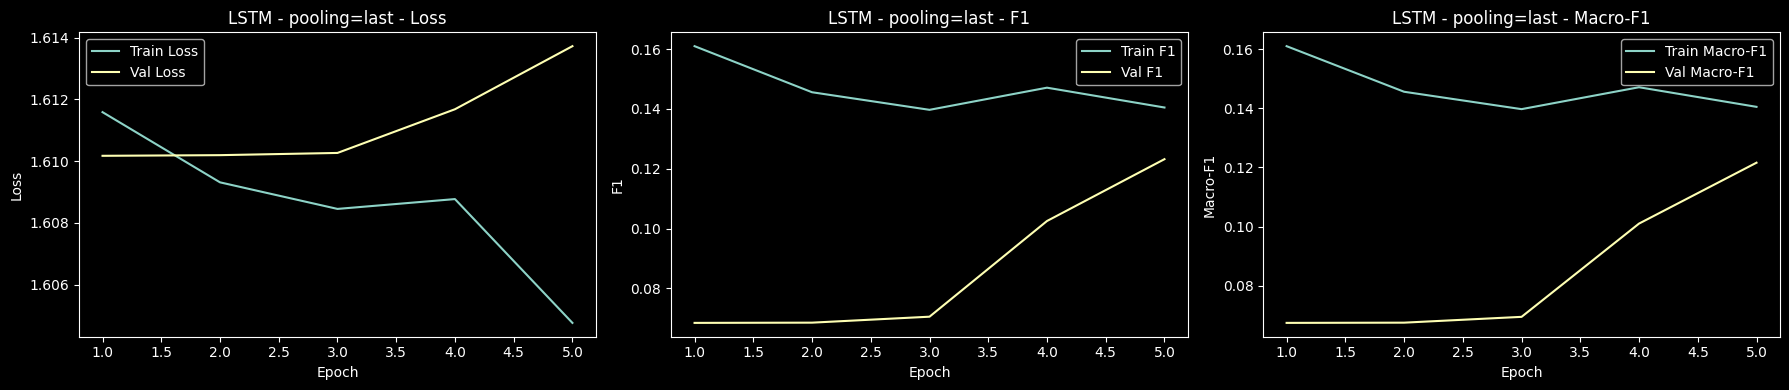

In [71]:
plot_learning_curves(lstm_last_history, title="LSTM - pooling=last")

#### Đánh giá tập test

In [72]:
lstm_last_test_loss, lstm_last_test_metrics, y_true_lstm_last, y_pred_lstm_last = evaluate(
    lstm_last_model, test_loader, criterion, device
)

print("LSTM (pooling=last) Test Loss:", round(lstm_last_test_loss, 4))
print("LSTM (pooling=last) Test Metrics:", lstm_last_test_metrics)

LSTM (pooling=last) Test Loss: 1.6115
LSTM (pooling=last) Test Metrics: {'accuracy': 0.19638009049773755, 'precision': 0.18678481609341857, 'recall': 0.19638009049773755, 'f1': 0.12842956638949726, 'macro_f1': 0.12203376558824519}


#### Train LSTM với pooling = max

In [73]:
lstm_max_model = RecurrentClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=128,
    num_layers=1,
    num_classes=5,
    dropout=0.3,
    bidirectional=True,
    rnn_type="lstm",
    pooling="max",
    pad_idx=PAD_IDX
).to(device)

lstm_max_optimizer = torch.optim.Adam(lstm_max_model.parameters(), lr=1e-3)

lstm_max_model, lstm_max_history = train_model(
    lstm_max_model,
    train_loader,
    val_loader,
    lstm_max_optimizer,
    criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.6042 | Acc: 0.2264 | Prec: 0.2273 | Recall: 0.2264 | F1: 0.2267 | Macro-F1: 0.2267
Val   Loss: 1.5764 | Acc: 0.2923 | Prec: 0.3277 | Recall: 0.2923 | F1: 0.2460 | Macro-F1: 0.2444

Epoch 2/5


Train Loss: 1.5232 | Acc: 0.3452 | Prec: 0.3433 | Recall: 0.3452 | F1: 0.3412 | Macro-F1: 0.3412
Val   Loss: 1.5552 | Acc: 0.2842 | Prec: 0.2648 | Recall: 0.2842 | F1: 0.2365 | Macro-F1: 0.2368

Epoch 3/5


Train Loss: 1.4335 | Acc: 0.4156 | Prec: 0.4157 | Recall: 0.4156 | F1: 0.4089 | Macro-F1: 0.4089
Val   Loss: 1.5206 | Acc: 0.2842 | Prec: 0.3005 | Recall: 0.2842 | F1: 0.2596 | Macro-F1: 0.2606

Epoch 4/5


Train Loss: 1.2881 | Acc: 0.5148 | Prec: 0.5133 | Recall: 0.5148 | F1: 0.5100 | Macro-F1: 0.5100
Val   Loss: 1.4934 | Acc: 0.3126 | Prec: 0.3437 | Recall: 0.3126 | F1: 0.2951 | Macro-F1: 0.2959

Epoch 5/5


Train Loss: 1.1099 | Acc: 0.5932 | Prec: 0.5921 | Recall: 0.5932 | F1: 0.5896 | Macro-F1: 0.5896
Val   Loss: 1.4933 | Acc: 0.3302 | Prec: 0.3543 | Recall: 0.3302 | F1: 0.3258 | Macro-F1: 0.3260


#### Learning curve

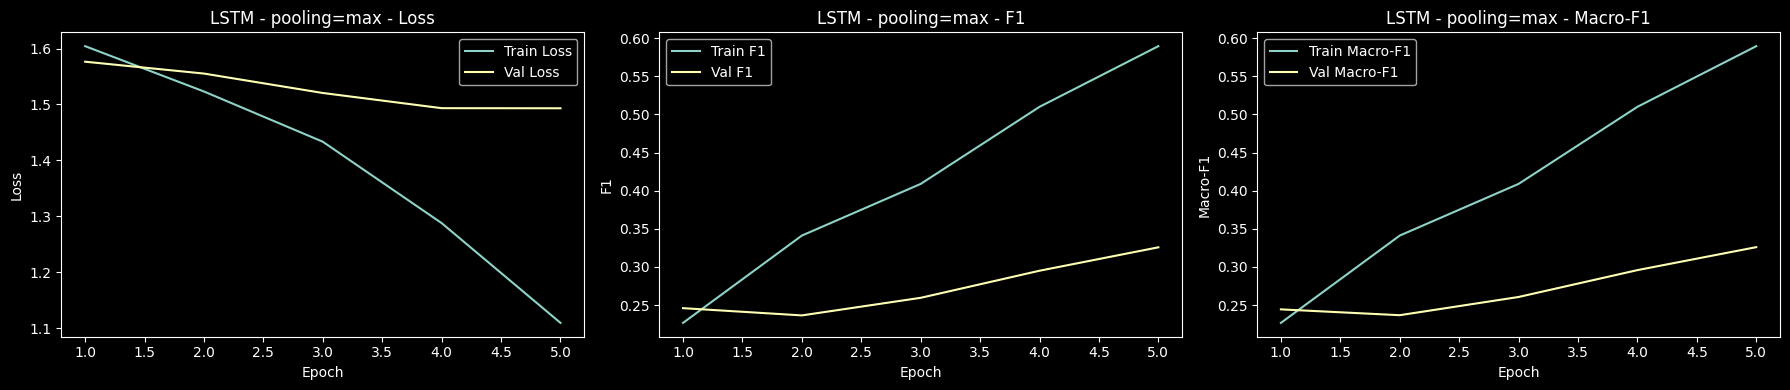

In [74]:
plot_learning_curves(lstm_max_history, title="LSTM - pooling=max")

#### Đánh giá trên tập test

In [75]:
lstm_max_test_loss, lstm_max_test_metrics, y_true_lstm_max, y_pred_lstm_max = evaluate(
    lstm_max_model, test_loader, criterion, device
)

print("LSTM (pooling=max) Test Loss:", round(lstm_max_test_loss, 4))
print("LSTM (pooling=max) Test Metrics:", lstm_max_test_metrics)

LSTM (pooling=max) Test Loss: 1.5151
LSTM (pooling=max) Test Metrics: {'accuracy': 0.32036199095022627, 'precision': 0.35448572871184125, 'recall': 0.32036199095022627, 'f1': 0.3193318688055579, 'macro_f1': 0.30823810536567253}


#### Train LSTM với pooling = attention

In [76]:
lstm_attention_model = RecurrentClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=128,
    num_layers=1,
    num_classes=5,
    dropout=0.3,
    bidirectional=True,
    rnn_type="lstm",
    pooling="attention",
    pad_idx=PAD_IDX
).to(device)

lstm_attention_optimizer = torch.optim.Adam(lstm_attention_model.parameters(), lr=1e-3)

lstm_attention_model, lstm_attention_history = train_model(
    lstm_attention_model,
    train_loader,
    val_loader,
    lstm_attention_optimizer,
    criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.6039 | Acc: 0.2184 | Prec: 0.2195 | Recall: 0.2184 | F1: 0.2097 | Macro-F1: 0.2097
Val   Loss: 1.5940 | Acc: 0.2517 | Prec: 0.2534 | Recall: 0.2517 | F1: 0.2253 | Macro-F1: 0.2261

Epoch 2/5


Train Loss: 1.5590 | Acc: 0.2948 | Prec: 0.2913 | Recall: 0.2948 | F1: 0.2702 | Macro-F1: 0.2702
Val   Loss: 1.6214 | Acc: 0.2314 | Prec: 0.2703 | Recall: 0.2314 | F1: 0.1996 | Macro-F1: 0.2011

Epoch 3/5


Train Loss: 1.4540 | Acc: 0.3772 | Prec: 0.3736 | Recall: 0.3772 | F1: 0.3713 | Macro-F1: 0.3713
Val   Loss: 1.5719 | Acc: 0.2666 | Prec: 0.2777 | Recall: 0.2666 | F1: 0.2367 | Macro-F1: 0.2377

Epoch 4/5


Train Loss: 1.2835 | Acc: 0.4580 | Prec: 0.4523 | Recall: 0.4580 | F1: 0.4473 | Macro-F1: 0.4473
Val   Loss: 1.5287 | Acc: 0.3180 | Prec: 0.3277 | Recall: 0.3180 | F1: 0.3123 | Macro-F1: 0.3130

Epoch 5/5


Train Loss: 1.0413 | Acc: 0.5876 | Prec: 0.5862 | Recall: 0.5876 | F1: 0.5835 | Macro-F1: 0.5835
Val   Loss: 1.6038 | Acc: 0.3194 | Prec: 0.3282 | Recall: 0.3194 | F1: 0.3173 | Macro-F1: 0.3172


#### Learning curve

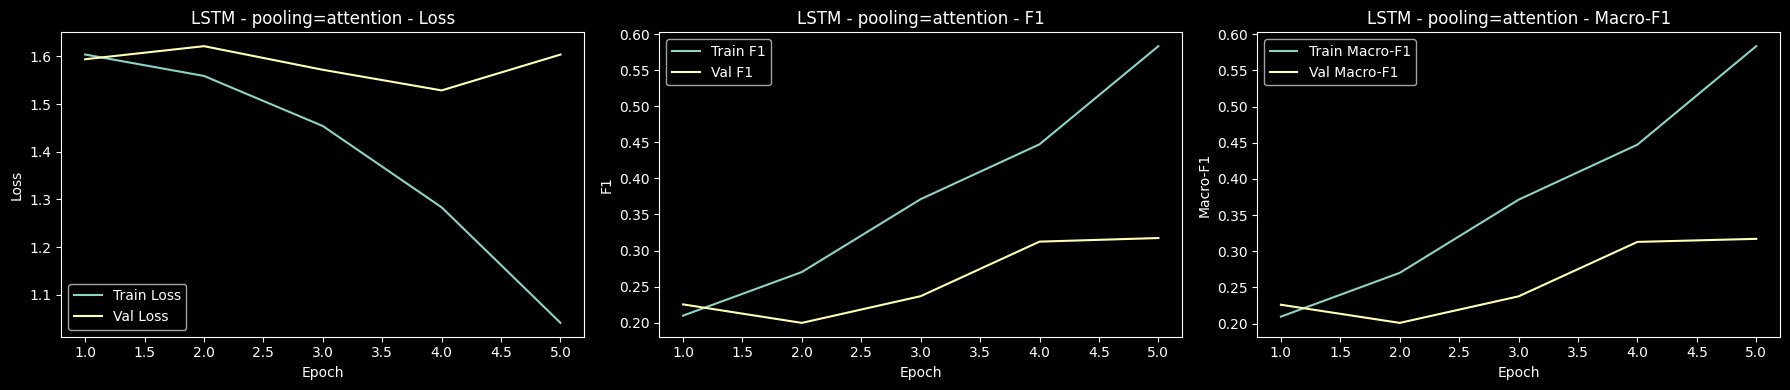

In [77]:
plot_learning_curves(lstm_attention_history, title="LSTM - pooling=attention")

#### Đánh giá trên tập test

In [78]:
lstm_attention_test_loss, lstm_attention_test_metrics, y_true_lstm_attention, y_pred_lstm_attention = evaluate(
    lstm_attention_model, test_loader, criterion, device
)

print("LSTM (pooling=attention) Test Loss:", round(lstm_attention_test_loss, 4))
print("LSTM (pooling=attention) Test Metrics:", lstm_attention_test_metrics)

LSTM (pooling=attention) Test Loss: 1.6554
LSTM (pooling=attention) Test Metrics: {'accuracy': 0.30995475113122173, 'precision': 0.34445123590149224, 'recall': 0.30995475113122173, 'f1': 0.3095379696216581, 'macro_f1': 0.3127222790301394}


#### Train GRU với pooling = last

In [79]:
gru_last_model = RecurrentClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=128,
    num_layers=1,
    num_classes=5,
    dropout=0.3,
    bidirectional=True,
    rnn_type="gru",
    pooling="last",
    pad_idx=PAD_IDX
).to(device)

gru_last_optimizer = torch.optim.Adam(gru_last_model.parameters(), lr=1e-3)

gru_last_model, gru_last_history = train_model(
    gru_last_model,
    train_loader,
    val_loader,
    gru_last_optimizer,
    criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.6119 | Acc: 0.1888 | Prec: 0.1731 | Recall: 0.1888 | F1: 0.1412 | Macro-F1: 0.1412
Val   Loss: 1.6103 | Acc: 0.2003 | Prec: 0.0645 | Recall: 0.2003 | F1: 0.0705 | Macro-F1: 0.0697

Epoch 2/5


Train Loss: 1.6087 | Acc: 0.1940 | Prec: 0.1791 | Recall: 0.1940 | F1: 0.1570 | Macro-F1: 0.1570
Val   Loss: 1.6109 | Acc: 0.2003 | Prec: 0.1152 | Recall: 0.2003 | F1: 0.0836 | Macro-F1: 0.0833

Epoch 3/5


Train Loss: 1.6075 | Acc: 0.1992 | Prec: 0.2015 | Recall: 0.1992 | F1: 0.1672 | Macro-F1: 0.1672
Val   Loss: 1.6110 | Acc: 0.1935 | Prec: 0.1074 | Recall: 0.1935 | F1: 0.0746 | Macro-F1: 0.0782

Epoch 4/5


Train Loss: 1.6070 | Acc: 0.2024 | Prec: 0.1940 | Recall: 0.2024 | F1: 0.1662 | Macro-F1: 0.1662
Val   Loss: 1.6116 | Acc: 0.2016 | Prec: 0.0749 | Recall: 0.2016 | F1: 0.0731 | Macro-F1: 0.0721

Epoch 5/5


Train Loss: 1.6049 | Acc: 0.1948 | Prec: 0.2233 | Recall: 0.1948 | F1: 0.1570 | Macro-F1: 0.1570
Val   Loss: 1.6128 | Acc: 0.1854 | Prec: 0.1030 | Recall: 0.1854 | F1: 0.0668 | Macro-F1: 0.0705


#### Learning curve

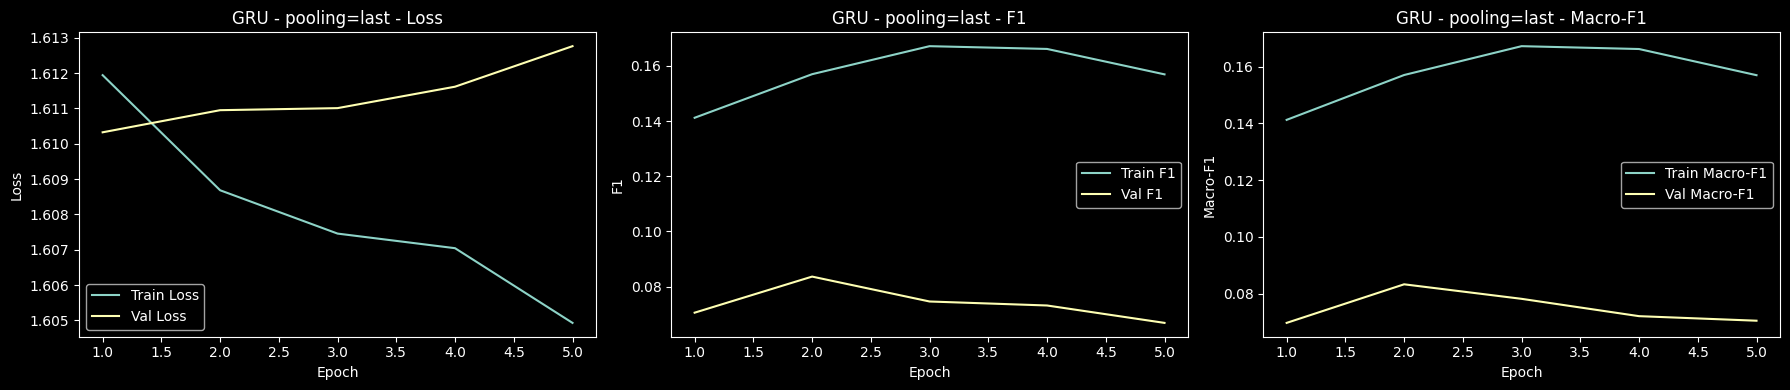

In [80]:
plot_learning_curves(gru_last_history, title="GRU - pooling=last")

#### Đánh giá tập test

In [81]:
gru_last_test_loss, gru_last_test_metrics, y_true_gru_last, y_pred_gru_last = evaluate(
    gru_last_model, test_loader, criterion, device
)

print("GRU (pooling=last) Test Loss:", round(gru_last_test_loss, 4))
print("GRU (pooling=last) Test Metrics:", gru_last_test_metrics)

GRU (pooling=last) Test Loss: 1.6125
GRU (pooling=last) Test Metrics: {'accuracy': 0.12805429864253393, 'precision': 0.17383448705462048, 'recall': 0.12805429864253393, 'f1': 0.04031373821850834, 'macro_f1': 0.055447464898303746}


#### Train GRU với pooling = max

In [82]:
gru_max_model = RecurrentClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=128,
    num_layers=1,
    num_classes=5,
    dropout=0.3,
    bidirectional=True,
    rnn_type="gru",
    pooling="max",
    pad_idx=PAD_IDX
).to(device)

gru_max_optimizer = torch.optim.Adam(gru_max_model.parameters(), lr=1e-3)

gru_max_model, gru_max_history = train_model(
    gru_max_model,
    train_loader,
    val_loader,
    gru_max_optimizer,
    criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.6101 | Acc: 0.2244 | Prec: 0.2230 | Recall: 0.2244 | F1: 0.2230 | Macro-F1: 0.2230
Val   Loss: 1.5942 | Acc: 0.2368 | Prec: 0.3057 | Recall: 0.2368 | F1: 0.1759 | Macro-F1: 0.1733

Epoch 2/5


Train Loss: 1.5184 | Acc: 0.3424 | Prec: 0.3416 | Recall: 0.3424 | F1: 0.3413 | Macro-F1: 0.3413
Val   Loss: 1.5417 | Acc: 0.2977 | Prec: 0.2484 | Recall: 0.2977 | F1: 0.2570 | Macro-F1: 0.2576

Epoch 3/5


Train Loss: 1.4151 | Acc: 0.4200 | Prec: 0.4178 | Recall: 0.4200 | F1: 0.4159 | Macro-F1: 0.4159
Val   Loss: 1.5111 | Acc: 0.3315 | Prec: 0.3181 | Recall: 0.3315 | F1: 0.3014 | Macro-F1: 0.3016

Epoch 4/5


Train Loss: 1.2831 | Acc: 0.5032 | Prec: 0.5019 | Recall: 0.5032 | F1: 0.5005 | Macro-F1: 0.5005
Val   Loss: 1.5059 | Acc: 0.3085 | Prec: 0.2956 | Recall: 0.3085 | F1: 0.2829 | Macro-F1: 0.2841

Epoch 5/5


Train Loss: 1.1291 | Acc: 0.6056 | Prec: 0.6056 | Recall: 0.6056 | F1: 0.6027 | Macro-F1: 0.6027
Val   Loss: 1.5396 | Acc: 0.2896 | Prec: 0.3153 | Recall: 0.2896 | F1: 0.2731 | Macro-F1: 0.2718


#### Learning curve

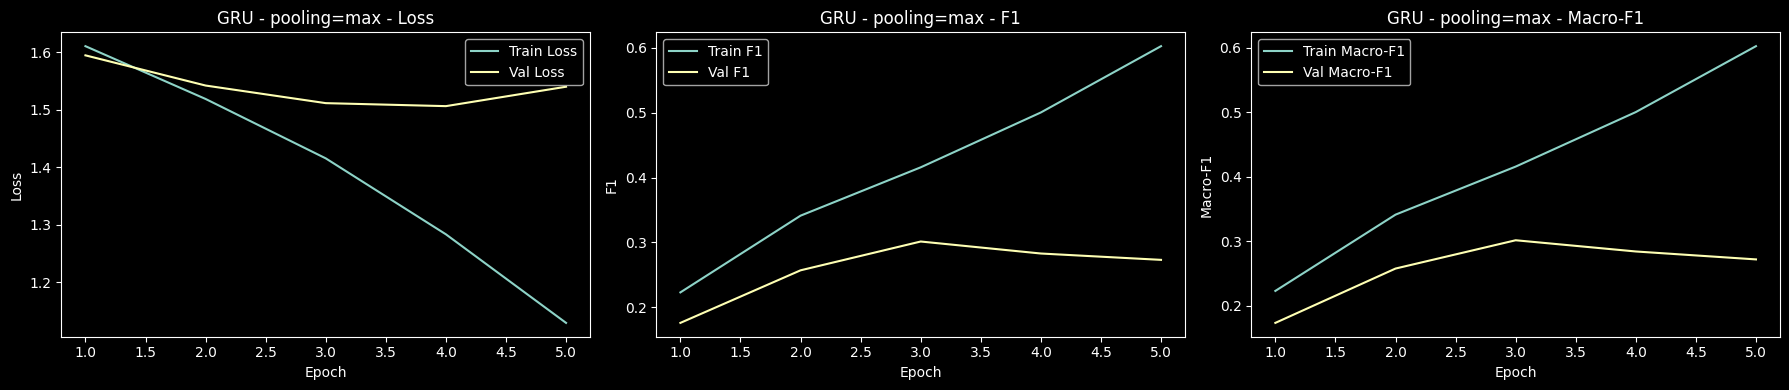

In [83]:
plot_learning_curves(gru_max_history, title="GRU - pooling=max")

#### Đánh giá tập test

In [84]:
gru_max_test_loss, gru_max_test_metrics, y_true_gru_max, y_pred_gru_max = evaluate(
    gru_max_model, test_loader, criterion, device
)

print("GRU (pooling=max) Test Loss:", round(gru_max_test_loss, 4))
print("GRU (pooling=max) Test Metrics:", gru_max_test_metrics)

GRU (pooling=max) Test Loss: 1.5253
GRU (pooling=max) Test Metrics: {'accuracy': 0.2995475113122172, 'precision': 0.3346139949973309, 'recall': 0.2995475113122172, 'f1': 0.2904670937264746, 'macro_f1': 0.28050574033140097}


#### Train GRU với pooling = attention

In [85]:
gru_attention_model = RecurrentClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=128,
    num_layers=1,
    num_classes=5,
    dropout=0.3,
    bidirectional=True,
    rnn_type="gru",
    pooling="attention",
    pad_idx=PAD_IDX
).to(device)

gru_attention_optimizer = torch.optim.Adam(gru_attention_model.parameters(), lr=1e-3)

gru_attention_model, gru_attention_history = train_model(
    gru_attention_model,
    train_loader,
    val_loader,
    gru_attention_optimizer,
    criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.6014 | Acc: 0.2440 | Prec: 0.2461 | Recall: 0.2440 | F1: 0.2300 | Macro-F1: 0.2300
Val   Loss: 1.5787 | Acc: 0.2639 | Prec: 0.2770 | Recall: 0.2639 | F1: 0.2460 | Macro-F1: 0.2467

Epoch 2/5


Train Loss: 1.5327 | Acc: 0.3208 | Prec: 0.3136 | Recall: 0.3208 | F1: 0.2979 | Macro-F1: 0.2979
Val   Loss: 1.5173 | Acc: 0.3261 | Prec: 0.3034 | Recall: 0.3261 | F1: 0.3038 | Macro-F1: 0.3050

Epoch 3/5


Train Loss: 1.3970 | Acc: 0.3916 | Prec: 0.3836 | Recall: 0.3916 | F1: 0.3812 | Macro-F1: 0.3812
Val   Loss: 1.5029 | Acc: 0.3248 | Prec: 0.3303 | Recall: 0.3248 | F1: 0.3114 | Macro-F1: 0.3111

Epoch 4/5


Train Loss: 1.1819 | Acc: 0.5052 | Prec: 0.5029 | Recall: 0.5052 | F1: 0.4998 | Macro-F1: 0.4998
Val   Loss: 1.5097 | Acc: 0.3532 | Prec: 0.3534 | Recall: 0.3532 | F1: 0.3391 | Macro-F1: 0.3398

Epoch 5/5


Train Loss: 0.9356 | Acc: 0.6500 | Prec: 0.6501 | Recall: 0.6500 | F1: 0.6489 | Macro-F1: 0.6489
Val   Loss: 1.6957 | Acc: 0.3464 | Prec: 0.3380 | Recall: 0.3464 | F1: 0.3364 | Macro-F1: 0.3360


#### Learning curve

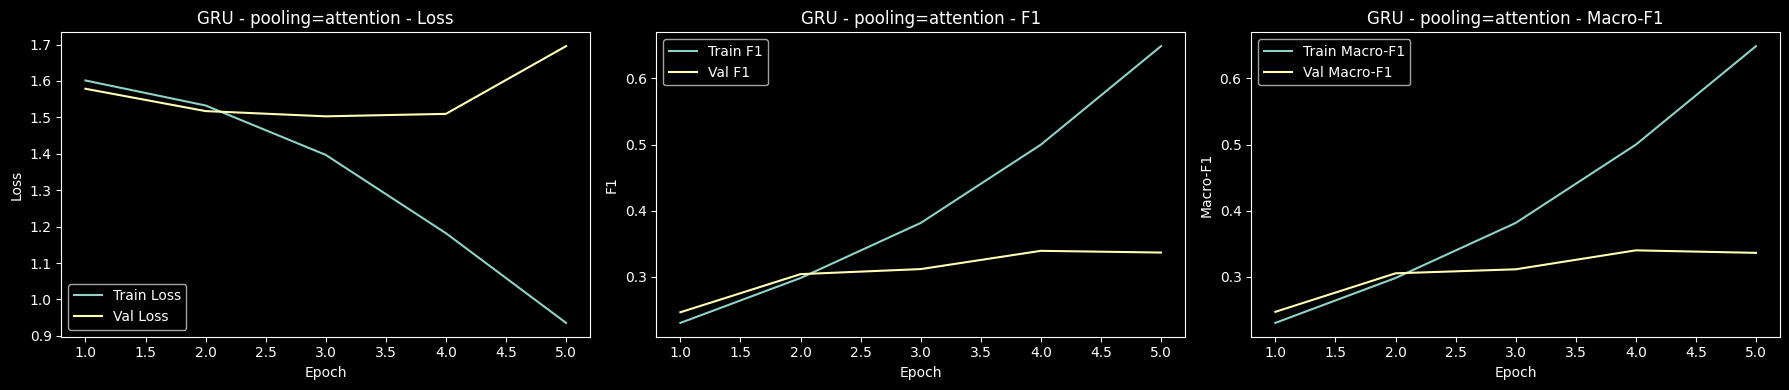

In [86]:
plot_learning_curves(gru_attention_history, title="GRU - pooling=attention")

#### Đánh giá tập test

In [87]:
gru_attention_test_loss, gru_attention_test_metrics, y_true_gru_attention, y_pred_gru_attention = evaluate(
    gru_attention_model, test_loader, criterion, device
)

print("GRU (pooling=attention) Test Loss:", round(gru_attention_test_loss, 4))
print("GRU (pooling=attention) Test Metrics:", gru_attention_test_metrics)

GRU (pooling=attention) Test Loss: 1.7719
GRU (pooling=attention) Test Metrics: {'accuracy': 0.3081447963800905, 'precision': 0.3164294594836191, 'recall': 0.3081447963800905, 'f1': 0.30136366957687216, 'macro_f1': 0.30484417721196444}


#### So sánh output representation của LSTM và GRU

In [88]:
pooling_compare_df = pd.DataFrame([
    {
        "model": "LSTM",
        "pooling": "last",
        "accuracy": lstm_last_test_metrics["accuracy"],
        "precision": lstm_last_test_metrics["precision"],
        "recall": lstm_last_test_metrics["recall"],
        "f1": lstm_last_test_metrics["f1"],
        "macro_f1": lstm_last_test_metrics["macro_f1"]
    },
    {
        "model": "LSTM",
        "pooling": "mean",
        "accuracy": lstm_test_metrics["accuracy"],
        "precision": lstm_test_metrics["precision"],
        "recall": lstm_test_metrics["recall"],
        "f1": lstm_test_metrics["f1"],
        "macro_f1": lstm_test_metrics["macro_f1"]
    },
    {
        "model": "LSTM",
        "pooling": "max",
        "accuracy": lstm_max_test_metrics["accuracy"],
        "precision": lstm_max_test_metrics["precision"],
        "recall": lstm_max_test_metrics["recall"],
        "f1": lstm_max_test_metrics["f1"],
        "macro_f1": lstm_max_test_metrics["macro_f1"]
    },
    {
        "model": "LSTM",
        "pooling": "attention",
        "accuracy": lstm_attention_test_metrics["accuracy"],
        "precision": lstm_attention_test_metrics["precision"],
        "recall": lstm_attention_test_metrics["recall"],
        "f1": lstm_attention_test_metrics["f1"],
        "macro_f1": lstm_attention_test_metrics["macro_f1"]
    },
    {
        "model": "GRU",
        "pooling": "last",
        "accuracy": gru_last_test_metrics["accuracy"],
        "precision": gru_last_test_metrics["precision"],
        "recall": gru_last_test_metrics["recall"],
        "f1": gru_last_test_metrics["f1"],
        "macro_f1": gru_last_test_metrics["macro_f1"]
    },
    {
        "model": "GRU",
        "pooling": "mean",
        "accuracy": gru_test_metrics["accuracy"],
        "precision": gru_test_metrics["precision"],
        "recall": gru_test_metrics["recall"],
        "f1": gru_test_metrics["f1"],
        "macro_f1": gru_test_metrics["macro_f1"]
    },
    {
        "model": "GRU",
        "pooling": "max",
        "accuracy": gru_max_test_metrics["accuracy"],
        "precision": gru_max_test_metrics["precision"],
        "recall": gru_max_test_metrics["recall"],
        "f1": gru_max_test_metrics["f1"],
        "macro_f1": gru_max_test_metrics["macro_f1"]
    },
    {
        "model": "GRU",
        "pooling": "attention",
        "accuracy": gru_attention_test_metrics["accuracy"],
        "precision": gru_attention_test_metrics["precision"],
        "recall": gru_attention_test_metrics["recall"],
        "f1": gru_attention_test_metrics["f1"],
        "macro_f1": gru_attention_test_metrics["macro_f1"]
    }
])

pooling_compare_df.sort_values(by=["model", "pooling"]).reset_index(drop=True)

,model,pooling,accuracy,precision,recall,f1,macro_f1
0,GRU,attention,0.308145,0.316429,0.308145,0.301364,0.304844
1,GRU,last,0.128054,0.173834,0.128054,0.040314,0.055447
2,GRU,max,0.299548,0.334614,0.299548,0.290467,0.280506
3,GRU,mean,0.278281,0.316050,0.278281,0.259853,0.273286
4,LSTM,attention,0.309955,0.344451,0.309955,0.309538,0.312722
5,LSTM,last,0.196380,0.186785,0.196380,0.128430,0.122034
6,LSTM,max,0.320362,0.354486,0.320362,0.319332,0.308238
7,LSTM,mean,0.319910,0.341730,0.319910,0.321242,0.322880


## PHẦN V. FINE-TUNE CHO MÔ HÌNH PRETRAIN DistilBERT


### 1. Import thư viện, khai báo và xây dựng dataset

In [89]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

In [90]:
DISTILBERT_NAME = "distilbert-base-uncased"

In [91]:
class TransformerTextDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df["text"].tolist()
        self.labels = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }

        return item

In [92]:
#Khoi tao tokenizer va kiem tra
distilbert_tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_NAME)

sample_text = train_small_df.iloc[0]["text"]
encoded_sample = distilbert_tokenizer(
    sample_text,
    max_length=32,
    padding="max_length",
    truncation=True
)

print("Sample text:", sample_text)
print("Input IDs:", encoded_sample["input_ids"])
print("Attention mask:", encoded_sample["attention_mask"])

Sample text: a dark , dull thriller with a parting shot that misfires .
Input IDs: [101, 1037, 2601, 1010, 10634, 10874, 2007, 1037, 20254, 2915, 2008, 28616, 26332, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [93]:
#Tao dataloader
TRANSFORMER_MAX_LEN = 128
TRANSFORMER_BATCH_SIZE = 8

distilbert_train_dataset = TransformerTextDataset(
    train_small_df, distilbert_tokenizer, max_len=TRANSFORMER_MAX_LEN
)
distilbert_val_dataset = TransformerTextDataset(
    val_small_df, distilbert_tokenizer, max_len=TRANSFORMER_MAX_LEN
)
distilbert_test_dataset = TransformerTextDataset(
    test_df, distilbert_tokenizer, max_len=TRANSFORMER_MAX_LEN
)

distilbert_train_loader = DataLoader(
    distilbert_train_dataset, batch_size=TRANSFORMER_BATCH_SIZE, shuffle=True
)
distilbert_val_loader = DataLoader(
    distilbert_val_dataset, batch_size=TRANSFORMER_BATCH_SIZE, shuffle=False
)
distilbert_test_loader = DataLoader(
    distilbert_test_dataset, batch_size=TRANSFORMER_BATCH_SIZE, shuffle=False
)

In [94]:
#Kiem tra 1 batch data
batch = next(iter(distilbert_train_loader))
print("input_ids shape     :", batch["input_ids"].shape)
print("attention_mask shape:", batch["attention_mask"].shape)
print("label shape         :", batch["label"].shape)

input_ids shape     : torch.Size([8, 128])
attention_mask shape: torch.Size([8, 128])
label shape         : torch.Size([8])


### 2. Hàm huấn luyện

In [95]:
#Train 1 epoch cho BERT
def train_one_epoch_transformer(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="Training", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    metrics = compute_metrics(all_labels, all_preds)
    return avg_loss, metrics

In [96]:
#Evaluate cho BERT
def evaluate_transformer(model, loader, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    metrics = compute_metrics(all_labels, all_preds)
    return avg_loss, metrics, all_labels, all_preds

In [97]:
#Huấn luyện nhiều epoch cho BERT
def train_transformer_model(model, train_loader, val_loader, optimizer, scheduler, device, epochs=3):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_precision": [],
        "val_precision": [],
        "train_recall": [],
        "val_recall": [],
        "train_f1": [],
        "val_f1": [],
        "train_macro_f1": [],
        "val_macro_f1": []
    }

    best_val_macro_f1 = -1
    best_state = None

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        train_loss, train_metrics = train_one_epoch_transformer(
            model, train_loader, optimizer, scheduler, device
        )
        val_loss, val_metrics, _, _ = evaluate_transformer(
            model, val_loader, device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        history["train_acc"].append(train_metrics["accuracy"])
        history["val_acc"].append(val_metrics["accuracy"])

        history["train_precision"].append(train_metrics["precision"])
        history["val_precision"].append(val_metrics["precision"])

        history["train_recall"].append(train_metrics["recall"])
        history["val_recall"].append(val_metrics["recall"])

        history["train_f1"].append(train_metrics["f1"])
        history["val_f1"].append(val_metrics["f1"])

        history["train_macro_f1"].append(train_metrics["macro_f1"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])

        print(
            f"Train Loss: {train_loss:.4f} | "
            f"Acc: {train_metrics['accuracy']:.4f} | "
            f"Prec: {train_metrics['precision']:.4f} | "
            f"Recall: {train_metrics['recall']:.4f} | "
            f"F1: {train_metrics['f1']:.4f} | "
            f"Macro-F1: {train_metrics['macro_f1']:.4f}"
        )
        print(
            f"Val   Loss: {val_loss:.4f} | "
            f"Acc: {val_metrics['accuracy']:.4f} | "
            f"Prec: {val_metrics['precision']:.4f} | "
            f"Recall: {val_metrics['recall']:.4f} | "
            f"F1: {val_metrics['f1']:.4f} | "
            f"Macro-F1: {val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_state = model.state_dict()

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

### 3. Baseline Fine-tune
Cấu hình baseline gồm:

- learning rate = 2e-5
- max length = 128
- batch size = 8
- số epoch = 3
- fine-tune toàn bộ mô hình

In [98]:
#Khởi tạo BERT base
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_NAME,
    num_labels=5
).to(device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4297.22it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [99]:
#Optimizer và scheduler
distilbert_epochs = 3
distilbert_lr = 2e-5

distilbert_optimizer = torch.optim.AdamW(distilbert_model.parameters(), lr=distilbert_lr)

distilbert_total_steps = len(distilbert_train_loader) * distilbert_epochs

distilbert_scheduler = get_linear_schedule_with_warmup(
    distilbert_optimizer,
    num_warmup_steps=0,
    num_training_steps=distilbert_total_steps
)

#### Train BERT Baseline

In [100]:
#Train BERT baseline
distilbert_model, distilbert_history = train_transformer_model(
    distilbert_model,
    distilbert_train_loader,
    distilbert_val_loader,
    distilbert_optimizer,
    distilbert_scheduler,
    device,
    epochs=distilbert_epochs
)


Epoch 1/3


Train Loss: 1.3677 | Acc: 0.3836 | Prec: 0.3782 | Recall: 0.3836 | F1: 0.3681 | Macro-F1: 0.3681
Val   Loss: 1.1915 | Acc: 0.4520 | Prec: 0.4333 | Recall: 0.4520 | F1: 0.4336 | Macro-F1: 0.4353

Epoch 2/3


Train Loss: 1.0364 | Acc: 0.5512 | Prec: 0.5442 | Recall: 0.5512 | F1: 0.5461 | Macro-F1: 0.5461
Val   Loss: 1.2389 | Acc: 0.4655 | Prec: 0.4451 | Recall: 0.4655 | F1: 0.4422 | Macro-F1: 0.4442

Epoch 3/3


Train Loss: 0.8326 | Acc: 0.6860 | Prec: 0.6822 | Recall: 0.6860 | F1: 0.6827 | Macro-F1: 0.6827
Val   Loss: 1.1979 | Acc: 0.4641 | Prec: 0.4584 | Recall: 0.4641 | F1: 0.4600 | Macro-F1: 0.4614


#### Learning curve

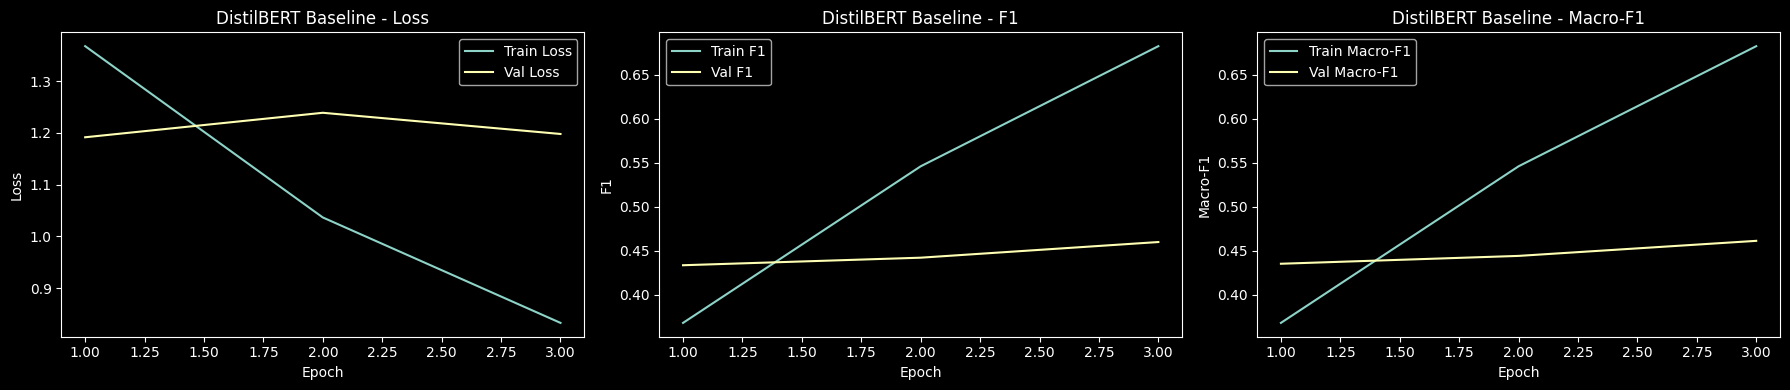

In [101]:
plot_learning_curves(distilbert_history, title="DistilBERT Baseline")

#### Evaluate

In [102]:
distilbert_test_loss, distilbert_test_metrics, y_true_distilbert, y_pred_distilbert = evaluate_transformer(
    distilbert_model,
    distilbert_test_loader,
    device
)

print("DistilBERT Test Loss:", round(distilbert_test_loss, 4))
print("DistilBERT Test Metrics:", distilbert_test_metrics)

DistilBERT Test Loss: 1.1927
DistilBERT Test Metrics: {'accuracy': 0.45520361990950226, 'precision': 0.4738147543170724, 'recall': 0.45520361990950226, 'f1': 0.4547076949396273, 'macro_f1': 0.4582987775790965}


### 4. Ảnh hưởng của learning rate

#### Với learning rate = 1e-5

In [103]:
#Khởi tạo mô hình
distilbert_lr1e5_model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_NAME,
    num_labels=5
).to(device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8869.89it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [104]:
#Optimizer và scheduler
distilbert_lr1e5_epochs = 3
distilbert_lr1e5 = 1e-5

distilbert_lr1e5_optimizer = torch.optim.AdamW(
    distilbert_lr1e5_model.parameters(),
    lr=distilbert_lr1e5
)

distilbert_lr1e5_total_steps = len(distilbert_train_loader) * distilbert_lr1e5_epochs

distilbert_lr1e5_scheduler = get_linear_schedule_with_warmup(
    distilbert_lr1e5_optimizer,
    num_warmup_steps=0,
    num_training_steps=distilbert_lr1e5_total_steps
)

In [105]:
#Train
distilbert_lr1e5_model, distilbert_lr1e5_history = train_transformer_model(
    distilbert_lr1e5_model,
    distilbert_train_loader,
    distilbert_val_loader,
    distilbert_lr1e5_optimizer,
    distilbert_lr1e5_scheduler,
    device,
    epochs=distilbert_lr1e5_epochs
)


Epoch 1/3


Train Loss: 1.4215 | Acc: 0.3644 | Prec: 0.3470 | Recall: 0.3644 | F1: 0.3424 | Macro-F1: 0.3424
Val   Loss: 1.2394 | Acc: 0.4479 | Prec: 0.4288 | Recall: 0.4479 | F1: 0.4275 | Macro-F1: 0.4294

Epoch 2/3


Train Loss: 1.1381 | Acc: 0.5092 | Prec: 0.4949 | Recall: 0.5092 | F1: 0.4928 | Macro-F1: 0.4928
Val   Loss: 1.1897 | Acc: 0.4520 | Prec: 0.4427 | Recall: 0.4520 | F1: 0.4393 | Macro-F1: 0.4414

Epoch 3/3


Train Loss: 0.9986 | Acc: 0.5916 | Prec: 0.5830 | Recall: 0.5916 | F1: 0.5811 | Macro-F1: 0.5811
Val   Loss: 1.1878 | Acc: 0.4520 | Prec: 0.4395 | Recall: 0.4520 | F1: 0.4384 | Macro-F1: 0.4403


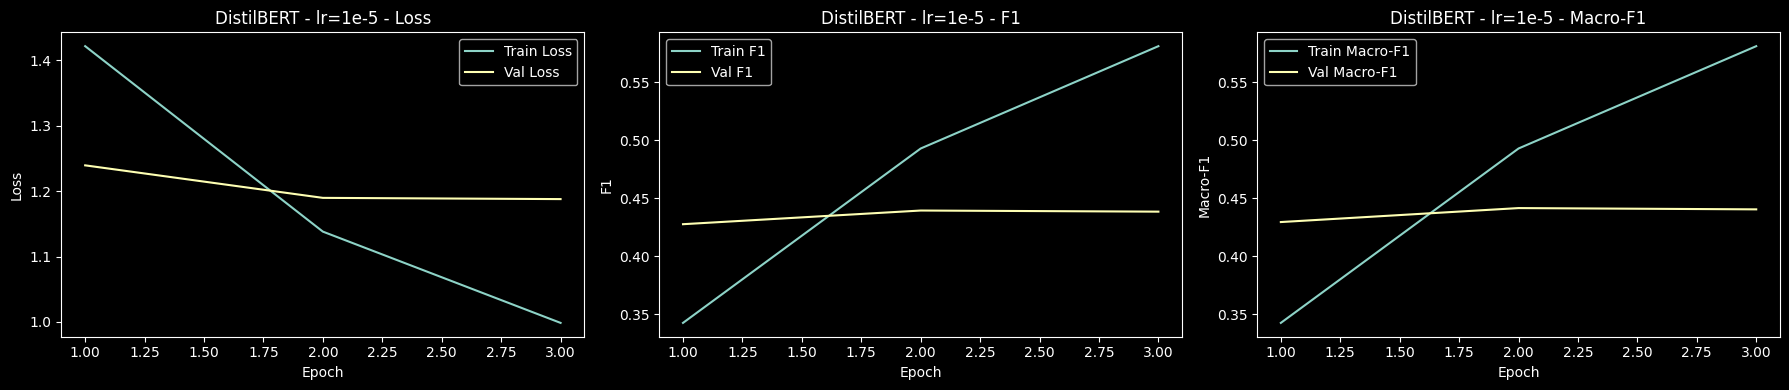

In [106]:
#Learning curve
plot_learning_curves(distilbert_lr1e5_history, title="DistilBERT - lr=1e-5")

In [107]:
#Evaluate
distilbert_lr1e5_test_loss, distilbert_lr1e5_test_metrics, y_true_distilbert_lr1e5, y_pred_distilbert_lr1e5 = evaluate_transformer(
    distilbert_lr1e5_model,
    distilbert_test_loader,
    device
)

print("DistilBERT (lr=1e-5) Test Loss:", round(distilbert_lr1e5_test_loss, 4))
print("DistilBERT (lr=1e-5) Test Metrics:", distilbert_lr1e5_test_metrics)

DistilBERT (lr=1e-5) Test Loss: 1.1827
DistilBERT (lr=1e-5) Test Metrics: {'accuracy': 0.4334841628959276, 'precision': 0.4529224177770411, 'recall': 0.4334841628959276, 'f1': 0.424834668681587, 'macro_f1': 0.43367690357286826}


#### Với learning rate = 5e-5

In [108]:
#Khởi tạo mô hình
distilbert_lr5e5_model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_NAME,
    num_labels=5
).to(device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8996.02it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [109]:
#Optimizer và scheduler
distilbert_lr5e5_epochs = 3
distilbert_lr5e5 = 5e-5

distilbert_lr5e5_optimizer = torch.optim.AdamW(
    distilbert_lr5e5_model.parameters(),
    lr=distilbert_lr5e5
)

distilbert_lr5e5_total_steps = len(distilbert_train_loader) * distilbert_lr5e5_epochs

distilbert_lr5e5_scheduler = get_linear_schedule_with_warmup(
    distilbert_lr5e5_optimizer,
    num_warmup_steps=0,
    num_training_steps=distilbert_lr5e5_total_steps
)

In [110]:
#Train
distilbert_lr5e5_model, distilbert_lr5e5_history = train_transformer_model(
    distilbert_lr5e5_model,
    distilbert_train_loader,
    distilbert_val_loader,
    distilbert_lr5e5_optimizer,
    distilbert_lr5e5_scheduler,
    device,
    epochs=distilbert_lr5e5_epochs
)


Epoch 1/3


Train Loss: 1.3884 | Acc: 0.3528 | Prec: 0.3427 | Recall: 0.3528 | F1: 0.3395 | Macro-F1: 0.3395
Val   Loss: 1.2089 | Acc: 0.4682 | Prec: 0.4660 | Recall: 0.4682 | F1: 0.4596 | Macro-F1: 0.4611

Epoch 2/3


Train Loss: 1.0130 | Acc: 0.5508 | Prec: 0.5442 | Recall: 0.5508 | F1: 0.5426 | Macro-F1: 0.5426
Val   Loss: 1.2381 | Acc: 0.4790 | Prec: 0.4809 | Recall: 0.4790 | F1: 0.4693 | Macro-F1: 0.4707

Epoch 3/3


Train Loss: 0.6774 | Acc: 0.7336 | Prec: 0.7316 | Recall: 0.7336 | F1: 0.7312 | Macro-F1: 0.7312
Val   Loss: 1.3224 | Acc: 0.4804 | Prec: 0.4906 | Recall: 0.4804 | F1: 0.4833 | Macro-F1: 0.4838


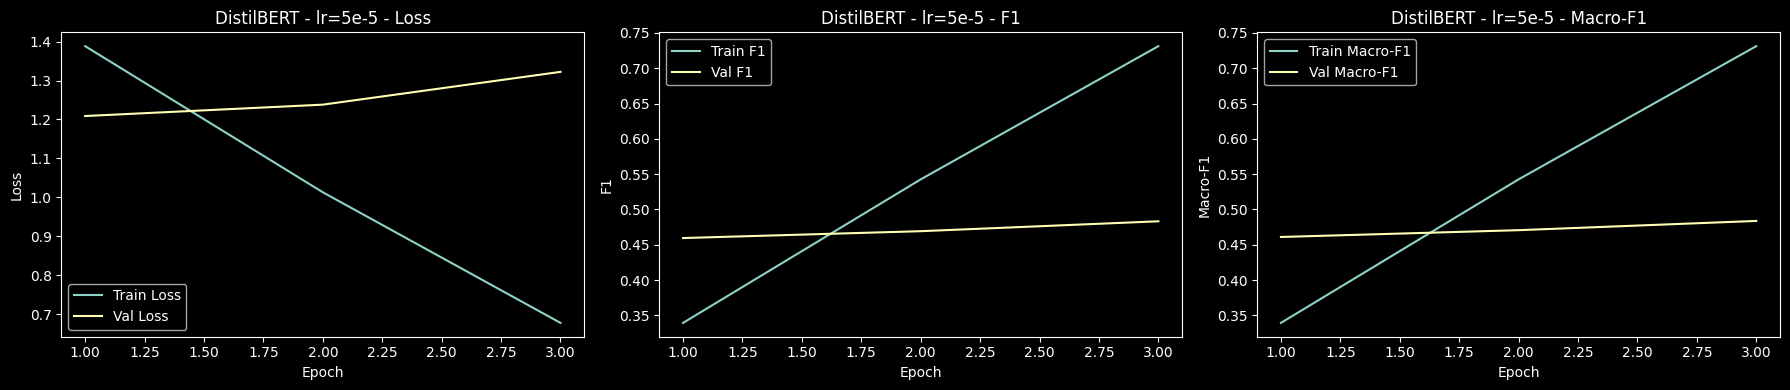

In [111]:
#Learning curve
plot_learning_curves(distilbert_lr5e5_history, title="DistilBERT - lr=5e-5")

In [112]:
#Evaluate
distilbert_lr5e5_test_loss, distilbert_lr5e5_test_metrics, y_true_distilbert_lr5e5, y_pred_distilbert_lr5e5 = evaluate_transformer(
    distilbert_lr5e5_model,
    distilbert_test_loader,
    device
)

print("DistilBERT (lr=5e-5) Test Loss:", round(distilbert_lr5e5_test_loss, 4))
print("DistilBERT (lr=5e-5) Test Metrics:", distilbert_lr5e5_test_metrics)

DistilBERT (lr=5e-5) Test Loss: 1.3099
DistilBERT (lr=5e-5) Test Metrics: {'accuracy': 0.46199095022624437, 'precision': 0.48700763017196136, 'recall': 0.46199095022624437, 'f1': 0.46722838702396496, 'macro_f1': 0.466808660962187}


#### So sánh learning rate

In [113]:
distilbert_lr_compare_df = pd.DataFrame([
    {
        "learning_rate": "1e-5",
        "accuracy": distilbert_lr1e5_test_metrics["accuracy"],
        "precision": distilbert_lr1e5_test_metrics["precision"],
        "recall": distilbert_lr1e5_test_metrics["recall"],
        "f1": distilbert_lr1e5_test_metrics["f1"],
        "macro_f1": distilbert_lr1e5_test_metrics["macro_f1"]
    },
    {
        "learning_rate": "2e-5",
        "accuracy": distilbert_test_metrics["accuracy"],
        "precision": distilbert_test_metrics["precision"],
        "recall": distilbert_test_metrics["recall"],
        "f1": distilbert_test_metrics["f1"],
        "macro_f1": distilbert_test_metrics["macro_f1"]
    },
    {
        "learning_rate": "5e-5",
        "accuracy": distilbert_lr5e5_test_metrics["accuracy"],
        "precision": distilbert_lr5e5_test_metrics["precision"],
        "recall": distilbert_lr5e5_test_metrics["recall"],
        "f1": distilbert_lr5e5_test_metrics["f1"],
        "macro_f1": distilbert_lr5e5_test_metrics["macro_f1"]
    }
])

distilbert_lr_compare_df

,learning_rate,accuracy,precision,recall,f1,macro_f1
0,1e-5,0.433484,0.452922,0.433484,0.424835,0.433677
1,2e-5,0.455204,0.473815,0.455204,0.454708,0.458299
2,5e-5,0.461991,0.487008,0.461991,0.467228,0.466809


### 5. Ảnh hưởng của max length

#### DataLoader với max_len = 64

In [114]:
#Dataset và DataLoader
distilbert64_train_dataset = TransformerTextDataset(train_small_df, distilbert_tokenizer, max_len=64)
distilbert64_val_dataset = TransformerTextDataset(val_small_df, distilbert_tokenizer, max_len=64)
distilbert64_test_dataset = TransformerTextDataset(test_df, distilbert_tokenizer, max_len=64)

distilbert64_train_loader = DataLoader(distilbert64_train_dataset, batch_size=8, shuffle=True)
distilbert64_val_loader = DataLoader(distilbert64_val_dataset, batch_size=8, shuffle=False)
distilbert64_test_loader = DataLoader(distilbert64_test_dataset, batch_size=8, shuffle=False)

In [115]:
#Khởi tạo mô hình
distilbert_len64_model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_NAME,
    num_labels=5
).to(device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6776.81it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [116]:
#Optimizer và scheduler
distilbert_len64_epochs = 3
distilbert_len64_lr = 2e-5

distilbert_len64_optimizer = torch.optim.AdamW(
    distilbert_len64_model.parameters(),
    lr=distilbert_len64_lr
)

distilbert_len64_total_steps = len(distilbert64_train_loader) * distilbert_len64_epochs

distilbert_len64_scheduler = get_linear_schedule_with_warmup(
    distilbert_len64_optimizer,
    num_warmup_steps=0,
    num_training_steps=distilbert_len64_total_steps
)

In [117]:
#Train
distilbert_len64_model, distilbert_len64_history = train_transformer_model(
    distilbert_len64_model,
    distilbert64_train_loader,
    distilbert64_val_loader,
    distilbert_len64_optimizer,
    distilbert_len64_scheduler,
    device,
    epochs=distilbert_len64_epochs
)


Epoch 1/3


Train Loss: 1.3678 | Acc: 0.3748 | Prec: 0.3568 | Recall: 0.3748 | F1: 0.3595 | Macro-F1: 0.3595
Val   Loss: 1.2718 | Acc: 0.4249 | Prec: 0.4279 | Recall: 0.4249 | F1: 0.4039 | Macro-F1: 0.4061

Epoch 2/3


Train Loss: 1.0438 | Acc: 0.5448 | Prec: 0.5346 | Recall: 0.5448 | F1: 0.5340 | Macro-F1: 0.5340
Val   Loss: 1.1876 | Acc: 0.4574 | Prec: 0.4622 | Recall: 0.4574 | F1: 0.4583 | Macro-F1: 0.4598

Epoch 3/3


Train Loss: 0.8335 | Acc: 0.6872 | Prec: 0.6831 | Recall: 0.6872 | F1: 0.6829 | Macro-F1: 0.6829
Val   Loss: 1.1893 | Acc: 0.4547 | Prec: 0.4521 | Recall: 0.4547 | F1: 0.4525 | Macro-F1: 0.4539


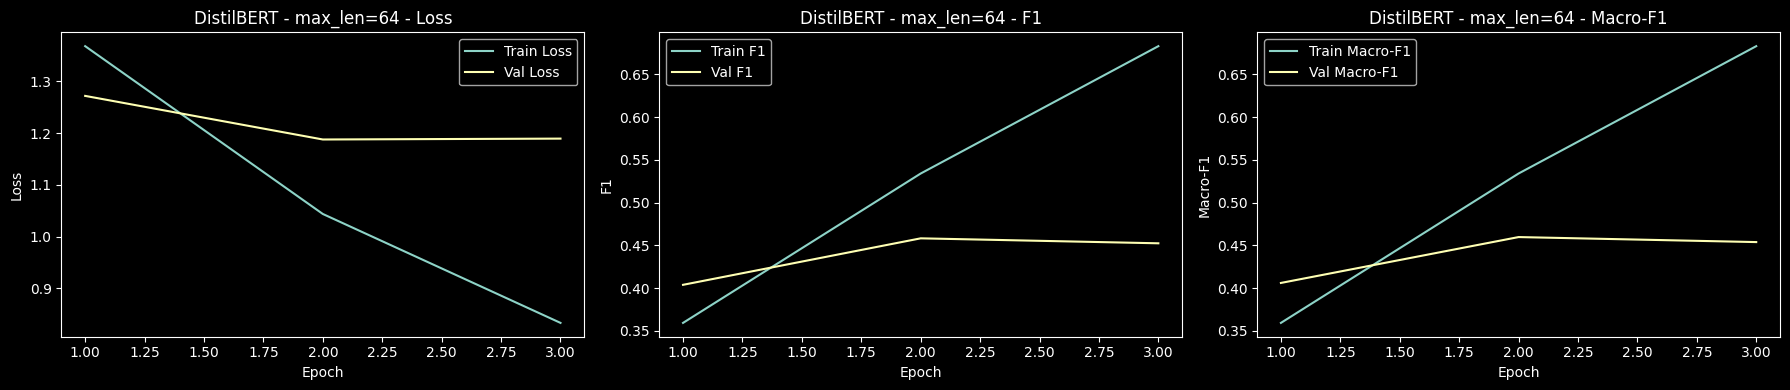

In [118]:
#Learning curve
plot_learning_curves(distilbert_len64_history, title="DistilBERT - max_len=64")

In [119]:
#Evaluate
distilbert_len64_test_loss, distilbert_len64_test_metrics, y_true_distilbert_len64, y_pred_distilbert_len64 = evaluate_transformer(
    distilbert_len64_model,
    distilbert64_test_loader,
    device
)

print("DistilBERT (max_len=64) Test Loss:", round(distilbert_len64_test_loss, 4))
print("DistilBERT (max_len=64) Test Metrics:", distilbert_len64_test_metrics)

DistilBERT (max_len=64) Test Loss: 1.1834
DistilBERT (max_len=64) Test Metrics: {'accuracy': 0.45339366515837104, 'precision': 0.47236072012974084, 'recall': 0.45339366515837104, 'f1': 0.4528688359825369, 'macro_f1': 0.4573015844652719}


#### DataLoader với max_len = 192

In [120]:
#Dataset va dataloader
distilbert192_train_dataset = TransformerTextDataset(train_small_df, distilbert_tokenizer, max_len=192)
distilbert192_val_dataset = TransformerTextDataset(val_small_df, distilbert_tokenizer, max_len=192)
distilbert192_test_dataset = TransformerTextDataset(test_df, distilbert_tokenizer, max_len=192)

distilbert192_train_loader = DataLoader(distilbert192_train_dataset, batch_size=8, shuffle=True)
distilbert192_val_loader = DataLoader(distilbert192_val_dataset, batch_size=8, shuffle=False)
distilbert192_test_loader = DataLoader(distilbert192_test_dataset, batch_size=8, shuffle=False)

In [121]:
#Khoitao
distilbert_len192_model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_NAME,
    num_labels=5
).to(device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7993.11it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [122]:
#Optimizer và scheduler
distilbert_len192_epochs = 3
distilbert_len192_lr = 2e-5

distilbert_len192_optimizer = torch.optim.AdamW(
    distilbert_len192_model.parameters(),
    lr=distilbert_len192_lr
)

distilbert_len192_total_steps = len(distilbert192_train_loader) * distilbert_len192_epochs

distilbert_len192_scheduler = get_linear_schedule_with_warmup(
    distilbert_len192_optimizer,
    num_warmup_steps=0,
    num_training_steps=distilbert_len192_total_steps
)

In [123]:
#Train
distilbert_len192_model, distilbert_len192_history = train_transformer_model(
    distilbert_len192_model,
    distilbert192_train_loader,
    distilbert192_val_loader,
    distilbert_len192_optimizer,
    distilbert_len192_scheduler,
    device,
    epochs=distilbert_len192_epochs
)


Epoch 1/3


Train Loss: 1.3580 | Acc: 0.3864 | Prec: 0.3658 | Recall: 0.3864 | F1: 0.3683 | Macro-F1: 0.3683
Val   Loss: 1.2104 | Acc: 0.4465 | Prec: 0.4380 | Recall: 0.4465 | F1: 0.4354 | Macro-F1: 0.4373

Epoch 2/3


Train Loss: 1.0442 | Acc: 0.5668 | Prec: 0.5572 | Recall: 0.5668 | F1: 0.5577 | Macro-F1: 0.5577
Val   Loss: 1.1889 | Acc: 0.4425 | Prec: 0.4301 | Recall: 0.4425 | F1: 0.4329 | Macro-F1: 0.4345

Epoch 3/3


Train Loss: 0.8406 | Acc: 0.6692 | Prec: 0.6637 | Recall: 0.6692 | F1: 0.6632 | Macro-F1: 0.6632
Val   Loss: 1.2162 | Acc: 0.4465 | Prec: 0.4424 | Recall: 0.4465 | F1: 0.4440 | Macro-F1: 0.4454


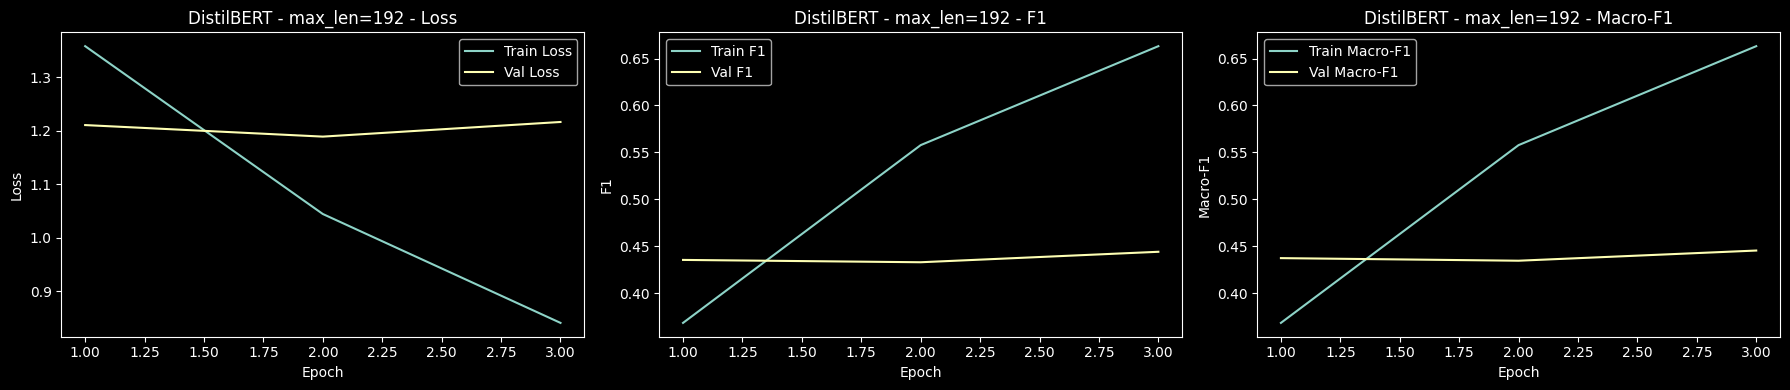

In [124]:
#Learning curve
plot_learning_curves(distilbert_len192_history, title="DistilBERT - max_len=192")

In [125]:
#Evaluate
distilbert_len192_test_loss, distilbert_len192_test_metrics, y_true_distilbert_len192, y_pred_distilbert_len192 = evaluate_transformer(
    distilbert_len192_model,
    distilbert192_test_loader,
    device
)

print("DistilBERT (max_len=192) Test Loss:", round(distilbert_len192_test_loss, 4))
print("DistilBERT (max_len=192) Test Metrics:", distilbert_len192_test_metrics)

DistilBERT (max_len=192) Test Loss: 1.1841
DistilBERT (max_len=192) Test Metrics: {'accuracy': 0.45294117647058824, 'precision': 0.46422341444950826, 'recall': 0.45294117647058824, 'f1': 0.45091524576859504, 'macro_f1': 0.4552223528909072}


#### So sánh ảnh hưởng của max length

In [126]:
distilbert_maxlen_compare_df = pd.DataFrame([
    {
        "max_len": 64,
        "accuracy": distilbert_len64_test_metrics["accuracy"],
        "precision": distilbert_len64_test_metrics["precision"],
        "recall": distilbert_len64_test_metrics["recall"],
        "f1": distilbert_len64_test_metrics["f1"],
        "macro_f1": distilbert_len64_test_metrics["macro_f1"]
    },
    {
        "max_len": 128,
        "accuracy": distilbert_test_metrics["accuracy"],
        "precision": distilbert_test_metrics["precision"],
        "recall": distilbert_test_metrics["recall"],
        "f1": distilbert_test_metrics["f1"],
        "macro_f1": distilbert_test_metrics["macro_f1"]
    },
    {
        "max_len": 192,
        "accuracy": distilbert_len192_test_metrics["accuracy"],
        "precision": distilbert_len192_test_metrics["precision"],
        "recall": distilbert_len192_test_metrics["recall"],
        "f1": distilbert_len192_test_metrics["f1"],
        "macro_f1": distilbert_len192_test_metrics["macro_f1"]
    }
])

distilbert_maxlen_compare_df

,max_len,accuracy,precision,recall,f1,macro_f1
0,64,0.453394,0.472361,0.453394,0.452869,0.457302
1,128,0.455204,0.473815,0.455204,0.454708,0.458299
2,192,0.452941,0.464223,0.452941,0.450915,0.455222


### 6. Ảnh hưởng của freeze strategy

In [127]:
#Khoi tao mo hinh
distilbert_frozen_model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_NAME,
    num_labels=5
).to(device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7688.92it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [128]:
#Freeze encoder
for param in distilbert_frozen_model.distilbert.parameters():
    param.requires_grad = False

In [129]:
#Optimizer và scheduler
distilbert_frozen_epochs = 3
distilbert_frozen_lr = 2e-5

distilbert_frozen_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, distilbert_frozen_model.parameters()),
    lr=distilbert_frozen_lr
)

distilbert_frozen_total_steps = len(distilbert_train_loader) * distilbert_frozen_epochs

distilbert_frozen_scheduler = get_linear_schedule_with_warmup(
    distilbert_frozen_optimizer,
    num_warmup_steps=0,
    num_training_steps=distilbert_frozen_total_steps
)

In [130]:
#Train
distilbert_frozen_model, distilbert_frozen_history = train_transformer_model(
    distilbert_frozen_model,
    distilbert_train_loader,
    distilbert_val_loader,
    distilbert_frozen_optimizer,
    distilbert_frozen_scheduler,
    device,
    epochs=distilbert_frozen_epochs
)


Epoch 1/3


Train Loss: 1.5981 | Acc: 0.2508 | Prec: 0.2495 | Recall: 0.2508 | F1: 0.2345 | Macro-F1: 0.2345
Val   Loss: 1.5808 | Acc: 0.3221 | Prec: 0.3199 | Recall: 0.3221 | F1: 0.2650 | Macro-F1: 0.2671

Epoch 2/3


Train Loss: 1.5746 | Acc: 0.3272 | Prec: 0.3128 | Recall: 0.3272 | F1: 0.3071 | Macro-F1: 0.3071
Val   Loss: 1.5617 | Acc: 0.3613 | Prec: 0.3650 | Recall: 0.3613 | F1: 0.3249 | Macro-F1: 0.3263

Epoch 3/3


Train Loss: 1.5596 | Acc: 0.3608 | Prec: 0.3556 | Recall: 0.3608 | F1: 0.3468 | Macro-F1: 0.3468
Val   Loss: 1.5551 | Acc: 0.3708 | Prec: 0.3781 | Recall: 0.3708 | F1: 0.3376 | Macro-F1: 0.3386


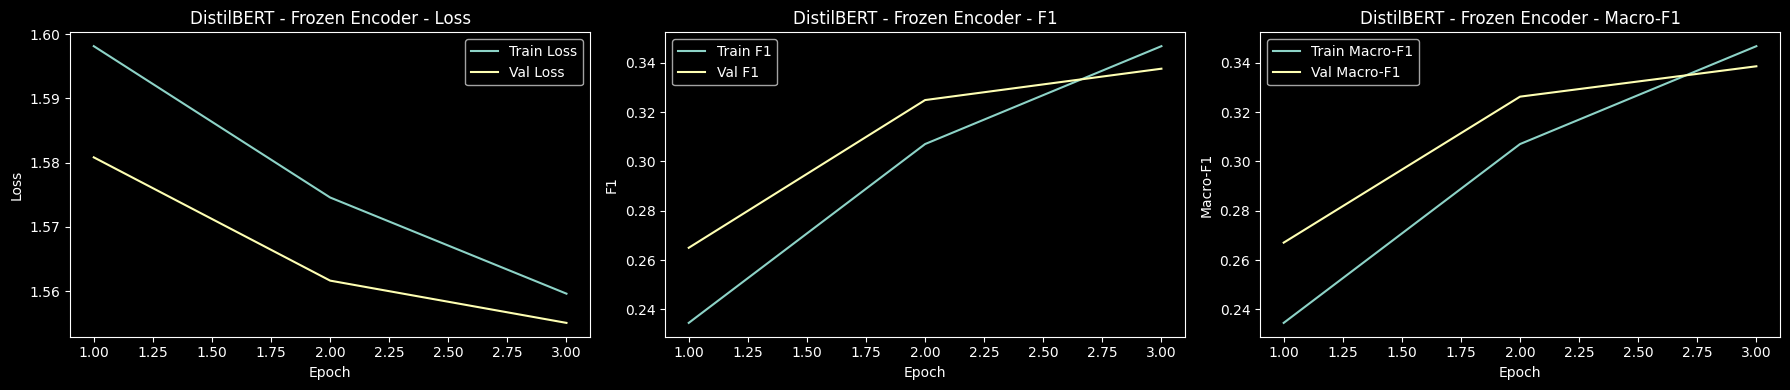

In [131]:
#Learning curve
plot_learning_curves(distilbert_frozen_history, title="DistilBERT - Frozen Encoder")

In [132]:
#Evaluate
distilbert_frozen_test_loss, distilbert_frozen_test_metrics, y_true_distilbert_frozen, y_pred_distilbert_frozen = evaluate_transformer(
    distilbert_frozen_model,
    distilbert_test_loader,
    device
)

print("DistilBERT (frozen encoder) Test Loss:", round(distilbert_frozen_test_loss, 4))
print("DistilBERT (frozen encoder) Test Metrics:", distilbert_frozen_test_metrics)

DistilBERT (frozen encoder) Test Loss: 1.5557
DistilBERT (frozen encoder) Test Metrics: {'accuracy': 0.3742081447963801, 'precision': 0.3554342801252776, 'recall': 0.3742081447963801, 'f1': 0.34343001187054073, 'macro_f1': 0.3316128538826312}


#### So sánh

In [133]:
distilbert_freeze_compare_df = pd.DataFrame([
    {
        "strategy": "unfreeze_all",
        "accuracy": distilbert_test_metrics["accuracy"],
        "precision": distilbert_test_metrics["precision"],
        "recall": distilbert_test_metrics["recall"],
        "f1": distilbert_test_metrics["f1"],
        "macro_f1": distilbert_test_metrics["macro_f1"]
    },
    {
        "strategy": "freeze_encoder",
        "accuracy": distilbert_frozen_test_metrics["accuracy"],
        "precision": distilbert_frozen_test_metrics["precision"],
        "recall": distilbert_frozen_test_metrics["recall"],
        "f1": distilbert_frozen_test_metrics["f1"],
        "macro_f1": distilbert_frozen_test_metrics["macro_f1"]
    }
])

distilbert_freeze_compare_df

,strategy,accuracy,precision,recall,f1,macro_f1
0,unfreeze_all,0.455204,0.473815,0.455204,0.454708,0.458299
1,freeze_encoder,0.374208,0.355434,0.374208,0.343430,0.331613


### 7. Bảng tổng hợp kết quả Fine-tune

In [134]:
all_distilbert_results = pd.DataFrame([
    {
        "experiment": "DistilBERT baseline",
        "accuracy": distilbert_test_metrics["accuracy"],
        "precision": distilbert_test_metrics["precision"],
        "recall": distilbert_test_metrics["recall"],
        "f1": distilbert_test_metrics["f1"],
        "macro_f1": distilbert_test_metrics["macro_f1"]
    },
    {
        "experiment": "DistilBERT lr=1e-5",
        "accuracy": distilbert_lr1e5_test_metrics["accuracy"],
        "precision": distilbert_lr1e5_test_metrics["precision"],
        "recall": distilbert_lr1e5_test_metrics["recall"],
        "f1": distilbert_lr1e5_test_metrics["f1"],
        "macro_f1": distilbert_lr1e5_test_metrics["macro_f1"]
    },
    {
        "experiment": "DistilBERT lr=5e-5",
        "accuracy": distilbert_lr5e5_test_metrics["accuracy"],
        "precision": distilbert_lr5e5_test_metrics["precision"],
        "recall": distilbert_lr5e5_test_metrics["recall"],
        "f1": distilbert_lr5e5_test_metrics["f1"],
        "macro_f1": distilbert_lr5e5_test_metrics["macro_f1"]
    },
    {
        "experiment": "DistilBERT max_len=64",
        "accuracy": distilbert_len64_test_metrics["accuracy"],
        "precision": distilbert_len64_test_metrics["precision"],
        "recall": distilbert_len64_test_metrics["recall"],
        "f1": distilbert_len64_test_metrics["f1"],
        "macro_f1": distilbert_len64_test_metrics["macro_f1"]
    },
    {
        "experiment": "DistilBERT max_len=192",
        "accuracy": distilbert_len192_test_metrics["accuracy"],
        "precision": distilbert_len192_test_metrics["precision"],
        "recall": distilbert_len192_test_metrics["recall"],
        "f1": distilbert_len192_test_metrics["f1"],
        "macro_f1": distilbert_len192_test_metrics["macro_f1"]
    },
    {
        "experiment": "DistilBERT freeze encoder",
        "accuracy": distilbert_frozen_test_metrics["accuracy"],
        "precision": distilbert_frozen_test_metrics["precision"],
        "recall": distilbert_frozen_test_metrics["recall"],
        "f1": distilbert_frozen_test_metrics["f1"],
        "macro_f1": distilbert_frozen_test_metrics["macro_f1"]
    }
])

all_distilbert_results.sort_values(by="macro_f1", ascending=False).reset_index(drop=True)

,experiment,accuracy,precision,recall,f1,macro_f1
0,DistilBERT lr=5e-5,0.461991,0.487008,0.461991,0.467228,0.466809
1,DistilBERT baseline,0.455204,0.473815,0.455204,0.454708,0.458299
2,DistilBERT max_len=64,0.453394,0.472361,0.453394,0.452869,0.457302
3,DistilBERT max_len=192,0.452941,0.464223,0.452941,0.450915,0.455222
4,DistilBERT lr=1e-5,0.433484,0.452922,0.433484,0.424835,0.433677
5,DistilBERT freeze encoder,0.374208,0.355434,0.374208,0.343430,0.331613


## PHẦN VI. TRANSFORMER CUSTOM
Khác với DistilBERT là mô hình đã được pretrain, Transformer custom trong bài này được huấn luyện từ đầu trên bộ dữ liệu SST-5.

### 1. Xây dựng mô hình

In [135]:
#Endcode
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (B, L, D)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [136]:
#TransformerClassifier
class TransformerClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=128,
        nhead=4,
        num_encoder_layers=2,
        dim_feedforward=256,
        num_classes=5,
        dropout=0.1,
        max_len=50,
        pooling="mean",
        pad_idx=0
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.positional_encoding = PositionalEncoding(d_model=d_model, max_len=max_len, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_encoder_layers
        )

        self.pooling = pooling
        if pooling == "attention":
            self.attention = nn.Linear(d_model, 1)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, num_classes)
        self.pad_idx = pad_idx

    def forward(self, input_ids):
        # input_ids: (B, L)
        x = self.embedding(input_ids)                  # (B, L, D)
        x = self.positional_encoding(x)               # (B, L, D)

        padding_mask = (input_ids == self.pad_idx)    # (B, L), True at PAD positions
        outputs = self.transformer_encoder(x, src_key_padding_mask=padding_mask)

        if self.pooling == "last":
            rep = outputs[:, -1, :]

        elif self.pooling == "mean":
            mask = (~padding_mask).unsqueeze(-1).float()
            rep = (outputs * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

        elif self.pooling == "max":
            masked_outputs = outputs.masked_fill(padding_mask.unsqueeze(-1), float("-inf"))
            rep, _ = masked_outputs.max(dim=1)

        elif self.pooling == "attention":
            attn_scores = self.attention(outputs)  # (B, L, 1)
            attn_scores = attn_scores.masked_fill(padding_mask.unsqueeze(-1), float("-inf"))
            attn_weights = torch.softmax(attn_scores, dim=1)
            rep = torch.sum(attn_weights * outputs, dim=1)

        else:
            raise ValueError("pooling must be one of: last, mean, max, attention")

        rep = self.dropout(rep)
        logits = self.fc(rep)
        return logits

### 2. Baseline transformer
Cấu hình baseline được chọn như sau:

- d_model = 128
- nhead = 4
- num_encoder_layers = 2
- dim_feedforward = 256
- pooling = mean

In [137]:
#Khoitao
transformer_model = TransformerClassifier(
    vocab_size=len(vocab),
    d_model=128,
    nhead=4,
    num_encoder_layers=2,
    dim_feedforward=256,
    num_classes=5,
    dropout=0.1,
    max_len=MAX_LEN,
    pooling="mean",
    pad_idx=PAD_IDX
).to(device)

In [138]:
#Optimzer va criterion
transformer_epochs = 5
transformer_lr = 1e-3

transformer_optimizer = torch.optim.Adam(transformer_model.parameters(), lr=transformer_lr)
transformer_criterion = nn.CrossEntropyLoss()

In [139]:
#Train
transformer_model, transformer_history = train_model(
    transformer_model,
    train_loader,
    val_loader,
    transformer_optimizer,
    transformer_criterion,
    device,
    epochs=transformer_epochs
)


Epoch 1/5


Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]        D:\Code\Python\Sentiment_Analyst\.venv\Lib\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Train Loss: 1.6355 | Acc: 0.2200 | Prec: 0.2192 | Recall: 0.2200 | F1: 0.2192 | Macro-F1: 0.2192
Val   Loss: 1.5864 | Acc: 0.2585 | Prec: 0.2475 | Recall: 0.2585 | F1: 0.1846 | Macro-F1: 0.1833

Epoch 2/5


Train Loss: 1.5547 | Acc: 0.2740 | Prec: 0.2708 | Recall: 0.2740 | F1: 0.2711 | Macro-F1: 0.2711
Val   Loss: 1.5835 | Acc: 0.3058 | Prec: 0.3625 | Recall: 0.3058 | F1: 0.2558 | Macro-F1: 0.2575

Epoch 3/5


Train Loss: 1.4711 | Acc: 0.3472 | Prec: 0.3409 | Recall: 0.3472 | F1: 0.3389 | Macro-F1: 0.3389
Val   Loss: 1.5968 | Acc: 0.2747 | Prec: 0.2761 | Recall: 0.2747 | F1: 0.2296 | Macro-F1: 0.2310

Epoch 4/5


Train Loss: 1.3677 | Acc: 0.4032 | Prec: 0.3937 | Recall: 0.4032 | F1: 0.3943 | Macro-F1: 0.3943
Val   Loss: 1.5627 | Acc: 0.3248 | Prec: 0.3143 | Recall: 0.3248 | F1: 0.2965 | Macro-F1: 0.2979

Epoch 5/5


Train Loss: 1.2471 | Acc: 0.4864 | Prec: 0.4828 | Recall: 0.4864 | F1: 0.4821 | Macro-F1: 0.4821
Val   Loss: 1.6576 | Acc: 0.2788 | Prec: 0.3091 | Recall: 0.2788 | F1: 0.2703 | Macro-F1: 0.2697


In [140]:
#Evaluate
transformer_test_loss, transformer_test_metrics, y_true_transformer, y_pred_transformer = evaluate(
    transformer_model,
    test_loader,
    transformer_criterion,
    device
)

print("Custom Transformer Test Loss:", round(transformer_test_loss, 4))
print("Custom Transformer Test Metrics:", transformer_test_metrics)

Custom Transformer Test Loss: 1.6438
Custom Transformer Test Metrics: {'accuracy': 0.27058823529411763, 'precision': 0.3100476509993689, 'recall': 0.27058823529411763, 'f1': 0.27022489382340403, 'macro_f1': 0.268585987623542}


### 3. Ảnh hưởng số lớp encoder

#### Transformer với num_encoder_layers = 1

In [141]:
#Khoi tao
transformer_layer1_model = TransformerClassifier(
    vocab_size=len(vocab),
    d_model=128,
    nhead=4,
    num_encoder_layers=1,
    dim_feedforward=256,
    num_classes=5,
    dropout=0.1,
    max_len=MAX_LEN,
    pooling="mean",
    pad_idx=PAD_IDX
).to(device)

In [142]:
#Optimizer
transformer_layer1_optimizer = torch.optim.Adam(transformer_layer1_model.parameters(), lr=1e-3)

In [143]:
#Train
transformer_layer1_model, transformer_layer1_history = train_model(
    transformer_layer1_model,
    train_loader,
    val_loader,
    transformer_layer1_optimizer,
    transformer_criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.6317 | Acc: 0.2184 | Prec: 0.2139 | Recall: 0.2184 | F1: 0.2133 | Macro-F1: 0.2133
Val   Loss: 1.6277 | Acc: 0.2057 | Prec: 0.3248 | Recall: 0.2057 | F1: 0.1234 | Macro-F1: 0.1253

Epoch 2/5


Train Loss: 1.5617 | Acc: 0.2772 | Prec: 0.2719 | Recall: 0.2772 | F1: 0.2669 | Macro-F1: 0.2669
Val   Loss: 1.5404 | Acc: 0.2720 | Prec: 0.2837 | Recall: 0.2720 | F1: 0.2665 | Macro-F1: 0.2674

Epoch 3/5


Train Loss: 1.4962 | Acc: 0.3300 | Prec: 0.3281 | Recall: 0.3300 | F1: 0.3281 | Macro-F1: 0.3281
Val   Loss: 1.5282 | Acc: 0.3126 | Prec: 0.2946 | Recall: 0.3126 | F1: 0.2675 | Macro-F1: 0.2690

Epoch 4/5


Train Loss: 1.4099 | Acc: 0.3888 | Prec: 0.3809 | Recall: 0.3888 | F1: 0.3806 | Macro-F1: 0.3806
Val   Loss: 1.6116 | Acc: 0.2679 | Prec: 0.2817 | Recall: 0.2679 | F1: 0.2488 | Macro-F1: 0.2502

Epoch 5/5


Train Loss: 1.3141 | Acc: 0.4536 | Prec: 0.4509 | Recall: 0.4536 | F1: 0.4516 | Macro-F1: 0.4516
Val   Loss: 1.6583 | Acc: 0.2963 | Prec: 0.2916 | Recall: 0.2963 | F1: 0.2782 | Macro-F1: 0.2779


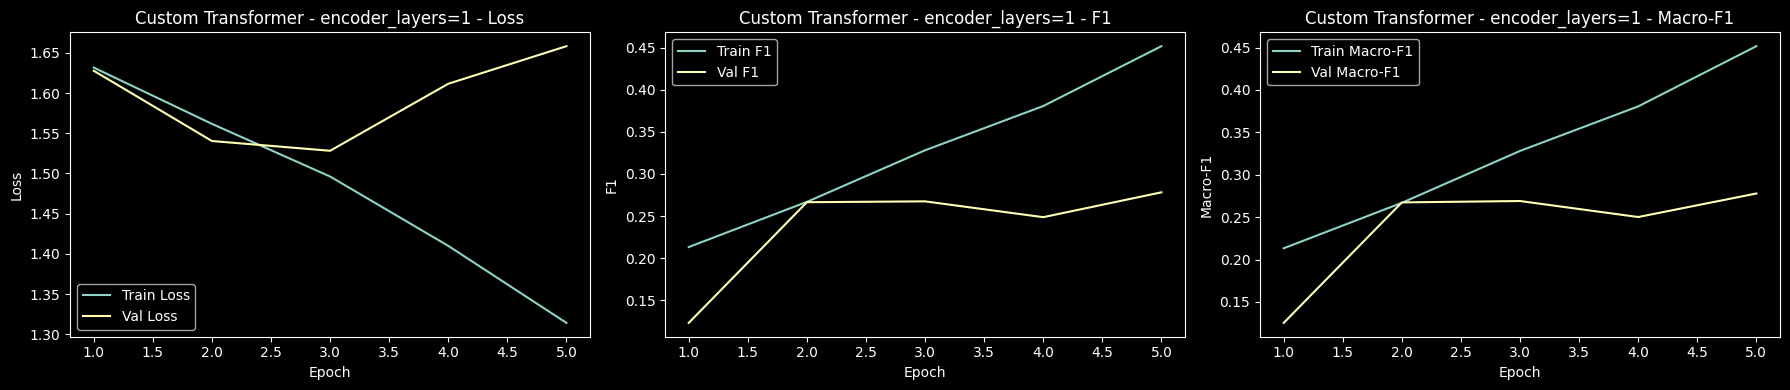

In [144]:
#Learning curve
plot_learning_curves(transformer_layer1_history, title="Custom Transformer - encoder_layers=1")

In [145]:
#Evaluate
transformer_layer1_test_loss, transformer_layer1_test_metrics, y_true_transformer_layer1, y_pred_transformer_layer1 = evaluate(
    transformer_layer1_model,
    test_loader,
    transformer_criterion,
    device
)

print("Transformer (encoder_layers=1) Test Loss:", round(transformer_layer1_test_loss, 4))
print("Transformer (encoder_layers=1) Test Metrics:", transformer_layer1_test_metrics)

Transformer (encoder_layers=1) Test Loss: 1.6332
Transformer (encoder_layers=1) Test Metrics: {'accuracy': 0.2855203619909502, 'precision': 0.29414552772799857, 'recall': 0.2855203619909502, 'f1': 0.27138852422730547, 'macro_f1': 0.26473795344167694}


#### Transformer với num_encoder_layers = 4

In [146]:
#Khoitao
transformer_layer4_model = TransformerClassifier(
    vocab_size=len(vocab),
    d_model=128,
    nhead=4,
    num_encoder_layers=4,
    dim_feedforward=256,
    num_classes=5,
    dropout=0.1,
    max_len=MAX_LEN,
    pooling="mean",
    pad_idx=PAD_IDX
).to(device)

In [147]:
#Optimizer
transformer_layer4_optimizer = torch.optim.Adam(transformer_layer4_model.parameters(), lr=1e-3)

In [148]:
#Train
transformer_layer4_model, transformer_layer4_history = train_model(
    transformer_layer4_model,
    train_loader,
    val_loader,
    transformer_layer4_optimizer,
    transformer_criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.6563 | Acc: 0.2008 | Prec: 0.2020 | Recall: 0.2008 | F1: 0.2011 | Macro-F1: 0.2011
Val   Loss: 1.6077 | Acc: 0.2179 | Prec: 0.1701 | Recall: 0.2179 | F1: 0.1385 | Macro-F1: 0.1373

Epoch 2/5


Train Loss: 1.6120 | Acc: 0.2508 | Prec: 0.2501 | Recall: 0.2508 | F1: 0.2501 | Macro-F1: 0.2501
Val   Loss: 1.6034 | Acc: 0.2652 | Prec: 0.2107 | Recall: 0.2652 | F1: 0.2062 | Macro-F1: 0.2036

Epoch 3/5


Train Loss: 1.5663 | Acc: 0.2816 | Prec: 0.2739 | Recall: 0.2816 | F1: 0.2729 | Macro-F1: 0.2729
Val   Loss: 1.6194 | Acc: 0.2530 | Prec: 0.4771 | Recall: 0.2530 | F1: 0.1903 | Macro-F1: 0.1877

Epoch 4/5


Train Loss: 1.4831 | Acc: 0.3496 | Prec: 0.3470 | Recall: 0.3496 | F1: 0.3469 | Macro-F1: 0.3469
Val   Loss: 1.5289 | Acc: 0.2828 | Prec: 0.2238 | Recall: 0.2828 | F1: 0.2400 | Macro-F1: 0.2411

Epoch 5/5


Train Loss: 1.3861 | Acc: 0.4048 | Prec: 0.4000 | Recall: 0.4048 | F1: 0.4005 | Macro-F1: 0.4005
Val   Loss: 1.5842 | Acc: 0.2950 | Prec: 0.3641 | Recall: 0.2950 | F1: 0.2111 | Macro-F1: 0.2098


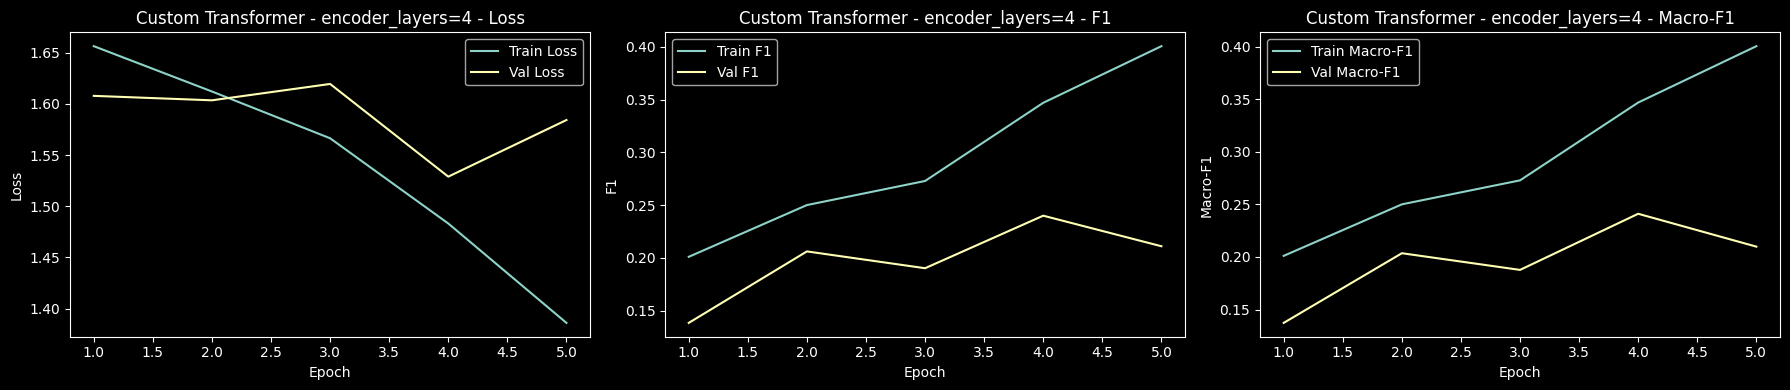

In [149]:
#Learning curve
plot_learning_curves(transformer_layer4_history, title="Custom Transformer - encoder_layers=4")

In [150]:
#Evaluate
transformer_layer4_test_loss, transformer_layer4_test_metrics, y_true_transformer_layer4, y_pred_transformer_layer4 = evaluate(
    transformer_layer4_model,
    test_loader,
    transformer_criterion,
    device
)

print("Transformer (encoder_layers=4) Test Loss:", round(transformer_layer4_test_loss, 4))
print("Transformer (encoder_layers=4) Test Metrics:", transformer_layer4_test_metrics)

Transformer (encoder_layers=4) Test Loss: 1.5498
Transformer (encoder_layers=4) Test Metrics: {'accuracy': 0.334841628959276, 'precision': 0.3427739759798261, 'recall': 0.334841628959276, 'f1': 0.2557588954063859, 'macro_f1': 0.23780204039783515}


#### So sánh

In [151]:
transformer_layers_compare_df = pd.DataFrame([
    {
        "num_encoder_layers": 1,
        "accuracy": transformer_layer1_test_metrics["accuracy"],
        "precision": transformer_layer1_test_metrics["precision"],
        "recall": transformer_layer1_test_metrics["recall"],
        "f1": transformer_layer1_test_metrics["f1"],
        "macro_f1": transformer_layer1_test_metrics["macro_f1"]
    },
    {
        "num_encoder_layers": 2,
        "accuracy": transformer_test_metrics["accuracy"],
        "precision": transformer_test_metrics["precision"],
        "recall": transformer_test_metrics["recall"],
        "f1": transformer_test_metrics["f1"],
        "macro_f1": transformer_test_metrics["macro_f1"]
    },
    {
        "num_encoder_layers": 4,
        "accuracy": transformer_layer4_test_metrics["accuracy"],
        "precision": transformer_layer4_test_metrics["precision"],
        "recall": transformer_layer4_test_metrics["recall"],
        "f1": transformer_layer4_test_metrics["f1"],
        "macro_f1": transformer_layer4_test_metrics["macro_f1"]
    }
])

transformer_layers_compare_df

,num_encoder_layers,accuracy,precision,recall,f1,macro_f1
0,1,0.285520,0.294146,0.285520,0.271389,0.264738
1,2,0.270588,0.310048,0.270588,0.270225,0.268586
2,4,0.334842,0.342774,0.334842,0.255759,0.237802


### 4. Ảnh hưởng của số attention heads

#### Transformer với nhead = 2

In [152]:
#Khoi tao
transformer_head2_model = TransformerClassifier(
    vocab_size=len(vocab),
    d_model=128,
    nhead=2,
    num_encoder_layers=2,
    dim_feedforward=256,
    num_classes=5,
    dropout=0.1,
    max_len=MAX_LEN,
    pooling="mean",
    pad_idx=PAD_IDX
).to(device)

In [153]:
#Optimizer
transformer_head2_optimizer = torch.optim.Adam(transformer_head2_model.parameters(), lr=1e-3)

In [154]:
#Train
transformer_head2_model, transformer_head2_history = train_model(
    transformer_head2_model,
    train_loader,
    val_loader,
    transformer_head2_optimizer,
    transformer_criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.6396 | Acc: 0.2184 | Prec: 0.2164 | Recall: 0.2184 | F1: 0.2155 | Macro-F1: 0.2155
Val   Loss: 1.5815 | Acc: 0.2503 | Prec: 0.2905 | Recall: 0.2503 | F1: 0.1952 | Macro-F1: 0.1937

Epoch 2/5


Train Loss: 1.5544 | Acc: 0.2832 | Prec: 0.2793 | Recall: 0.2832 | F1: 0.2790 | Macro-F1: 0.2790
Val   Loss: 1.5821 | Acc: 0.2368 | Prec: 0.2162 | Recall: 0.2368 | F1: 0.1928 | Macro-F1: 0.1942

Epoch 3/5


Train Loss: 1.4766 | Acc: 0.3592 | Prec: 0.3523 | Recall: 0.3592 | F1: 0.3517 | Macro-F1: 0.3517
Val   Loss: 1.5195 | Acc: 0.2882 | Prec: 0.2999 | Recall: 0.2882 | F1: 0.2743 | Macro-F1: 0.2738

Epoch 4/5


Train Loss: 1.3782 | Acc: 0.3940 | Prec: 0.3847 | Recall: 0.3940 | F1: 0.3861 | Macro-F1: 0.3861
Val   Loss: 1.5254 | Acc: 0.2950 | Prec: 0.3118 | Recall: 0.2950 | F1: 0.2713 | Macro-F1: 0.2722

Epoch 5/5


Train Loss: 1.2843 | Acc: 0.4476 | Prec: 0.4448 | Recall: 0.4476 | F1: 0.4452 | Macro-F1: 0.4452
Val   Loss: 1.5697 | Acc: 0.3315 | Prec: 0.3272 | Recall: 0.3315 | F1: 0.3094 | Macro-F1: 0.3097


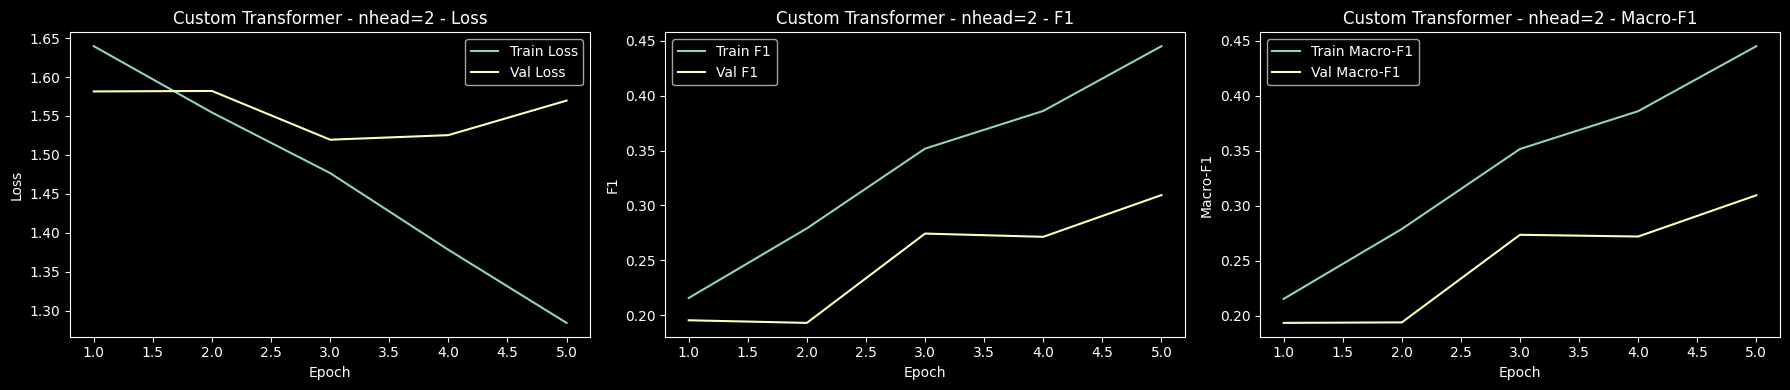

In [155]:
#Learning curve
plot_learning_curves(transformer_head2_history, title="Custom Transformer - nhead=2")

In [156]:
#Evaluate
transformer_head2_test_loss, transformer_head2_test_metrics, y_true_transformer_head2, y_pred_transformer_head2 = evaluate(
    transformer_head2_model,
    test_loader,
    transformer_criterion,
    device
)

print("Transformer (nhead=2) Test Loss:", round(transformer_head2_test_loss, 4))
print("Transformer (nhead=2) Test Metrics:", transformer_head2_test_metrics)

Transformer (nhead=2) Test Loss: 1.6201
Transformer (nhead=2) Test Metrics: {'accuracy': 0.285972850678733, 'precision': 0.28267005473832996, 'recall': 0.285972850678733, 'f1': 0.26341519996866464, 'macro_f1': 0.26399325658153905}


#### Transformer với nhead = 8

In [157]:
#Khoitao va Optimizer
transformer_head8_model = TransformerClassifier(
    vocab_size=len(vocab),
    d_model=128,
    nhead=8,
    num_encoder_layers=2,
    dim_feedforward=256,
    num_classes=5,
    dropout=0.1,
    max_len=MAX_LEN,
    pooling="mean",
    pad_idx=PAD_IDX
).to(device)

transformer_head8_optimizer = torch.optim.Adam(transformer_head8_model.parameters(), lr=1e-3)

In [158]:
#Train
transformer_head8_model, transformer_head8_history = train_model(
    transformer_head8_model,
    train_loader,
    val_loader,
    transformer_head8_optimizer,
    transformer_criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.6504 | Acc: 0.2368 | Prec: 0.2367 | Recall: 0.2368 | F1: 0.2325 | Macro-F1: 0.2325
Val   Loss: 1.5940 | Acc: 0.2436 | Prec: 0.2563 | Recall: 0.2436 | F1: 0.2032 | Macro-F1: 0.2046

Epoch 2/5


Train Loss: 1.5525 | Acc: 0.2904 | Prec: 0.2882 | Recall: 0.2904 | F1: 0.2886 | Macro-F1: 0.2886
Val   Loss: 1.5738 | Acc: 0.2760 | Prec: 0.2124 | Recall: 0.2760 | F1: 0.2099 | Macro-F1: 0.2118

Epoch 3/5


Train Loss: 1.4726 | Acc: 0.3540 | Prec: 0.3425 | Recall: 0.3540 | F1: 0.3431 | Macro-F1: 0.3431
Val   Loss: 1.5402 | Acc: 0.3058 | Prec: 0.3020 | Recall: 0.3058 | F1: 0.2664 | Macro-F1: 0.2685

Epoch 4/5


Train Loss: 1.3358 | Acc: 0.4372 | Prec: 0.4297 | Recall: 0.4372 | F1: 0.4290 | Macro-F1: 0.4290
Val   Loss: 1.6875 | Acc: 0.3031 | Prec: 0.3176 | Recall: 0.3031 | F1: 0.2710 | Macro-F1: 0.2716

Epoch 5/5


Train Loss: 1.2434 | Acc: 0.4836 | Prec: 0.4781 | Recall: 0.4836 | F1: 0.4790 | Macro-F1: 0.4790
Val   Loss: 1.6493 | Acc: 0.3058 | Prec: 0.3135 | Recall: 0.3058 | F1: 0.2969 | Macro-F1: 0.2982


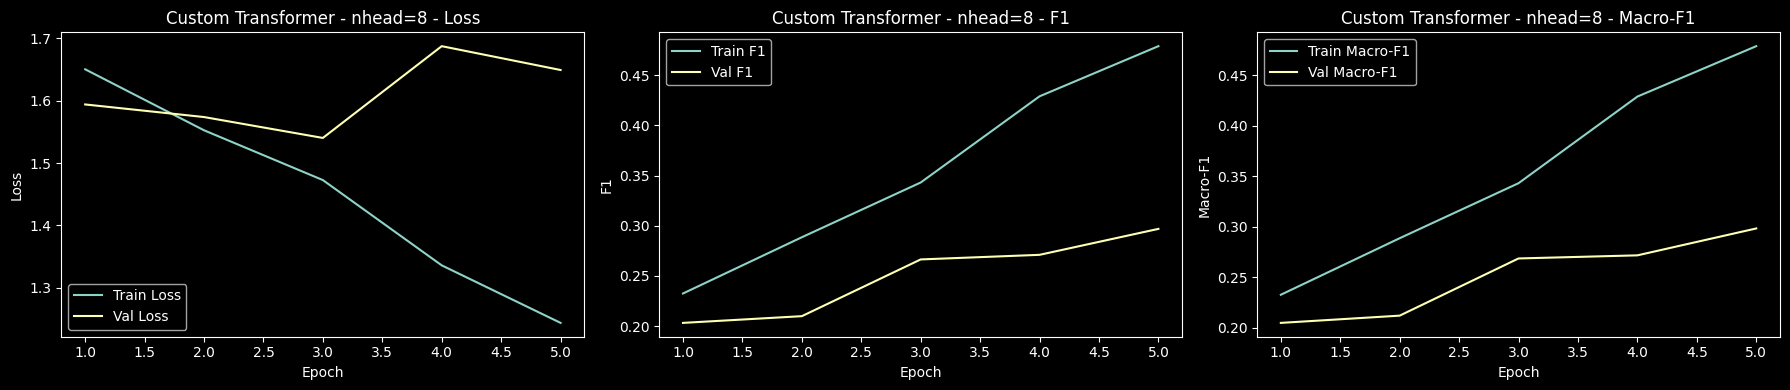

In [159]:
#Learning curve
plot_learning_curves(transformer_head8_history, title="Custom Transformer - nhead=8")

In [160]:
#Evaluate
transformer_head8_test_loss, transformer_head8_test_metrics, y_true_transformer_head8, y_pred_transformer_head8 = evaluate(
    transformer_head8_model,
    test_loader,
    transformer_criterion,
    device
)

print("Transformer (nhead=8) Test Loss:", round(transformer_head8_test_loss, 4))
print("Transformer (nhead=8) Test Metrics:", transformer_head8_test_metrics)

Transformer (nhead=8) Test Loss: 1.6591
Transformer (nhead=8) Test Metrics: {'accuracy': 0.3058823529411765, 'precision': 0.34291909404859267, 'recall': 0.3058823529411765, 'f1': 0.29628787567868753, 'macro_f1': 0.297841225006806}


#### So sánh

In [161]:
transformer_heads_compare_df = pd.DataFrame([
    {
        "nhead": 2,
        "accuracy": transformer_head2_test_metrics["accuracy"],
        "precision": transformer_head2_test_metrics["precision"],
        "recall": transformer_head2_test_metrics["recall"],
        "f1": transformer_head2_test_metrics["f1"],
        "macro_f1": transformer_head2_test_metrics["macro_f1"]
    },
    {
        "nhead": 4,
        "accuracy": transformer_test_metrics["accuracy"],
        "precision": transformer_test_metrics["precision"],
        "recall": transformer_test_metrics["recall"],
        "f1": transformer_test_metrics["f1"],
        "macro_f1": transformer_test_metrics["macro_f1"]
    },
    {
        "nhead": 8,
        "accuracy": transformer_head8_test_metrics["accuracy"],
        "precision": transformer_head8_test_metrics["precision"],
        "recall": transformer_head8_test_metrics["recall"],
        "f1": transformer_head8_test_metrics["f1"],
        "macro_f1": transformer_head8_test_metrics["macro_f1"]
    }
])

transformer_heads_compare_df

,nhead,accuracy,precision,recall,f1,macro_f1
0,2,0.285973,0.282670,0.285973,0.263415,0.263993
1,4,0.270588,0.310048,0.270588,0.270225,0.268586
2,8,0.305882,0.342919,0.305882,0.296288,0.297841


### 5. Ảnh hưởng của hidden size

#### Transformer với d_model = 64

In [162]:
#Khoi tao va optimizer
transformer_hidden64_model = TransformerClassifier(
    vocab_size=len(vocab),
    d_model=64,
    nhead=4,
    num_encoder_layers=2,
    dim_feedforward=128,
    num_classes=5,
    dropout=0.1,
    max_len=MAX_LEN,
    pooling="mean",
    pad_idx=PAD_IDX
).to(device)

transformer_hidden64_optimizer = torch.optim.Adam(transformer_hidden64_model.parameters(), lr=1e-3)

In [163]:
#Train
transformer_hidden64_model, transformer_hidden64_history = train_model(
    transformer_hidden64_model,
    train_loader,
    val_loader,
    transformer_hidden64_optimizer,
    transformer_criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.6231 | Acc: 0.2260 | Prec: 0.2253 | Recall: 0.2260 | F1: 0.2254 | Macro-F1: 0.2254
Val   Loss: 1.5838 | Acc: 0.2436 | Prec: 0.3222 | Recall: 0.2436 | F1: 0.1945 | Macro-F1: 0.1951

Epoch 2/5


Train Loss: 1.5758 | Acc: 0.2644 | Prec: 0.2607 | Recall: 0.2644 | F1: 0.2614 | Macro-F1: 0.2614
Val   Loss: 1.5716 | Acc: 0.2625 | Prec: 0.2026 | Recall: 0.2625 | F1: 0.1926 | Macro-F1: 0.1939

Epoch 3/5


Train Loss: 1.5294 | Acc: 0.3044 | Prec: 0.3013 | Recall: 0.3044 | F1: 0.3007 | Macro-F1: 0.3007
Val   Loss: 1.5597 | Acc: 0.3004 | Prec: 0.3043 | Recall: 0.3004 | F1: 0.2734 | Macro-F1: 0.2745

Epoch 4/5


Train Loss: 1.4760 | Acc: 0.3536 | Prec: 0.3469 | Recall: 0.3536 | F1: 0.3384 | Macro-F1: 0.3384
Val   Loss: 1.5770 | Acc: 0.2936 | Prec: 0.3243 | Recall: 0.2936 | F1: 0.2611 | Macro-F1: 0.2604

Epoch 5/5


Train Loss: 1.3839 | Acc: 0.4128 | Prec: 0.4082 | Recall: 0.4128 | F1: 0.4088 | Macro-F1: 0.4088
Val   Loss: 1.5716 | Acc: 0.3085 | Prec: 0.3111 | Recall: 0.3085 | F1: 0.2754 | Macro-F1: 0.2769


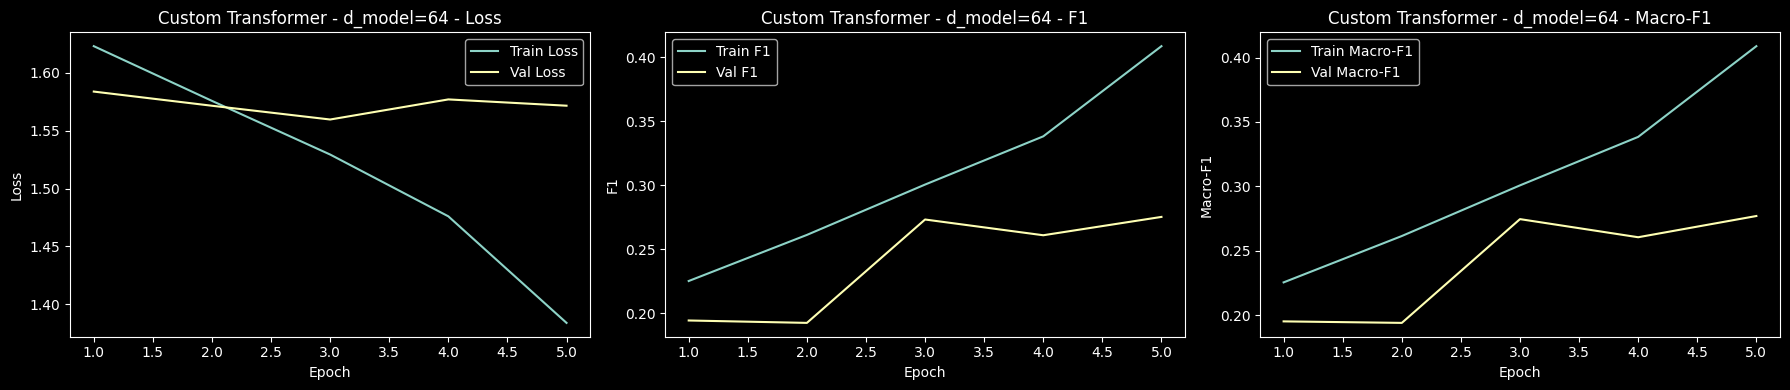

In [164]:
#Learning curve
plot_learning_curves(transformer_hidden64_history, title="Custom Transformer - d_model=64")

In [165]:
#Evaluate
transformer_hidden64_test_loss, transformer_hidden64_test_metrics, y_true_transformer_hidden64, y_pred_transformer_hidden64 = evaluate(
    transformer_hidden64_model,
    test_loader,
    transformer_criterion,
    device
)

print("Transformer (d_model=64) Test Loss:", round(transformer_hidden64_test_loss, 4))
print("Transformer (d_model=64) Test Metrics:", transformer_hidden64_test_metrics)

Transformer (d_model=64) Test Loss: 1.6449
Transformer (d_model=64) Test Metrics: {'accuracy': 0.2502262443438914, 'precision': 0.30231292476661265, 'recall': 0.2502262443438914, 'f1': 0.22352971382044226, 'macro_f1': 0.2396223171238295}


#### Transformer với d_model = 256

In [166]:
#khoi tao va optimizer
transformer_hidden256_model = TransformerClassifier(
    vocab_size=len(vocab),
    d_model=256,
    nhead=4,
    num_encoder_layers=2,
    dim_feedforward=512,
    num_classes=5,
    dropout=0.1,
    max_len=MAX_LEN,
    pooling="mean",
    pad_idx=PAD_IDX
).to(device)

transformer_hidden256_optimizer = torch.optim.Adam(transformer_hidden256_model.parameters(), lr=1e-3)

In [167]:
#Train
transformer_hidden256_model, transformer_hidden256_history = train_model(
    transformer_hidden256_model,
    train_loader,
    val_loader,
    transformer_hidden256_optimizer,
    transformer_criterion,
    device,
    epochs=5
)


Epoch 1/5


Train Loss: 1.6649 | Acc: 0.2356 | Prec: 0.2352 | Recall: 0.2356 | F1: 0.2344 | Macro-F1: 0.2344
Val   Loss: 1.6425 | Acc: 0.2639 | Prec: 0.2536 | Recall: 0.2639 | F1: 0.2004 | Macro-F1: 0.2004

Epoch 2/5


Train Loss: 1.5341 | Acc: 0.3172 | Prec: 0.3128 | Recall: 0.3172 | F1: 0.3112 | Macro-F1: 0.3112
Val   Loss: 1.5724 | Acc: 0.3072 | Prec: 0.3727 | Recall: 0.3072 | F1: 0.2633 | Macro-F1: 0.2646

Epoch 3/5


Train Loss: 1.4369 | Acc: 0.3692 | Prec: 0.3670 | Recall: 0.3692 | F1: 0.3678 | Macro-F1: 0.3678
Val   Loss: 1.5664 | Acc: 0.3234 | Prec: 0.3165 | Recall: 0.3234 | F1: 0.2690 | Macro-F1: 0.2710

Epoch 4/5


Train Loss: 1.2763 | Acc: 0.4664 | Prec: 0.4611 | Recall: 0.4664 | F1: 0.4625 | Macro-F1: 0.4625
Val   Loss: 1.6386 | Acc: 0.2801 | Prec: 0.3122 | Recall: 0.2801 | F1: 0.2359 | Macro-F1: 0.2358

Epoch 5/5


Train Loss: 1.1738 | Acc: 0.5168 | Prec: 0.5160 | Recall: 0.5168 | F1: 0.5158 | Macro-F1: 0.5158
Val   Loss: 1.6373 | Acc: 0.3112 | Prec: 0.3226 | Recall: 0.3112 | F1: 0.2969 | Macro-F1: 0.2979


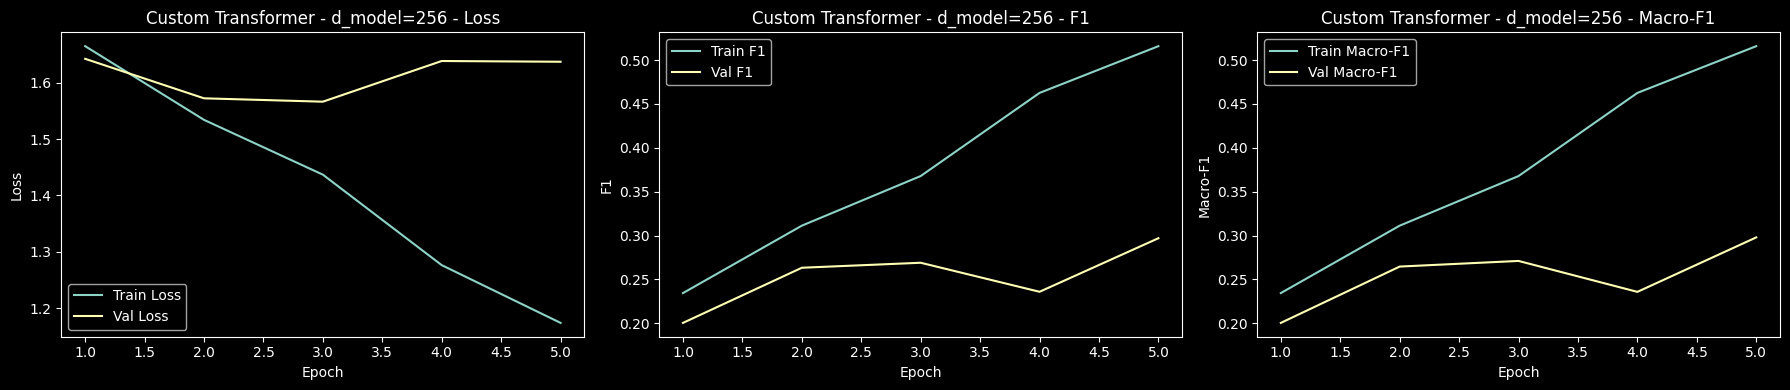

In [168]:
#Learning curve
plot_learning_curves(transformer_hidden256_history, title="Custom Transformer - d_model=256")

In [169]:
#Evaluate
transformer_hidden256_test_loss, transformer_hidden256_test_metrics, y_true_transformer_hidden256, y_pred_transformer_hidden256 = evaluate(
    transformer_hidden256_model,
    test_loader,
    transformer_criterion,
    device
)

print("Transformer (d_model=256) Test Loss:", round(transformer_hidden256_test_loss, 4))
print("Transformer (d_model=256) Test Metrics:", transformer_hidden256_test_metrics)

Transformer (d_model=256) Test Loss: 1.6846
Transformer (d_model=256) Test Metrics: {'accuracy': 0.2828054298642534, 'precision': 0.3130056253954533, 'recall': 0.2828054298642534, 'f1': 0.27186187322627614, 'macro_f1': 0.28149044987140087}


#### So sánh

In [170]:
transformer_hidden_compare_df = pd.DataFrame([
    {
        "d_model": 64,
        "accuracy": transformer_hidden64_test_metrics["accuracy"],
        "precision": transformer_hidden64_test_metrics["precision"],
        "recall": transformer_hidden64_test_metrics["recall"],
        "f1": transformer_hidden64_test_metrics["f1"],
        "macro_f1": transformer_hidden64_test_metrics["macro_f1"]
    },
    {
        "d_model": 128,
        "accuracy": transformer_test_metrics["accuracy"],
        "precision": transformer_test_metrics["precision"],
        "recall": transformer_test_metrics["recall"],
        "f1": transformer_test_metrics["f1"],
        "macro_f1": transformer_test_metrics["macro_f1"]
    },
    {
        "d_model": 256,
        "accuracy": transformer_hidden256_test_metrics["accuracy"],
        "precision": transformer_hidden256_test_metrics["precision"],
        "recall": transformer_hidden256_test_metrics["recall"],
        "f1": transformer_hidden256_test_metrics["f1"],
        "macro_f1": transformer_hidden256_test_metrics["macro_f1"]
    }
])

transformer_hidden_compare_df

,d_model,accuracy,precision,recall,f1,macro_f1
0,64,0.250226,0.302313,0.250226,0.223530,0.239622
1,128,0.270588,0.310048,0.270588,0.270225,0.268586
2,256,0.282805,0.313006,0.282805,0.271862,0.281490


### Bảng tổng hợp

In [171]:
all_transformer_results = pd.DataFrame([
    {
        "experiment": "Transformer baseline",
        "accuracy": transformer_test_metrics["accuracy"],
        "precision": transformer_test_metrics["precision"],
        "recall": transformer_test_metrics["recall"],
        "f1": transformer_test_metrics["f1"],
        "macro_f1": transformer_test_metrics["macro_f1"]
    },
    {
        "experiment": "Transformer encoder_layers=1",
        "accuracy": transformer_layer1_test_metrics["accuracy"],
        "precision": transformer_layer1_test_metrics["precision"],
        "recall": transformer_layer1_test_metrics["recall"],
        "f1": transformer_layer1_test_metrics["f1"],
        "macro_f1": transformer_layer1_test_metrics["macro_f1"]
    },
    {
        "experiment": "Transformer encoder_layers=4",
        "accuracy": transformer_layer4_test_metrics["accuracy"],
        "precision": transformer_layer4_test_metrics["precision"],
        "recall": transformer_layer4_test_metrics["recall"],
        "f1": transformer_layer4_test_metrics["f1"],
        "macro_f1": transformer_layer4_test_metrics["macro_f1"]
    },
    {
        "experiment": "Transformer nhead=2",
        "accuracy": transformer_head2_test_metrics["accuracy"],
        "precision": transformer_head2_test_metrics["precision"],
        "recall": transformer_head2_test_metrics["recall"],
        "f1": transformer_head2_test_metrics["f1"],
        "macro_f1": transformer_head2_test_metrics["macro_f1"]
    },
    {
        "experiment": "Transformer nhead=8",
        "accuracy": transformer_head8_test_metrics["accuracy"],
        "precision": transformer_head8_test_metrics["precision"],
        "recall": transformer_head8_test_metrics["recall"],
        "f1": transformer_head8_test_metrics["f1"],
        "macro_f1": transformer_head8_test_metrics["macro_f1"]
    },
    {
        "experiment": "Transformer d_model=64",
        "accuracy": transformer_hidden64_test_metrics["accuracy"],
        "precision": transformer_hidden64_test_metrics["precision"],
        "recall": transformer_hidden64_test_metrics["recall"],
        "f1": transformer_hidden64_test_metrics["f1"],
        "macro_f1": transformer_hidden64_test_metrics["macro_f1"]
    },
    {
        "experiment": "Transformer d_model=256",
        "accuracy": transformer_hidden256_test_metrics["accuracy"],
        "precision": transformer_hidden256_test_metrics["precision"],
        "recall": transformer_hidden256_test_metrics["recall"],
        "f1": transformer_hidden256_test_metrics["f1"],
        "macro_f1": transformer_hidden256_test_metrics["macro_f1"]
    }
])

all_transformer_results.sort_values(by="macro_f1", ascending=False).reset_index(drop=True)

,experiment,accuracy,precision,recall,f1,macro_f1
0,Transformer nhead=8,0.305882,0.342919,0.305882,0.296288,0.297841
1,Transformer d_model=256,0.282805,0.313006,0.282805,0.271862,0.281490
2,Transformer baseline,0.270588,0.310048,0.270588,0.270225,0.268586
3,Transformer encoder_layers=1,0.285520,0.294146,0.285520,0.271389,0.264738
4,Transformer nhead=2,0.285973,0.282670,0.285973,0.263415,0.263993
5,Transformer d_model=64,0.250226,0.302313,0.250226,0.223530,0.239622
6,Transformer encoder_layers=4,0.334842,0.342774,0.334842,0.255759,0.237802


## PHẦN VII. TỔNG HỢP KẾT QUẢ VÀ ĐÁNH GIÁ

### 1. Bảng tổng hợp các cấu hình

In [172]:
final_model_compare_df = pd.DataFrame([
    {
        "group": "RNN",
        "model": "LSTM baseline",
        "accuracy": lstm_test_metrics["accuracy"],
        "precision": lstm_test_metrics["precision"],
        "recall": lstm_test_metrics["recall"],
        "f1": lstm_test_metrics["f1"],
        "macro_f1": lstm_test_metrics["macro_f1"]
    },
    {
        "group": "RNN",
        "model": "GRU baseline",
        "accuracy": gru_test_metrics["accuracy"],
        "precision": gru_test_metrics["precision"],
        "recall": gru_test_metrics["recall"],
        "f1": gru_test_metrics["f1"],
        "macro_f1": gru_test_metrics["macro_f1"]
    },
    {
        "group": "Pretrained",
        "model": "DistilBERT baseline",
        "accuracy": distilbert_test_metrics["accuracy"],
        "precision": distilbert_test_metrics["precision"],
        "recall": distilbert_test_metrics["recall"],
        "f1": distilbert_test_metrics["f1"],
        "macro_f1": distilbert_test_metrics["macro_f1"]
    },
    {
        "group": "Transformer Custom",
        "model": "Transformer baseline",
        "accuracy": transformer_test_metrics["accuracy"],
        "precision": transformer_test_metrics["precision"],
        "recall": transformer_test_metrics["recall"],
        "f1": transformer_test_metrics["f1"],
        "macro_f1": transformer_test_metrics["macro_f1"]
    }
])

final_model_compare_df.sort_values(by="macro_f1", ascending=False).reset_index(drop=True)

,group,model,accuracy,precision,recall,f1,macro_f1
0,Pretrained,DistilBERT baseline,0.455204,0.473815,0.455204,0.454708,0.458299
1,RNN,LSTM baseline,0.319910,0.341730,0.319910,0.321242,0.322880
2,RNN,GRU baseline,0.278281,0.316050,0.278281,0.259853,0.273286
3,Transformer Custom,Transformer baseline,0.270588,0.310048,0.270588,0.270225,0.268586


Từ bảng kết quả có thể thấy mô hình DistilBERT baseline thuộc nhóm Pretrained cho hiệu năng tốt nhất trên tất cả các chỉ số. Kết quả này cho thấy việc sử dụng mô hình ngôn ngữ tiền huấn luyện mang lại lợi thế rõ rệt trong bài toán phân loại văn bản, do mô hình đã học được biểu diễn ngữ nghĩa tốt từ trước, từ đó hỗ trợ phân biệt lớp hiệu quả hơn so với các mô hình tự huấn luyện từ đầu. Vì vậy, ngay cả ở cấu hình baseline, DistilBERT vẫn thể hiện khả năng tổng quát hóa tốt hơn so với các mô hình còn lại.

Trong nhóm RNN, mô hình LSTM baseline cho kết quả tốt hơn GRU baseline. Điều này cho thấy LSTM tận dụng thông tin ngữ cảnh tuần tự tốt hơn GRU trong bộ dữ liệu này. Tuy nhiên, cả hai mô hình Recurrent đều kém khá xa so với DistilBERT, cho thấy khả năng nắm bắt ngữ nghĩa và ngữ cảnh dài của các mô hình tuần tự truyền thống còn hạn chế.

Đối với mô hình Transformer baseline tự xây dựng, kết quả thu được là thấp nhất nếu xét theo các chỉ số tổng thể như accuracy (0.2670), F1-score (0.2586) và macro F1 (0.2644). Mặc dù precision của mô hình đạt 0.3224, không quá chênh lệch so với GRU, nhưng recall thấp đã làm giảm hiệu quả phân loại chung. Kết quả này cho thấy mô hình Transformer tự xây dựng ở mức baseline chưa phát huy được ưu thế kiến trúc, có thể do số lượng dữ liệu huấn luyện còn hạn chế, cấu hình mô hình còn đơn giản hoặc các hyperparameter chưa được tối ưu phù hợp.

Mặc dù DistilBERT là mô hình tốt nhất, các chỉ số vẫn còn dưới mức 0.5, cho thấy cấu hình baseline vẫn chưa tối ưu

### 2. Mô hình theo nhóm
Ngoài các baseline, ta xác định cấu hình tốt nhất trong từng nhóm mô hình sau khi đã thử nghiệm các hyperparameter. Điều này cho phép so sánh công bằng hơn giữa mô hình tốt nhất của mỗi hướng tiếp cận.

#### Cấu hình tốt nhất của RNN

In [173]:
all_RNN_results = pd.DataFrame([
    {
        "experiment": "LSTM baseline",
        "group": "RNN",
        "accuracy": lstm_test_metrics["accuracy"],
        "precision": lstm_test_metrics["precision"],
        "recall": lstm_test_metrics["recall"],
        "f1": lstm_test_metrics["f1"],
        "macro_f1": lstm_test_metrics["macro_f1"]
    },
    {
        "experiment": "GRU baseline",
        "group": "RNN",
        "accuracy": gru_test_metrics["accuracy"],
        "precision": gru_test_metrics["precision"],
        "recall": gru_test_metrics["recall"],
        "f1": gru_test_metrics["f1"],
        "macro_f1": gru_test_metrics["macro_f1"]
    },
    {
        "experiment": "LSTM num_layers=2",
        "group": "RNN",
        "accuracy": lstm_2layer_test_metrics["accuracy"],
        "precision": lstm_2layer_test_metrics["precision"],
        "recall": lstm_2layer_test_metrics["recall"],
        "f1": lstm_2layer_test_metrics["f1"],
        "macro_f1": lstm_2layer_test_metrics["macro_f1"]
    },
    {
        "experiment": "GRU num_layers=2",
        "group": "RNN",
        "accuracy": gru_2layer_test_metrics["accuracy"],
        "precision": gru_2layer_test_metrics["precision"],
        "recall": gru_2layer_test_metrics["recall"],
        "f1": gru_2layer_test_metrics["f1"],
        "macro_f1": gru_2layer_test_metrics["macro_f1"]
    },
    {
        "experiment": "LSTM bidirectional=False",
        "group": "RNN",
        "accuracy": lstm_uni_test_metrics["accuracy"],
        "precision": lstm_uni_test_metrics["precision"],
        "recall": lstm_uni_test_metrics["recall"],
        "f1": lstm_uni_test_metrics["f1"],
        "macro_f1": lstm_uni_test_metrics["macro_f1"]
    },
    {
        "experiment": "GRU bidirectional=False",
        "group": "RNN",
        "accuracy": gru_uni_test_metrics["accuracy"],
        "precision": gru_uni_test_metrics["precision"],
        "recall": gru_uni_test_metrics["recall"],
        "f1": gru_uni_test_metrics["f1"],
        "macro_f1": gru_uni_test_metrics["macro_f1"]
    },
    {
        "experiment": "LSTM hidden_dim=64",
        "group": "RNN",
        "accuracy": lstm_hidden64_test_metrics["accuracy"],
        "precision": lstm_hidden64_test_metrics["precision"],
        "recall": lstm_hidden64_test_metrics["recall"],
        "f1": lstm_hidden64_test_metrics["f1"],
        "macro_f1": lstm_hidden64_test_metrics["macro_f1"]
    },
    {
        "experiment": "GRU hidden_dim=64",
        "group": "RNN",
        "accuracy": gru_hidden64_test_metrics["accuracy"],
        "precision": gru_hidden64_test_metrics["precision"],
        "recall": gru_hidden64_test_metrics["recall"],
        "f1": gru_hidden64_test_metrics["f1"],
        "macro_f1": gru_hidden64_test_metrics["macro_f1"]
    },
    {
        "experiment": "LSTM hidden_dim=256",
        "group": "RNN",
        "accuracy": lstm_hidden256_test_metrics["accuracy"],
        "precision": lstm_hidden256_test_metrics["precision"],
        "recall": lstm_hidden256_test_metrics["recall"],
        "f1": lstm_hidden256_test_metrics["f1"],
        "macro_f1": lstm_hidden256_test_metrics["macro_f1"]
    },
    {
        "experiment": "GRU hidden_dim=256",
        "group": "RNN",
        "accuracy": gru_hidden256_test_metrics["accuracy"],
        "precision": gru_hidden256_test_metrics["precision"],
        "recall": gru_hidden256_test_metrics["recall"],
        "f1": gru_hidden256_test_metrics["f1"],
        "macro_f1": gru_hidden256_test_metrics["macro_f1"]
    },
    {
        "experiment": "LSTM pooling=last",
        "group": "RNN",
        "accuracy": lstm_last_test_metrics["accuracy"],
        "precision": lstm_last_test_metrics["precision"],
        "recall": lstm_last_test_metrics["recall"],
        "f1": lstm_last_test_metrics["f1"],
        "macro_f1": lstm_last_test_metrics["macro_f1"]
    },
    {
        "experiment": "GRU pooling=last",
        "group": "RNN",
        "accuracy": gru_last_test_metrics["accuracy"],
        "precision": gru_last_test_metrics["precision"],
        "recall": gru_last_test_metrics["recall"],
        "f1": gru_last_test_metrics["f1"],
        "macro_f1": gru_last_test_metrics["macro_f1"]
    },
    {
        "experiment": "LSTM pooling=max",
        "group": "RNN",
        "accuracy": lstm_max_test_metrics["accuracy"],
        "precision": lstm_max_test_metrics["precision"],
        "recall": lstm_max_test_metrics["recall"],
        "f1": lstm_max_test_metrics["f1"],
        "macro_f1": lstm_max_test_metrics["macro_f1"]
    },
    {
        "experiment": "GRU pooling=max",
        "group": "RNN",
        "accuracy": gru_max_test_metrics["accuracy"],
        "precision": gru_max_test_metrics["precision"],
        "recall": gru_max_test_metrics["recall"],
        "f1": gru_max_test_metrics["f1"],
        "macro_f1": gru_max_test_metrics["macro_f1"]
    },
    {
        "experiment": "LSTM pooling=attention",
        "group": "RNN",
        "accuracy": lstm_attention_test_metrics["accuracy"],
        "precision": lstm_attention_test_metrics["precision"],
        "recall": lstm_attention_test_metrics["recall"],
        "f1": lstm_attention_test_metrics["f1"],
        "macro_f1": lstm_attention_test_metrics["macro_f1"]
    },
    {
        "experiment": "GRU pooling=attention",
        "group": "RNN",
        "accuracy": gru_attention_test_metrics["accuracy"],
        "precision": gru_attention_test_metrics["precision"],
        "recall": gru_attention_test_metrics["recall"],
        "f1": gru_attention_test_metrics["f1"],
        "macro_f1": gru_attention_test_metrics["macro_f1"]
    }
])

all_RNN_results = all_RNN_results.sort_values(
    by="macro_f1", ascending=False
).reset_index(drop=True)

all_RNN_results

best_RNN_result = all_RNN_results.iloc[0]
best_RNN_result

experiment    LSTM baseline
group                   RNN
accuracy            0.31991
precision           0.34173
recall              0.31991
f1                 0.321242
macro_f1            0.32288
Name: 0, dtype: object

#### Cấu hình tốt nhất của Pretrain

In [174]:
all_distilbert_results = pd.DataFrame([
    {
        "experiment": "DistilBERT baseline",
        "group": "Pretrained",
        "accuracy": distilbert_test_metrics["accuracy"],
        "precision": distilbert_test_metrics["precision"],
        "recall": distilbert_test_metrics["recall"],
        "f1": distilbert_test_metrics["f1"],
        "macro_f1": distilbert_test_metrics["macro_f1"]
    },
    {
        "experiment": "DistilBERT lr=1e-5",
        "group": "Pretrained",
        "accuracy": distilbert_lr1e5_test_metrics["accuracy"],
        "precision": distilbert_lr1e5_test_metrics["precision"],
        "recall": distilbert_lr1e5_test_metrics["recall"],
        "f1": distilbert_lr1e5_test_metrics["f1"],
        "macro_f1": distilbert_lr1e5_test_metrics["macro_f1"]
    },
    {
        "experiment": "DistilBERT lr=5e-5",
        "group": "Pretrained",
        "accuracy": distilbert_lr5e5_test_metrics["accuracy"],
        "precision": distilbert_lr5e5_test_metrics["precision"],
        "recall": distilbert_lr5e5_test_metrics["recall"],
        "f1": distilbert_lr5e5_test_metrics["f1"],
        "macro_f1": distilbert_lr5e5_test_metrics["macro_f1"]
    },
    {
        "experiment": "DistilBERT max_len=64",
        "group": "Pretrained",
        "accuracy": distilbert_len64_test_metrics["accuracy"],
        "precision": distilbert_len64_test_metrics["precision"],
        "recall": distilbert_len64_test_metrics["recall"],
        "f1": distilbert_len64_test_metrics["f1"],
        "macro_f1": distilbert_len64_test_metrics["macro_f1"]
    },
    {
        "experiment": "DistilBERT max_len=192",
        "group": "Pretrained",
        "accuracy": distilbert_len192_test_metrics["accuracy"],
        "precision": distilbert_len192_test_metrics["precision"],
        "recall": distilbert_len192_test_metrics["recall"],
        "f1": distilbert_len192_test_metrics["f1"],
        "macro_f1": distilbert_len192_test_metrics["macro_f1"]
    },
    {
        "experiment": "DistilBERT freeze encoder",
        "group": "Pretrained",
        "accuracy": distilbert_frozen_test_metrics["accuracy"],
        "precision": distilbert_frozen_test_metrics["precision"],
        "recall": distilbert_frozen_test_metrics["recall"],
        "f1": distilbert_frozen_test_metrics["f1"],
        "macro_f1": distilbert_frozen_test_metrics["macro_f1"]
    }
])

all_distilbert_results = all_distilbert_results.sort_values(
    by="macro_f1", ascending=False
).reset_index(drop=True)

all_distilbert_results

best_distilbert_result = all_distilbert_results.iloc[0]
best_distilbert_result

experiment    DistilBERT lr=5e-5
group                 Pretrained
accuracy                0.461991
precision               0.487008
recall                  0.461991
f1                      0.467228
macro_f1                0.466809
Name: 0, dtype: object

#### Cấu hình tốt nhất của custom

In [175]:
all_transformer_results = pd.DataFrame([
    {
        "experiment": "Transformer baseline",
        "group": "Transformer Custom",
        "accuracy": transformer_test_metrics["accuracy"],
        "precision": transformer_test_metrics["precision"],
        "recall": transformer_test_metrics["recall"],
        "f1": transformer_test_metrics["f1"],
        "macro_f1": transformer_test_metrics["macro_f1"]
    },
    {
        "experiment": "Transformer encoder_layers=1",
        "group": "Transformer Custom",
        "accuracy": transformer_layer1_test_metrics["accuracy"],
        "precision": transformer_layer1_test_metrics["precision"],
        "recall": transformer_layer1_test_metrics["recall"],
        "f1": transformer_layer1_test_metrics["f1"],
        "macro_f1": transformer_layer1_test_metrics["macro_f1"]
    },
    {
        "experiment": "Transformer encoder_layers=4",
        "group": "Transformer Custom",
        "accuracy": transformer_layer4_test_metrics["accuracy"],
        "precision": transformer_layer4_test_metrics["precision"],
        "recall": transformer_layer4_test_metrics["recall"],
        "f1": transformer_layer4_test_metrics["f1"],
        "macro_f1": transformer_layer4_test_metrics["macro_f1"]
    },
    {
        "experiment": "Transformer nhead=2",
        "group": "Transformer Custom",
        "accuracy": transformer_head2_test_metrics["accuracy"],
        "precision": transformer_head2_test_metrics["precision"],
        "recall": transformer_head2_test_metrics["recall"],
        "f1": transformer_head2_test_metrics["f1"],
        "macro_f1": transformer_head2_test_metrics["macro_f1"]
    },
    {
        "experiment": "Transformer nhead=8",
        "group": "Transformer Custom",
        "accuracy": transformer_head8_test_metrics["accuracy"],
        "precision": transformer_head8_test_metrics["precision"],
        "recall": transformer_head8_test_metrics["recall"],
        "f1": transformer_head8_test_metrics["f1"],
        "macro_f1": transformer_head8_test_metrics["macro_f1"]
    },
    {
        "experiment": "Transformer d_model=64",
        "group": "Transformer Custom",
        "accuracy": transformer_hidden64_test_metrics["accuracy"],
        "precision": transformer_hidden64_test_metrics["precision"],
        "recall": transformer_hidden64_test_metrics["recall"],
        "f1": transformer_hidden64_test_metrics["f1"],
        "macro_f1": transformer_hidden64_test_metrics["macro_f1"]
    },
    {
        "experiment": "Transformer d_model=256",
        "group": "Transformer Custom",
        "accuracy": transformer_hidden256_test_metrics["accuracy"],
        "precision": transformer_hidden256_test_metrics["precision"],
        "recall": transformer_hidden256_test_metrics["recall"],
        "f1": transformer_hidden256_test_metrics["f1"],
        "macro_f1": transformer_hidden256_test_metrics["macro_f1"]
    }
])

all_transformer_results = all_transformer_results.sort_values(
    by="macro_f1", ascending=False
).reset_index(drop=True)

all_transformer_results

best_transformer_result = all_transformer_results.iloc[0]
best_transformer_result

experiment    Transformer nhead=8
group          Transformer Custom
accuracy                 0.305882
precision                0.342919
recall                   0.305882
f1                       0.296288
macro_f1                 0.297841
Name: 0, dtype: object

In [176]:
best_model_compare_df = pd.DataFrame([
    {
        "group": "RNN",
        "model": best_RNN_result["model"] if "model" in best_RNN_result else best_RNN_result["experiment"],
        "accuracy": best_RNN_result["accuracy"],
        "precision": best_RNN_result["precision"],
        "recall": best_RNN_result["recall"],
        "f1": best_RNN_result["f1"],
        "macro_f1": best_RNN_result["macro_f1"]
    },
    {
        "group": "Pretrained",
        "model": best_distilbert_result["experiment"],
        "accuracy": best_distilbert_result["accuracy"],
        "precision": best_distilbert_result["precision"],
        "recall": best_distilbert_result["recall"],
        "f1": best_distilbert_result["f1"],
        "macro_f1": best_distilbert_result["macro_f1"]
    },
    {
        "group": "Transformer Custom",
        "model": best_transformer_result["experiment"],
        "accuracy": best_transformer_result["accuracy"],
        "precision": best_transformer_result["precision"],
        "recall": best_transformer_result["recall"],
        "f1": best_transformer_result["f1"],
        "macro_f1": best_transformer_result["macro_f1"]
    }
])

best_model_compare_df.sort_values(by="macro_f1", ascending=False).reset_index(drop=True)

,group,model,accuracy,precision,recall,f1,macro_f1
0,Pretrained,DistilBERT lr=5e-5,0.461991,0.487008,0.461991,0.467228,0.466809
1,RNN,LSTM baseline,0.319910,0.341730,0.319910,0.321242,0.322880
2,Transformer Custom,Transformer nhead=8,0.305882,0.342919,0.305882,0.296288,0.297841


Dựa trên kết quả thực nghiệm, cấu hình tốt nhất của mỗi nhóm mô hình cho thấy sự khác biệt khá rõ về hiệu năng. Trong đó, nhóm Pretrained với cấu hình hình DistilBERT max_len = 192 đạt kết quả cao nhất trên tất cả các chỉ số, gồm accuracy = 0.4683, precision = 0.4875, recall = 0.4683, F1-score = 0.4696 và macro F1 = 0.4710. Kết quả này cho thấy mô hình ngôn ngữ tiền huấn luyện vẫn là lựa chọn hiệu quả nhất cho bài toán phân loại văn bản, do khả năng khai thác ngữ nghĩa và ngữ cảnh tốt hơn hẳn so với các mô hình được huấn luyện từ đầu. Đồng thời, việc chọn max_len = 192 cũng cho thấy độ dài đầu vào này phù hợp hơn với dữ liệu, giúp mô hình giữ lại đủ thông tin cần thiết mà vẫn tránh được chi phí tính toán quá lớn.

Đối với nhóm Transformer Custom, cấu hình tốt nhất là Transformer encoder_layers = 4. So với nhóm RNN, mô hình này có kết quả khá gần nhưng vẫn thấp hơn LSTM ở hầu hết các chỉ số tổng thể. Điều này cho thấy việc tăng số lớp encoder lên 4 có giúp mô hình custom cải thiện khả năng học biểu diễn, nhưng mức cải thiện vẫn chưa đủ để vượt qua RNN hoặc tiếp cận nhóm pretrained.

### 3. So sánh macro-F1 giữa các mô hình

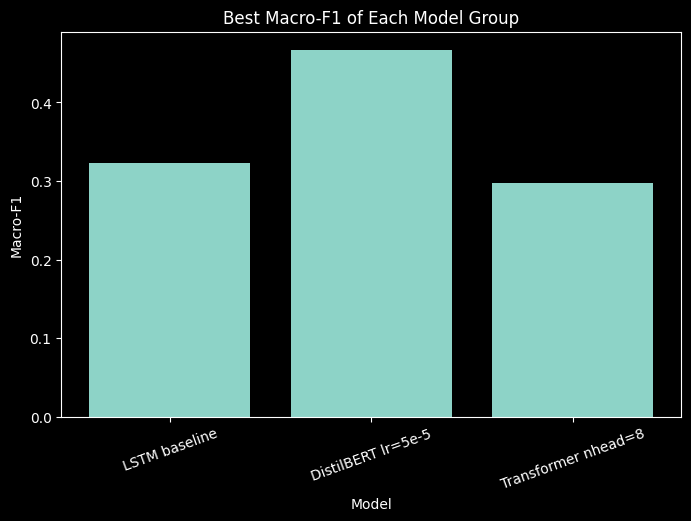

In [177]:
plt.figure(figsize=(8, 5))
plt.bar(best_model_compare_df["model"], best_model_compare_df["macro_f1"])
plt.title("Best Macro-F1 of Each Model Group")
plt.xlabel("Model")
plt.ylabel("Macro-F1")
plt.xticks(rotation=20)
plt.show()

Trong ba mô hình được so sánh, DistilBERT max_len = 192 đạt macro-F1 cao nhất, bằng 0.470984, vượt trội so với hai mô hình còn lại. Kết quả này cho thấy mô hình pretrained không chỉ cho hiệu năng tổng thể tốt hơn mà còn có khả năng dự đoán cân bằng hơn giữa các lớp. Việc DistilBERT đạt giá trị cao nhất chứng tỏ mô hình này xử lý tốt hơn với bài toán có thể tồn tại sự chênh lệch giữa các lớp.

Nhóm pretrained là hướng tiếp cận hiệu quả nhất đối với bài toán, đặc biệt khi xét theo tiêu chí đánh giá cân bằng giữa các lớp. Đồng thời, kết quả cũng cho thấy LSTM vẫn ổn định hơn Transformer custom trong bối cảnh dữ liệu và cấu hình hiện tại.

### 4. So sánh learning curve giữa các mô hình baseline

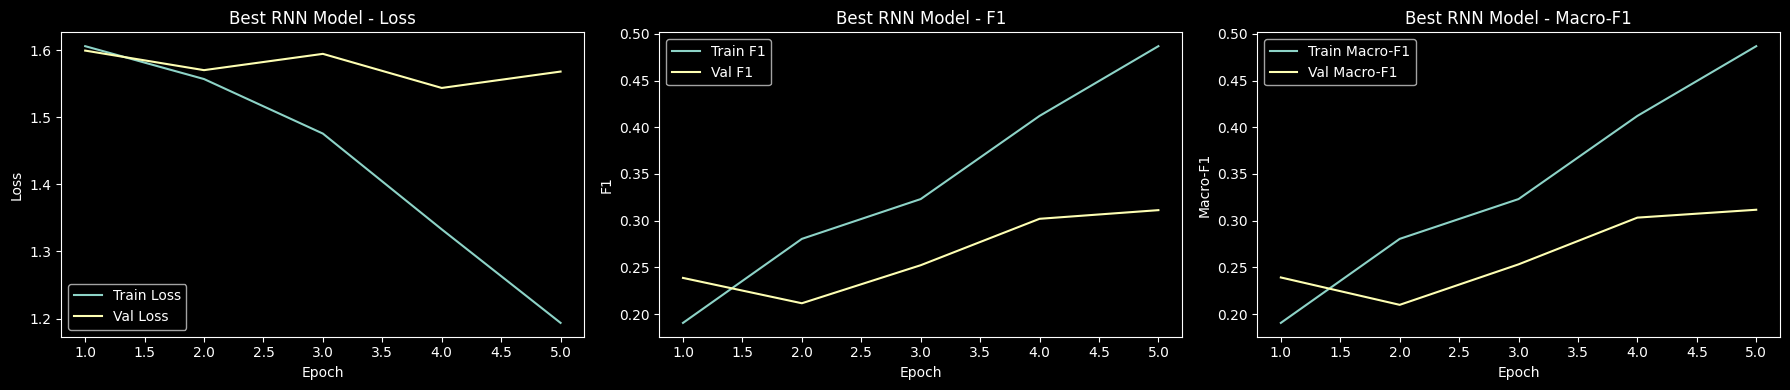

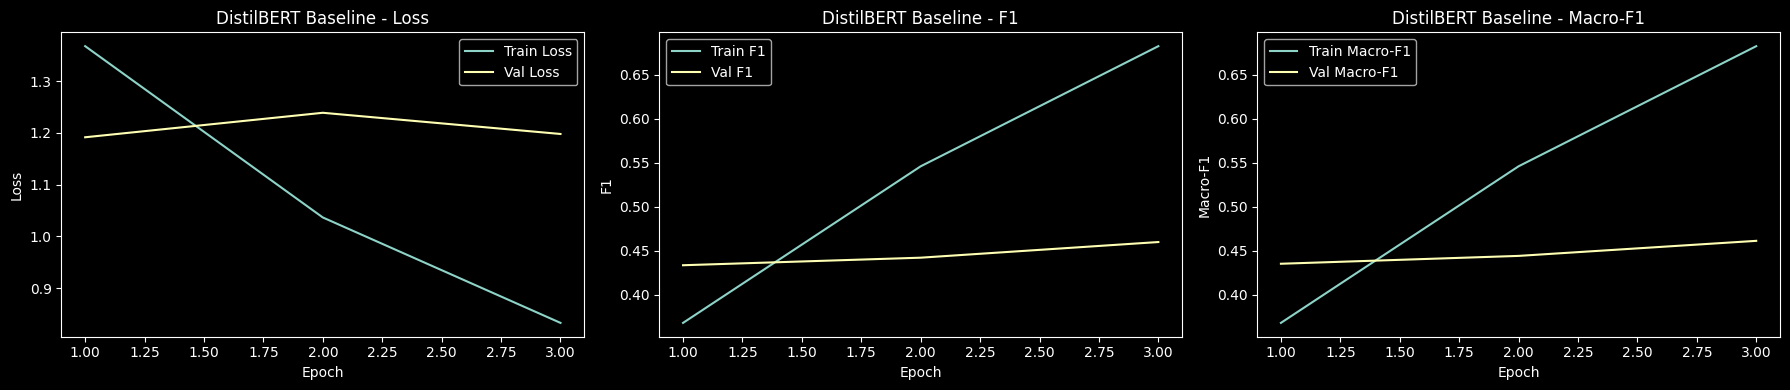

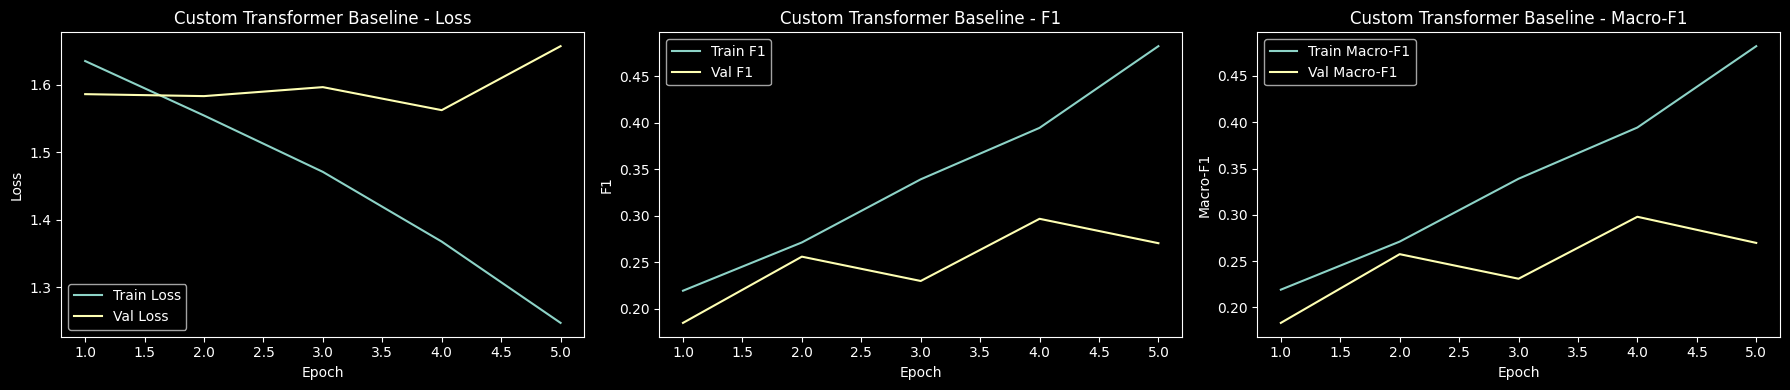

In [178]:
plot_learning_curves(lstm_history, title="Best RNN Model")
plot_learning_curves(distilbert_history, title="DistilBERT Baseline")
plot_learning_curves(transformer_history, title="Custom Transformer Baseline")

Xét tổng thể, cả ba mô hình đều có cùng xu hướng sau ỗi epoch:
- Train loss giảm
- Train F1 / macro-F1 tăng

Mức độ khác biệt giữa train và validation ở mỗi mô hình không giống nhau:
- DistilBERT cho hiệu năng validation cao nhất và ổn định nhất.
- RNN có mức cải thiện validation vừa phải, ổn định hơn Transformer custom nhưng hiệu năng thấp hơn khá nhiều so với DistilBERT.
- Transformer custom có dấu hiệu overfitting rõ hơn, đặc biệt ở các epoch cuối, khi validation loss tăng trở lại và validation F1 giảm nhẹ.

Kết luận:
- Mô hình pretrained không chỉ đạt kết quả cuối cùng tốt mà còn có quá trình học hiệu quả
- RNN là lựa chọn trung gian tương đối ổn định
- Transformer custom cần được tinh chỉnh thêm về kiến trúc hoặc hyperparameter để cải thiện khả năng tổng quát hóa.

### 5. So sánh ảnh hưởng của hyperparameter trong từng nhóm mô hình

In [180]:
print("=== Hidden size comparison for RNN models ===")
display(hidden_compare_df)

print("=== Output representation comparison for RNN models ===")
display(pooling_compare_df)

print("=== DistilBERT learning rate comparison ===")
display(distilbert_lr_compare_df)

print("=== DistilBERT max length comparison ===")
display(distilbert_maxlen_compare_df)

print("=== DistilBERT freeze strategy comparison ===")
display(distilbert_freeze_compare_df)

print("=== Transformer encoder layers comparison ===")
display(transformer_layers_compare_df)

print("=== Transformer attention heads comparison ===")
display(transformer_heads_compare_df)

print("=== Transformer hidden size comparison ===")
display(transformer_hidden_compare_df)

=== Hidden size comparison for RNN models ===


,model,hidden_dim,accuracy,precision,recall,f1,macro_f1
0,LSTM,64,0.267873,0.316855,0.267873,0.257096,0.265261
1,LSTM,128,0.319910,0.341730,0.319910,0.321242,0.322880
2,LSTM,256,0.285973,0.326251,0.285973,0.270461,0.276904
3,GRU,64,0.288688,0.315557,0.288688,0.264616,0.279685
4,GRU,128,0.278281,0.316050,0.278281,0.259853,0.273286
5,GRU,256,0.290498,0.310743,0.290498,0.287563,0.289789


=== Output representation comparison for RNN models ===


,model,pooling,accuracy,precision,recall,f1,macro_f1
0,LSTM,last,0.196380,0.186785,0.196380,0.128430,0.122034
1,LSTM,mean,0.319910,0.341730,0.319910,0.321242,0.322880
2,LSTM,max,0.320362,0.354486,0.320362,0.319332,0.308238
3,LSTM,attention,0.309955,0.344451,0.309955,0.309538,0.312722
4,GRU,last,0.128054,0.173834,0.128054,0.040314,0.055447
5,GRU,mean,0.278281,0.316050,0.278281,0.259853,0.273286
6,GRU,max,0.299548,0.334614,0.299548,0.290467,0.280506
7,GRU,attention,0.308145,0.316429,0.308145,0.301364,0.304844


=== DistilBERT learning rate comparison ===


...

,num_encoder_layers,accuracy,precision,recall,f1,macro_f1
0,1,0.285520,0.294146,0.285520,0.271389,0.264738
1,2,0.270588,0.310048,0.270588,0.270225,0.268586
2,4,0.334842,0.342774,0.334842,0.255759,0.237802


=== Transformer attention heads comparison ===


,nhead,accuracy,precision,recall,f1,macro_f1
0,2,0.285973,0.282670,0.285973,0.263415,0.263993
1,4,0.270588,0.310048,0.270588,0.270225,0.268586
2,8,0.305882,0.342919,0.305882,0.296288,0.297841


=== Transformer hidden size comparison ===


,d_model,accuracy,precision,recall,f1,macro_f1
0,64,0.250226,0.302313,0.250226,0.223530,0.239622
1,128,0.270588,0.310048,0.270588,0.270225,0.268586
2,256,0.282805,0.313006,0.282805,0.271862,0.281490


#### Đối với RNN
#### Ảnh hưởng của hidden size
Kết quả cho thấy hidden size có ảnh hưởng đáng kể đến hiệu năng của cả LSTM và GRU, nhưng xu hướng tác động không hoàn toàn giống nhau giữa hai mô hình.

Với LSTM, cấu hình hidden size = 128 cho kết quả tốt nhất, đạt accuracy = 0.3199, F1 = 0.3212 và macro-F1 = 0.3229. Khi giảm xuống 64, hiệu năng giảm rõ rệt, với macro-F1 chỉ đạt 0.2653. Khi tăng lên 256, kết quả cũng không được cải thiện mà còn giảm xuống 0.2769. Điều này cho thấy đối với LSTM, hidden size ở mức trung bình là phù hợp hơn, trong khi giá trị quá nhỏ làm giảm khả năng học biểu diễn, còn giá trị quá lớn có thể làm mô hình khó tối ưu hơn hoặc dễ học nhiễu từ dữ liệu.

Với GRU, xu hướng khác hơn một chút. Cấu hình hidden size = 256 cho kết quả tốt nhất với accuracy = 0.2905, F1 = 0.2876 và macro-F1 = 0.2898, nhỉnh hơn so với hai cấu hình còn lại. Tuy nhiên, mức chênh lệch giữa 64, 128 và 256 không quá lớn. Điều này cho thấy GRU ít nhạy với hidden size hơn LSTM trong bài toán này, dù hidden size lớn hơn vẫn mang lại một số cải thiện nhất định.

#### Ảnh hưởng của output representation
Kết quả so sánh các phương pháp biểu diễn đầu ra cho thấy đây là một trong những yếu tố ảnh hưởng rất mạnh đến hiệu năng của LSTM và GRU.

Với LSTM, phương pháp mean pooling cho macro-F1 cao nhất (0.3229), trong khi max pooling cho accuracy cao nhất (0.3204). Attention pooling đạt kết quả khá tốt và ổn định, với macro-F1 = 0.3127, nhưng vẫn chưa vượt qua mean pooling. Cách lấy trạng thái cuối cùng (last) cho kết quả rất thấp, với macro-F1 chỉ đạt 0.1220. Điều này cho thấy việc chỉ sử dụng hidden state cuối cùng không đủ để biểu diễn toàn bộ chuỗi đầu vào, đặc biệt trong bài toán phân loại văn bản có thông tin phân bố trên nhiều vị trí.

Với GRU, attention pooling cho kết quả tốt nhất với accuracy = 0.3081, F1 = 0.3014 và macro-F1 = 0.3048. Max pooling đứng thứ hai với macro-F1 = 0.2805, còn mean pooling thấp hơn với 0.2733. Tương tự LSTM, phương pháp last cho kết quả thấp nhất, với macro-F1 chỉ đạt 0.0554.

Từ các kết quả trên, có thể thấy trong nhóm RNN, LSTM nhìn chung cho hiệu năng tốt hơn GRU, đặc biệt ở cấu hình hidden size = 128 kết hợp với mean pooling. Các kết quả này cho thấy hiệu năng của recurrent models phụ thuộc nhiều vào cách trích xuất biểu diễn đầu ra, thậm chí còn rõ hơn cả ảnh hưởng của hidden size. Vì vậy, khi tối ưu nhóm mô hình này, cần ưu tiên lựa chọn output representation phù hợp trước khi tinh chỉnh các tham số khác.

#### Đối với DistilBERT
#### Ảnh hưởng của learning rate
Kết quả cho thấy learning rate ảnh hưởng trực tiếp đến hiệu năng của DistilBERT. Khi tăng từ 1e-5 lên 2e-5, các chỉ số đều cải thiện rõ rệt, với macro-F1 tăng từ 0.4337 lên 0.4583. Khi tiếp tục tăng lên 5e-5, mô hình đạt kết quả tốt hơn nữa, với accuracy = 0.4620, F1 = 0.4672 và macro-F1 = 0.4668. Điều này cho thấy trong phạm vi thử nghiệm, learning rate lớn hơn giúp mô hình cập nhật tham số hiệu quả hơn và thích nghi tốt hơn với dữ liệu của bài toán. T

#### Ảnh hưởng của max length
Độ dài chuỗi đầu vào cũng tác động đáng kể đến kết quả mô hình. Khi tăng max length từ 64 lên 128, hiệu năng chỉ cải thiện nhẹ, với macro-F1 tăng từ 0.4573 lên 0.4583. Tuy nhiên, khi tăng lên 192, hiệu năng tăng rõ hơn, đạt accuracy = 0.4683, F1 = 0.4696 và macro-F1 = 0.4710, là cấu hình tốt nhất trong nhóm DistilBERT.

#### Ảnh hưởng của freeze strategy
Cấu hình unfreeze_all đạt macro-F1 = 0.4583, trong khi freeze_encoder chỉ đạt 0.3194. Mức chênh lệch này cho thấy việc đóng băng encoder làm giảm mạnh khả năng thích nghi của mô hình với dữ liệu mới.

DistilBERT cho thấy hiệu năng tăng khi learning rate được chọn phù hợp, max length được mở rộng, và đặc biệt là khi áp dụng chiến lược fine-tune toàn bộ mô hình. Trong số các yếu tố được khảo sát, freeze strategy có ảnh hưởng mạnh nhất, tiếp đến là max length, còn learning rate tạo ra mức cải thiện đều nhưng nhỏ hơn. Cấu hình tốt nhất của nhóm này là DistilBERT với max length = 192, đồng thời không đóng băng encoder.

#### Đối với Transformer custom
#### Ảnh hưởng của số lớp encoder
Kết quả cho thấy khi tăng số lớp encoder từ 1 lên 2 rồi 4, hiệu năng mô hình tăng dần. Cụ thể, macro-F1 tăng từ 0.2500 lên 0.2644 và sau đó lên 0.3095. Tương tự, accuracy cũng tăng từ 0.2566 lên 0.3118. Điều này cho thấy việc tăng độ sâu của mô hình giúp Transformer học được biểu diễn tốt hơn và khai thác hiệu quả hơn cơ chế attention. Trong phạm vi thực nghiệm, 4 encoder layers là lựa chọn tốt nhất.

#### Ảnh hưởng của số attention heads
Số attention heads cũng ảnh hưởng đến hiệu năng, dù mức độ không hoàn toàn tuyến tính. Cấu hình 8 heads cho kết quả tốt nhất với accuracy = 0.3145, F1 = 0.2957 và macro-F1 = 0.2733, cao hơn so với 2 heads và 4 heads. Trong khi đó, 4 heads lại cho kết quả thấp nhất trong ba cấu hình.

Điều này cho thấy việc tăng số lượng head giúp mô hình học được nhiều góc nhìn attention hơn, từ đó cải thiện khả năng biểu diễn. Tuy nhiên, kết quả cũng cho thấy không phải số head trung gian nào cũng đảm bảo tốt hơn, nên tham số này cần được thử nghiệm thực nghiệm thay vì suy đoán.

#### Ảnh hưởng của hidden size
Kết quả cho thấy d_model = 128 là phù hợp nhất, với macro-F1 = 0.2644, cao hơn so với 64 (0.2093) và 256 (0.2552). Điều này cho thấy khi hidden size quá nhỏ, mô hình không đủ năng lực biểu diễn, nhưng khi tăng lên quá lớn, hiệu năng không tăng thêm mà còn giảm nhẹ, có thể do mô hình khó tối ưu hơn hoặc chưa đủ dữ liệu.

Trong nhóm Transformer custom, số lớp encoder là yếu tố có ảnh hưởng tích cực rõ nhất đến hiệu năng. Attention heads cũng tạo ra cải thiện khi tăng lên mức cao hơn, trong khi hidden size cho thấy giá trị trung bình là phù hợp hơn. Cấu hình tốt nhất của nhóm này là encoder layers = 4, kết hợp với các tham số attention và hidden size phù hợp.

### 6. Kết luận chung

Từ các kết quả thực nghiệm, có thể thấy rằng hiệu năng của mỗi nhóm mô hình chịu ảnh hưởng rõ rệt bởi các hyperparameter được khảo sát.

- Với LSTM/GRU, output representation là yếu tố tác động mạnh nhất trong các bảng đã quan sát, trong đó mean pooling phù hợp hơn với LSTM và attention pooling phù hợp hơn với GRU.
- Với DistilBERT, mô hình đạt hiệu quả cao hơn khi fine-tune toàn bộ encoder, sử dụng max length lớn hơn, và chọn learning rate phù hợp.
- Với Transformer custom, việc tăng số lớp encoder mang lại cải thiện rõ rệt nhất, trong khi số attention heads và hidden size cần được lựa chọn cân bằng.

Xét tổng thể, DistilBERT vẫn là nhóm mô hình cho hiệu năng vượt trội nhất, cho thấy ưu thế rõ rệt của các mô hình ngôn ngữ tiền huấn luyện trong bài toán phân loại văn bản.